In [7]:
import sys
!{sys.executable} -m pip install pandas numpy openpyxl


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import sys
import pandas as pd
import numpy as np

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Pandas: 3.0.6
NumPy: 2.4.6


In [9]:
train_path = "../data/raw/training_data_telugu-hate.xlsx"

train_df = pd.read_excel(train_path)

print("Training dataset loaded successfully!")
print("Shape:", train_df.shape)


Training dataset loaded successfully!
Shape: (4000, 3)


In [10]:
test_path = "../data/raw/telugu-hate-speech-test.xlsx"

test_df = pd.read_excel(test_path)

print("Test dataset loaded successfully!")
print("Shape:", test_df.shape)

Test dataset loaded successfully!
Shape: (499, 2)


In [11]:
print("TRAINING COLUMNS:")
print(train_df.columns.tolist())

print("\nTEST COLUMNS:")
print(test_df.columns.tolist())

TRAINING COLUMNS:
['S.No', 'Comments', 'Label']

TEST COLUMNS:
[1, 'ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,']


In [12]:
train_df.head(10)

,S.No,Comments,Label
0,HATE_1001,Thappu chesina vaallaku vanike kaadu inka anni...,hate
1,HATE_1002,Dhusta chaathuryam! Meeru ilantivi enni chesi...,hate
2,HATE_1003,Vetakaram super. Govt ki siggu seram radu. End...,hate
3,HATE_1004,Only rajakiyam ga vadukovatanike ee dharidrapu...,hate
4,HATE_1005,Katam hogaya narayana pedda bokada college,hate
5,HATE_1006,TELUGU DESAM PARTY ONLY GOOD ADMINISTRATION IN...,non-hate
6,HATE_1007,Nenu aite Jabardast show chudadam manesanu TV ...,non-hate
7,HATE_1008,Jagan meeda jaganke visvasam ledu anduke ea lo...,hate
8,HATE_1009,Students tho adukovtam thappu,non-hate
9,HATE_1010,Srinivasa gaaru endukee panikamaalina debate.....,hate


In [13]:
test_df.head(10)

,1,"ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,"
0,2,ఫ్యూచర్ లో బాగ work out అవుతుంది సూపర్.
1,3,ఇది బెండపూడి గవ్నమెంట్ స్టూడెంట్స్ కి మాత్రమే ...
2,4,తెలుగులో మాట్లాడినప్పుడు చాలా అందంగా వినసొంపుగ...
3,5,సూపర్ సిస్టర్ ఫ్యూచర్ లో రైల్వే లో జాబ్ రావాలన...
4,6,వావ్ సూపర్ అమ్మ god bless u తల్లి
5,7,ఈ స్కూల్ ని NRI వాళ్ళు Develop చేస్తున్నారు. మ...
6,8,సూపర్ బంగారం బాగా చదువుతున్నావ్ కంపల్సరీ ఈ జాబ...
7,9,చాలా బాగా నేర్పిస్తున్నారు పిల్లలకి
8,10,మ్మెల్యే కాకముందే పోలీస్ ఆఫీసర్ ఇలా నించో పెడు...
9,11,అబ్బా అబ్బా ఏమి మాట్లాడారు సర్ కేక పుట్టించే స...


In [14]:
print("TRAINING COLUMNS:")
print(train_df.columns.tolist())

print("\nTEST COLUMNS:")
print(test_df.columns.tolist())

TRAINING COLUMNS:
['S.No', 'Comments', 'Label']

TEST COLUMNS:
[1, 'ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,']


In [15]:
print("Training rows:", len(train_df))
print("Training columns:", len(train_df.columns))

print("Test rows:", len(test_df))
print("Test columns:", len(test_df.columns))

Training rows: 4000
Training columns: 3
Test rows: 499
Test columns: 2


In [16]:
print("Possible label columns:")
for col in train_df.columns:
    print(col, "->", train_df[col].dropna().unique()[:10])

Possible label columns:
S.No -> <StringArray>
['HATE_1001', 'HATE_1002', 'HATE_1003', 'HATE_1004', 'HATE_1005', 'HATE_1006',
 'HATE_1007', 'HATE_1008', 'HATE_1009', 'HATE_1010']
Length: 10, dtype: str
Comments -> <StringArray>
[                                      'Thappu chesina vaallaku vanike kaadu inka anni modalithavi  . Enta kaalam students life tho aadukuntu crores earn chedtharu illegal ga.',
                                                                                                                'Dhusta chaathuryam!  Meeru ilantivi enni chesina em pikalerra!',
                                                                 'Vetakaram super. Govt ki siggu seram radu. Endukante siggu seram manushulaku mathrme vuntundani na abiprayam.',
                                                                                                                        'Only rajakiyam ga vadukovatanike ee dharidrapu arestlu',
                                                             

In [17]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
S.No        0
Comments    0
Label       0
dtype: int64

Missing values in test data:
1                                                         0
ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,    0
dtype: int64


In [18]:
print("Duplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in test data:", test_df.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in test data: 0


In [19]:
label_counts = train_df["Label"].value_counts()

print("Class distribution:")
print(label_counts)

Class distribution:
Label
non-hate    2061
hate        1939
Name: count, dtype: int64


In [20]:
label_percentages = train_df["Label"].value_counts(normalize=True) * 100

print("Class distribution (%):")
print(label_percentages.round(2))

Class distribution (%):
Label
non-hate    51.52
hate        48.48
Name: proportion, dtype: float64


In [21]:
import sys
import matplotlib

print("Python:", sys.executable)
print("Matplotlib:", matplotlib.__version__)

Python: c:\Users\Divya\AppData\Local\Programs\Python\Python311\python.exe
Matplotlib: 3.11.2


In [22]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import sys
import matplotlib

print("Python:", sys.executable)
print("Matplotlib:", matplotlib.__version__)

Python: c:\Users\Divya\AppData\Local\Programs\Python\Python311\python.exe
Matplotlib: 3.11.2


In [24]:
import sys
import matplotlib
import pandas as pd
import numpy as np

print("Python:", sys.executable)
print("Matplotlib:", matplotlib.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: c:\Users\Divya\AppData\Local\Programs\Python\Python311\python.exe
Matplotlib: 3.11.2
Pandas: 3.0.6
NumPy: 2.4.6


In [25]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in data/raw:")
print(os.listdir("../data/raw"))

Current folder:
c:\Users\Divya\Desktop\SCRIPT_CERT\notebooks

Files in data/raw:
['telugu-hate-speech-test.xlsx', 'training_data_telugu-hate.xlsx']


In [26]:
import pandas as pd

train_path = "../data/raw/training_data_telugu-hate.xlsx"
test_path = "../data/raw/telugu-hate-speech-test.xlsx"

train_df = pd.read_excel(train_path)
test_df = pd.read_excel(test_path)

print("TRAINING DATA")
print("Shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())
print()

print("TEST DATA")
print("Shape:", test_df.shape)
print("Columns:", test_df.columns.tolist())

TRAINING DATA
Shape: (4000, 3)
Columns: ['S.No', 'Comments', 'Label']

TEST DATA
Shape: (499, 2)
Columns: [1, 'ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,']


In [27]:
print("TRAINING DATA SAMPLE")
display(train_df.head())

print("\nTEST DATA SAMPLE")
display(test_df.head())

TRAINING DATA SAMPLE


,S.No,Comments,Label
0,HATE_1001,Thappu chesina vaallaku vanike kaadu inka anni...,hate
1,HATE_1002,Dhusta chaathuryam! Meeru ilantivi enni chesi...,hate
2,HATE_1003,Vetakaram super. Govt ki siggu seram radu. End...,hate
3,HATE_1004,Only rajakiyam ga vadukovatanike ee dharidrapu...,hate
4,HATE_1005,Katam hogaya narayana pedda bokada college,hate



TEST DATA SAMPLE


,1,"ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,"
0,2,ఫ్యూచర్ లో బాగ work out అవుతుంది సూపర్.
1,3,ఇది బెండపూడి గవ్నమెంట్ స్టూడెంట్స్ కి మాత్రమే ...
2,4,తెలుగులో మాట్లాడినప్పుడు చాలా అందంగా వినసొంపుగ...
3,5,సూపర్ సిస్టర్ ఫ్యూచర్ లో రైల్వే లో జాబ్ రావాలన...
4,6,వావ్ సూపర్ అమ్మ god bless u తల్లి


In [28]:
print("TRAINING DATA SAMPLE")
display(train_df.head())

print("\nTEST DATA SAMPLE")
display(test_df.head())

TRAINING DATA SAMPLE


,S.No,Comments,Label
0,HATE_1001,Thappu chesina vaallaku vanike kaadu inka anni...,hate
1,HATE_1002,Dhusta chaathuryam! Meeru ilantivi enni chesi...,hate
2,HATE_1003,Vetakaram super. Govt ki siggu seram radu. End...,hate
3,HATE_1004,Only rajakiyam ga vadukovatanike ee dharidrapu...,hate
4,HATE_1005,Katam hogaya narayana pedda bokada college,hate



TEST DATA SAMPLE


,1,"ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,"
0,2,ఫ్యూచర్ లో బాగ work out అవుతుంది సూపర్.
1,3,ఇది బెండపూడి గవ్నమెంట్ స్టూడెంట్స్ కి మాత్రమే ...
2,4,తెలుగులో మాట్లాడినప్పుడు చాలా అందంగా వినసొంపుగ...
3,5,సూపర్ సిస్టర్ ఫ్యూచర్ లో రైల్వే లో జాబ్ రావాలన...
4,6,వావ్ సూపర్ అమ్మ god bless u తల్లి


In [29]:
print("Training label distribution:")
print(train_df["Label"].value_counts())

print("\nTraining label percentages:")
print(train_df["Label"].value_counts(normalize=True) * 100)

Training label distribution:
Label
non-hate    2061
hate        1939
Name: count, dtype: int64

Training label percentages:
Label
non-hate    51.525
hate        48.475
Name: proportion, dtype: float64


In [30]:
print("TRAINING DATA - FIRST 10 ROWS")
display(train_df.head(10))

TRAINING DATA - FIRST 10 ROWS


,S.No,Comments,Label
0,HATE_1001,Thappu chesina vaallaku vanike kaadu inka anni...,hate
1,HATE_1002,Dhusta chaathuryam! Meeru ilantivi enni chesi...,hate
2,HATE_1003,Vetakaram super. Govt ki siggu seram radu. End...,hate
3,HATE_1004,Only rajakiyam ga vadukovatanike ee dharidrapu...,hate
4,HATE_1005,Katam hogaya narayana pedda bokada college,hate
5,HATE_1006,TELUGU DESAM PARTY ONLY GOOD ADMINISTRATION IN...,non-hate
6,HATE_1007,Nenu aite Jabardast show chudadam manesanu TV ...,non-hate
7,HATE_1008,Jagan meeda jaganke visvasam ledu anduke ea lo...,hate
8,HATE_1009,Students tho adukovtam thappu,non-hate
9,HATE_1010,Srinivasa gaaru endukee panikamaalina debate.....,hate


In [31]:
print("TRAINING DATA INFO")
train_df.info()

TRAINING DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   S.No      4000 non-null   str  
 1   Comments  4000 non-null   str  
 2   Label     4000 non-null   str  
dtypes: str(3)
memory usage: 93.9 KB


In [32]:
print("Missing values:")
print(train_df.isnull().sum())

Missing values:
S.No        0
Comments    0
Label       0
dtype: int64


In [33]:
print("Missing values in training data:")
print(train_df.isnull().sum())

Missing values in training data:
S.No        0
Comments    0
Label       0
dtype: int64


In [34]:
print("Number of duplicate rows:", train_df.duplicated().sum())

print("Number of duplicate comments:", train_df["Comments"].duplicated().sum())

Number of duplicate rows: 0
Number of duplicate comments: 51


In [35]:
train_df["text_length"] = train_df["Comments"].astype(str).str.len()

print("Text length statistics:")
print(train_df["text_length"].describe())

Text length statistics:
count    4000.000000
mean       66.849500
std        44.294767
min         8.000000
25%        39.000000
50%        56.000000
75%        82.000000
max       458.000000
Name: text_length, dtype: float64


In [36]:
print("Shortest comments:")
display(train_df.nsmallest(5, "text_length")[["Comments", "Label", "text_length"]])

print("\nLongest comments:")
display(train_df.nlargest(5, "text_length")[["Comments", "Label", "text_length"]])

Shortest comments:


,Comments,Label,text_length
2073,Chi pove,hate,8
3231,Sulli ra,hate,8
964,Louda TRS,hate,9
2322,Superb మా,non-hate,9
449,Pora kukka,hate,10



Longest comments:


,Comments,Label,text_length
2139,Samantha ki exposing fame popularity medha una...,hate,458
825,పరిటాల శ్రీరాములు భూస్వాములు భూములు పేదలకు ఇచ్...,hate,431
3154,Frank ga cheppalante evari personal life valla...,hate,429
519,"dantha Prashant Kishor plan, TRS valle Malla R...",non-hate,403
818,Arey ysr garu Mee కిరాతక కుమారుడు jaggu హస్తం ...,hate,400


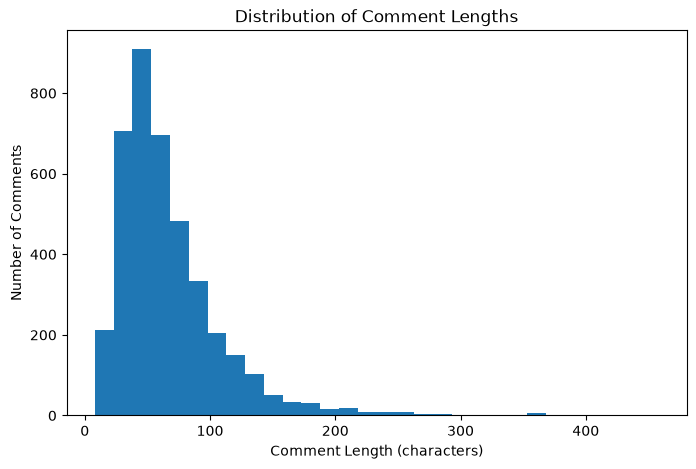

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_df["text_length"], bins=30)
plt.xlabel("Comment Length (characters)")
plt.ylabel("Number of Comments")
plt.title("Distribution of Comment Lengths")
plt.show()

In [38]:
# Inspect dataset structure and quality

print("===== TRAINING DATA =====")
print("Shape:", train_df.shape)
print("\nColumns:")
print(train_df.columns.tolist())

print("\nFirst 5 training samples:")
display(train_df.head())

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nDuplicate rows:")
print(train_df.duplicated().sum())


print("\n\n===== TEST DATA =====")
print("Shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

print("\nFirst 10 test samples:")
display(test_df.head(10))

print("\nMissing values:")
print(test_df.isnull().sum())

print("\nDuplicate rows:")
print(test_df.duplicated().sum())

===== TRAINING DATA =====
Shape: (4000, 4)

Columns:
['S.No', 'Comments', 'Label', 'text_length']

First 5 training samples:


,S.No,Comments,Label,text_length
0,HATE_1001,Thappu chesina vaallaku vanike kaadu inka anni...,hate,135
1,HATE_1002,Dhusta chaathuryam! Meeru ilantivi enni chesi...,hate,62
2,HATE_1003,Vetakaram super. Govt ki siggu seram radu. End...,hate,109
3,HATE_1004,Only rajakiyam ga vadukovatanike ee dharidrapu...,hate,54
4,HATE_1005,Katam hogaya narayana pedda bokada college,hate,42



Missing values:
S.No           0
Comments       0
Label          0
text_length    0
dtype: int64

Duplicate rows:
0


===== TEST DATA =====
Shape: (499, 2)

Columns:
[1, 'ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,']

First 10 test samples:


,1,"ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,"
0,2,ఫ్యూచర్ లో బాగ work out అవుతుంది సూపర్.
1,3,ఇది బెండపూడి గవ్నమెంట్ స్టూడెంట్స్ కి మాత్రమే ...
2,4,తెలుగులో మాట్లాడినప్పుడు చాలా అందంగా వినసొంపుగ...
3,5,సూపర్ సిస్టర్ ఫ్యూచర్ లో రైల్వే లో జాబ్ రావాలన...
4,6,వావ్ సూపర్ అమ్మ god bless u తల్లి
5,7,ఈ స్కూల్ ని NRI వాళ్ళు Develop చేస్తున్నారు. మ...
6,8,సూపర్ బంగారం బాగా చదువుతున్నావ్ కంపల్సరీ ఈ జాబ...
7,9,చాలా బాగా నేర్పిస్తున్నారు పిల్లలకి
8,10,మ్మెల్యే కాకముందే పోలీస్ ఆఫీసర్ ఇలా నించో పెడు...
9,11,అబ్బా అబ్బా ఏమి మాట్లాడారు సర్ కేక పుట్టించే స...



Missing values:
1                                                         0
ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,    0
dtype: int64

Duplicate rows:
0


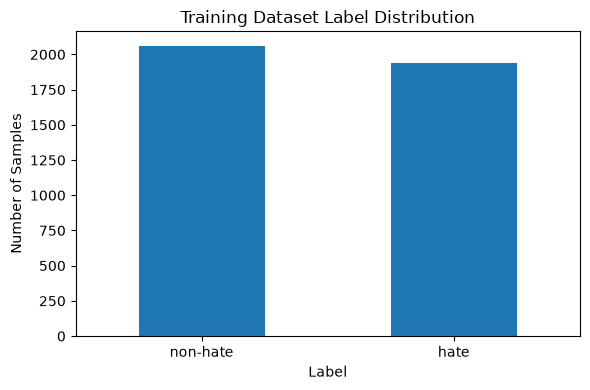

In [39]:
import matplotlib.pyplot as plt

train_df["Label"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Training Dataset Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
S.No           0
Comments       0
Label          0
text_length    0
dtype: int64

Missing values in test data:
1                                                         0
ఎన్ని సార్లు అయిన వినాలని ఉంది చిట్టి తల్లి సూపర్ మా,,    0
dtype: int64


In [41]:
# Check duplicate comments
print("Duplicate comments in training data:")
print(train_df["Comments"].duplicated().sum())

print("\nDuplicate comments in test data:")
print(test_df[1].duplicated().sum())

# Check empty comments
print("\nEmpty comments in training data:")
print(train_df["Comments"].isna().sum())

print("\nEmpty comments in test data:")
print(test_df[1].isna().sum())

Duplicate comments in training data:
51

Duplicate comments in test data:
0

Empty comments in training data:
0

Empty comments in test data:
0


In [42]:
# Calculate comment length in characters
train_df["text_length"] = train_df["Comments"].astype(str).str.len()

test_df["text_length"] = test_df[1].astype(str).str.len()

print("TRAINING TEXT LENGTH")
print(train_df["text_length"].describe())

print("\nTEST TEXT LENGTH")
print(test_df["text_length"].describe())

TRAINING TEXT LENGTH
count    4000.000000
mean       66.849500
std        44.294767
min         8.000000
25%        39.000000
50%        56.000000
75%        82.000000
max       458.000000
Name: text_length, dtype: float64

TEST TEXT LENGTH
count    499.000000
mean       2.787575
std        0.446951
min        1.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: text_length, dtype: float64


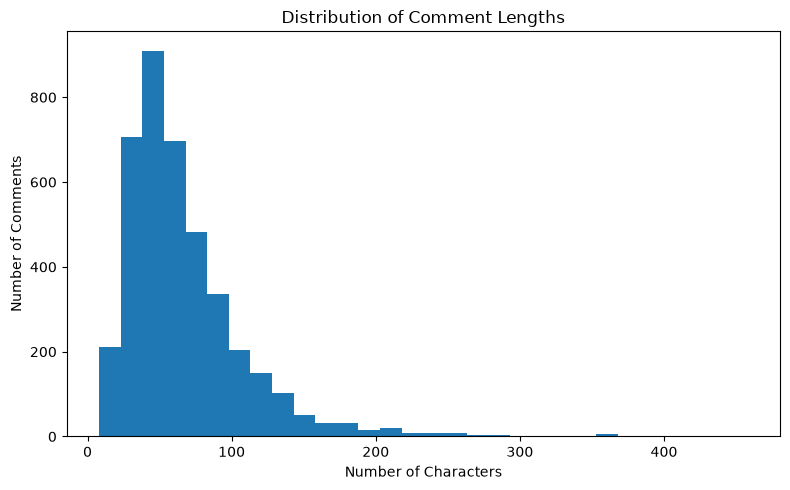

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    train_df["text_length"],
    bins=30
)

plt.title("Distribution of Comment Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

In [44]:
# Show sample non-hate comments
print("========== NON-HATE EXAMPLES ==========")

display(
    train_df[train_df["Label"] == "non-hate"][["Comments", "Label"]]
    .head(10)
)

# Show sample hate comments
print("\n========== HATE EXAMPLES ==========")

display(
    train_df[train_df["Label"] == "hate"][["Comments", "Label"]]
    .head(10)
)

========== NON-HATE EXAMPLES ==========


,Comments,Label
5,TELUGU DESAM PARTY ONLY GOOD ADMINISTRATION IN...,non-hate
6,Nenu aite Jabardast show chudadam manesanu TV ...,non-hate
8,Students tho adukovtam thappu,non-hate
10,Meru mi media published cheyadam vallane elant...,non-hate
11,"One of the Great Leader, A Big Salute Sir.,,",non-hate
14,"Rosayya garu is a real, Good and true politici...",non-hate
18,Down To Earth Man Rosaiah Garu,non-hate
19,Jagan is unstoppable,non-hate
23,Revanth Reddy garu has very clarity in his tho...,non-hate
24,Mahesh smile ...pure soul,non-hate



========== HATE EXAMPLES ==========


,Comments,Label
0,Thappu chesina vaallaku vanike kaadu inka anni...,hate
1,Dhusta chaathuryam! Meeru ilantivi enni chesi...,hate
2,Vetakaram super. Govt ki siggu seram radu. End...,hate
3,Only rajakiyam ga vadukovatanike ee dharidrapu...,hate
4,Katam hogaya narayana pedda bokada college,hate
7,Jagan meeda jaganke visvasam ledu anduke ea lo...,hate
9,Srinivasa gaaru endukee panikamaalina debate.....,hate
12,Mogavalla face luu mathram manchiga chupisthar...,hate
13,Paniki malina chana,hate
15,Telangana gujju gulam kadu,hate


In [45]:
print("Sample comments from the training dataset:\n")

for i, text in enumerate(train_df["Comments"].head(10), 1):
    print(f"{i}. {text}")

Sample comments from the training dataset:

1. Thappu chesina vaallaku vanike kaadu inka anni modalithavi  . Enta kaalam students life tho aadukuntu crores earn chedtharu illegal ga.
2. Dhusta chaathuryam!  Meeru ilantivi enni chesina em pikalerra!
3. Vetakaram super. Govt ki siggu seram radu. Endukante siggu seram manushulaku mathrme vuntundani na abiprayam.
4. Only rajakiyam ga vadukovatanike ee dharidrapu arestlu
5. Katam hogaya narayana pedda bokada college
6. TELUGU DESAM PARTY ONLY GOOD ADMINISTRATION IN THE WORLD
7. Nenu aite Jabardast show chudadam manesanu TV 5 ABN channels lo debates vchinaka 
8. Jagan meeda jaganke visvasam ledu anduke ea loffer panulu
9. Students tho adukovtam thappu
10. Srinivasa gaaru endukee panikamaalina debate... Aa sambaki paniledu... Meeku jeetam kavaali ..makenti gola... Anni exams happy ga jariginai... problem meeu creat cheyyavaddu


In [46]:
# Find duplicate comments and inspect their labels

duplicates = train_df[
    train_df["Comments"].duplicated(keep=False)
].sort_values("Comments")

print("Number of rows involved in duplicate comments:", len(duplicates))
print("Number of unique duplicated comments:", duplicates["Comments"].nunique())

display(
    duplicates[["Comments", "Label"]].head(30)
)

Number of rows involved in duplicate comments: 100
Number of unique duplicated comments: 49


,Comments,Label
1080,2024 election lo odipothe orey kodali kodini k...,hate
1081,2024 election lo odipothe orey kodali kodini k...,hate
3596,Aaku puuku theliyandhi kuda judge aipoindhi,hate
3599,Aaku puuku theliyandhi kuda judge aipoindhi,hate
1949,Acting super undhi ga bro just story lo dammu ...,non-hate
2081,Acting super undhi ga bro just story lo dammu ...,non-hate
2108,Anchor be like: pichi na kdklni andharu ikkade...,hate
2107,Anchor be like: pichi na kdklni andharu ikkade...,hate
3855,Arey ni bondha ra chetha na kodaka,hate
3623,Arey ni bondha ra chetha na kodaka,hate


In [47]:
duplicate_label_check = (
    train_df.groupby("Comments")["Label"]
    .nunique()
)

print("Duplicate comments with conflicting labels:")
print((duplicate_label_check > 1).sum())

print("\nDuplicate comments with same label:")
print((duplicate_label_check == 1).sum())

Duplicate comments with conflicting labels:
10

Duplicate comments with same label:
3939


In [48]:
# Create a standardized training dataframe

clean_train = train_df[["Comments", "Label"]].copy()

clean_train = clean_train.rename(columns={
    "Comments": "text",
    "Label": "label"
})

# Remove accidental leading/trailing spaces
clean_train["text"] = clean_train["text"].astype(str).str.strip()
clean_train["label"] = clean_train["label"].astype(str).str.strip().str.lower()

print("Clean training dataset:")
print(clean_train.head())

print("\nShape:", clean_train.shape)
print("\nColumns:", clean_train.columns.tolist())
print("\nLabels:")
print(clean_train["label"].value_counts())

Clean training dataset:
                                                text label
0  Thappu chesina vaallaku vanike kaadu inka anni...  hate
1  Dhusta chaathuryam!  Meeru ilantivi enni chesi...  hate
2  Vetakaram super. Govt ki siggu seram radu. End...  hate
3  Only rajakiyam ga vadukovatanike ee dharidrapu...  hate
4         Katam hogaya narayana pedda bokada college  hate

Shape: (4000, 2)

Columns: ['text', 'label']

Labels:
label
non-hate    2061
hate        1939
Name: count, dtype: int64


In [49]:
print("Missing values:")
print(clean_train.isnull().sum())

print("\nEmpty texts:")
print((clean_train["text"] == "").sum())

print("\nDuplicate texts:")
print(clean_train["text"].duplicated().sum())

print("\nUnique labels:")
print(clean_train["label"].unique())

Missing values:
text     0
label    0
dtype: int64

Empty texts:
0

Duplicate texts:
55

Unique labels:
<StringArray>
['hate', 'non-hate']
Length: 2, dtype: str


In [50]:
# Save cleaned training data
output_path = "../data/processed/train_clean.csv"

clean_train.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", output_path)

Saved: ../data/processed/train_clean.csv


In [51]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import sys
print(sys.executable)

import sklearn
print("Scikit-learn:", sklearn.__version__)

c:\Users\Divya\AppData\Local\Programs\Python\Python311\python.exe
Scikit-learn: 1.9.1


In [53]:
clean_train

,text,label
0,Thappu chesina vaallaku vanike kaadu inka anni...,hate
1,Dhusta chaathuryam! Meeru ilantivi enni chesi...,hate
2,Vetakaram super. Govt ki siggu seram radu. End...,hate
3,Only rajakiyam ga vadukovatanike ee dharidrapu...,hate
4,Katam hogaya narayana pedda bokada college,hate
...,...,...
3995,నిజాయితీపరుడంట....same బాస్ క్వాలిటీస్ చాలా ఉన...,hate
3996,ఓహో ఈ నిజాయితీపరుడైన రవి ప్రకాష్ లో పవన్ లక్షణ...,hate
3997,వీడీ పేరు రాంగోపాల్ వర్మ! వీడి చేతిలో పడ్డ అమ్...,hate
3998,నువ్వు మాత్రం డబ్బులేస్తే ముష్టి వాడి పక్కన అయ...,hate


In [54]:
from sklearn.model_selection import train_test_split

X = clean_train["text"]
y = clean_train["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nValidation label distribution:")
print(y_val.value_counts())

Training samples: 3200
Validation samples: 800

Training label distribution:
label
non-hate    1649
hate        1551
Name: count, dtype: int64

Validation label distribution:
label
non-hate    412
hate        388
Name: count, dtype: int64


In [55]:
# Text length analysis

train_lengths = clean_train["text"].str.len()
test_lengths = test_df[1].astype(str).str.len()

print("TRAINING TEXT LENGTH")
print("Minimum:", train_lengths.min())
print("Maximum:", train_lengths.max())
print("Average:", train_lengths.mean())
print("Median:", train_lengths.median())

print("\nTEST TEXT LENGTH")
print("Minimum:", test_lengths.min())
print("Maximum:", test_lengths.max())
print("Average:", test_lengths.mean())
print("Median:", test_lengths.median())

TRAINING TEXT LENGTH
Minimum: 8
Maximum: 458
Average: 66.7345
Median: 56.0

TEST TEXT LENGTH
Minimum: 1
Maximum: 3
Average: 2.787575150300601
Median: 3.0


In [56]:
# View sample comments from each class

print("===== NON-HATE EXAMPLES =====")
print(clean_train[clean_train["label"] == "non-hate"]["text"].head(5).to_string(index=False))

print("\n===== HATE EXAMPLES =====")
print(clean_train[clean_train["label"] == "hate"]["text"].head(5).to_string(index=False))

===== NON-HATE EXAMPLES =====
TELUGU DESAM PARTY ONLY GOOD ADMINISTRATION IN ...
Nenu aite Jabardast show chudadam manesanu TV 5...
                     Students tho adukovtam thappu
Meru mi media published cheyadam vallane elanti...
      One of the Great Leader, A Big Salute Sir.,,

===== HATE EXAMPLES =====
Thappu chesina vaallaku vanike kaadu inka anni ...
Dhusta chaathuryam!  Meeru ilantivi enni chesin...
Vetakaram super. Govt ki siggu seram radu. Endu...
Only rajakiyam ga vadukovatanike ee dharidrapu ...
        Katam hogaya narayana pedda bokada college


In [57]:
# STEP 15: TF-IDF + Logistic Regression Baseline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Convert text into TF-IDF features
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = lr_model.predict(X_val_tfidf)

# Evaluation
print("\n===== TF-IDF + LOGISTIC REGRESSION =====")

print("\nAccuracy:")
print(accuracy_score(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Training TF-IDF shape: (3200, 3793)
Validation TF-IDF shape: (800, 3793)

===== TF-IDF + LOGISTIC REGRESSION =====

Accuracy:
0.73125

Classification Report:
              precision    recall  f1-score   support

        hate       0.71      0.76      0.73       388
    non-hate       0.75      0.71      0.73       412

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800


Confusion Matrix:
[[293  95]
 [120 292]]


In [58]:
# STEP 16: Record and save baseline results

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
import pandas as pd
import os

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
balanced_acc = balanced_accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average="macro")
macro_precision = precision_score(y_val, y_pred, average="macro")
macro_recall = recall_score(y_val, y_pred, average="macro")

print("===== BASELINE RESULTS =====")
print("Model: TF-IDF + Logistic Regression")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Balanced Accuracy:  {balanced_acc:.4f}")
print(f"Macro F1:           {macro_f1:.4f}")
print(f"Macro Precision:    {macro_precision:.4f}")
print(f"Macro Recall:       {macro_recall:.4f}")

# Save results
results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy],
    "Balanced_Accuracy": [balanced_acc],
    "Macro_F1": [macro_f1],
    "Macro_Precision": [macro_precision],
    "Macro_Recall": [macro_recall]
})

os.makedirs("../results/tables", exist_ok=True)

results.to_csv(
    "../results/tables/baseline_results.csv",
    index=False
)

print("\nBaseline results saved to:")
print("../results/tables/baseline_results.csv")

===== BASELINE RESULTS =====
Model: TF-IDF + Logistic Regression
Accuracy:           0.7312
Balanced Accuracy:  0.7319
Macro F1:           0.7312
Macro Precision:    0.7320
Macro Recall:       0.7319

Baseline results saved to:
../results/tables/baseline_results.csv


In [59]:
# Save validation predictions

predictions = pd.DataFrame({
    "text": X_val,
    "true_label": y_val,
    "predicted_label": y_pred
})

predictions.to_csv(
    "../results/predictions/baseline_predictions.csv",
    index=False
)

print("Predictions saved successfully.")

Predictions saved successfully.


In [60]:
# STEP 17: Script composition analysis

def script_counts(text):
    telugu = 0
    latin = 0
    other = 0

    for ch in str(text):
        if '\u0C00' <= ch <= '\u0C7F':
            telugu += 1
        elif ('A' <= ch <= 'Z') or ('a' <= ch <= 'z'):
            latin += 1
        elif not ch.isspace() and not ch.isdigit() and not ch in ".,!?;:'\"-()[]{}":
            other += 1

    return pd.Series({
        "Telugu_chars": telugu,
        "Latin_chars": latin,
        "Other_chars": other
    })


script_stats = clean_train["text"].apply(script_counts)

print("===== SCRIPT COMPOSITION =====")
print(script_stats.describe())

print("\nTotal Telugu characters:", script_stats["Telugu_chars"].sum())
print("Total Latin characters:", script_stats["Latin_chars"].sum())
print("Total Other characters:", script_stats["Other_chars"].sum())

===== SCRIPT COMPOSITION =====
       Telugu_chars  Latin_chars  Other_chars
count   4000.000000  4000.000000  4000.000000
mean      24.760750    31.106500     0.098250
std       36.545354    37.126867     1.258568
min        0.000000     0.000000     0.000000
25%        0.000000     0.000000     0.000000
50%        0.000000    24.000000     0.000000
75%       44.000000    48.000000     0.000000
max      362.000000   387.000000    61.000000

Total Telugu characters: 99043
Total Latin characters: 124426
Total Other characters: 393


In [61]:
# Count comments containing Telugu script

contains_telugu = clean_train["text"].apply(
    lambda x: any('\u0C00' <= ch <= '\u0C7F' for ch in str(x))
)

contains_latin = clean_train["text"].apply(
    lambda x: any(('A' <= ch <= 'Z') or ('a' <= ch <= 'z') for ch in str(x))
)

print("Comments containing Telugu script:", contains_telugu.sum())
print("Comments containing Latin script:", contains_latin.sum())

print("\nComments containing BOTH Telugu + Latin:")
print((contains_telugu & contains_latin).sum())

print("\nComments containing ONLY Latin:")
print((~contains_telugu & contains_latin).sum())

print("\nComments containing ONLY Telugu:")
print((contains_telugu & ~contains_latin).sum())

Comments containing Telugu script: 1790
Comments containing Latin script: 2609

Comments containing BOTH Telugu + Latin:
402

Comments containing ONLY Latin:
2207

Comments containing ONLY Telugu:
1388


In [62]:
def classify_script(text):
    text = str(text)

    has_telugu = any('\u0C00' <= ch <= '\u0C7F' for ch in text)
    has_latin = any(('A' <= ch <= 'Z') or ('a' <= ch <= 'z') for ch in text)

    if has_telugu and has_latin:
        return "Mixed"
    elif has_telugu:
        return "Telugu"
    elif has_latin:
        return "Latin/Romanized"
    else:
        return "Other"


clean_train["script_type"] = clean_train["text"].apply(classify_script)

print(clean_train["script_type"].value_counts())

print("\nPercentages:")
print(
    (clean_train["script_type"].value_counts(normalize=True) * 100).round(2)
)

script_type
Latin/Romanized    2207
Telugu             1388
Mixed               402
Other                 3
Name: count, dtype: int64

Percentages:
script_type
Latin/Romanized    55.18
Telugu             34.70
Mixed              10.05
Other               0.08
Name: proportion, dtype: float64


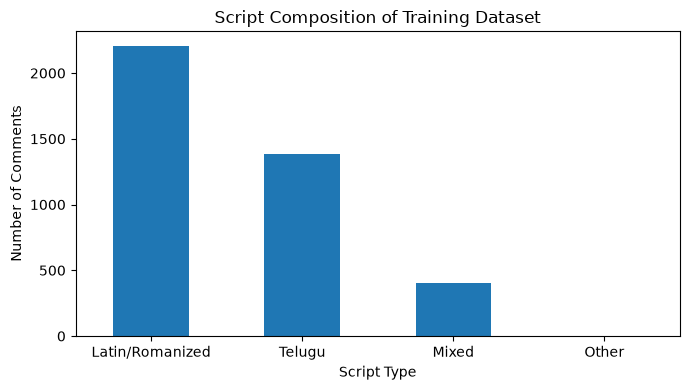

In [63]:
clean_train["script_type"].value_counts().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Script Composition of Training Dataset")
plt.xlabel("Script Type")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
script_label_table = pd.crosstab(
    clean_train["script_type"],
    clean_train["label"],
    normalize="index"
) * 100

print(script_label_table.round(2))

label             hate  non-hate
script_type                     
Latin/Romanized  59.58     40.42
Mixed            34.83     65.17
Other            33.33     66.67
Telugu           34.80     65.20


In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# 1. Convert text into TF-IDF features
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

# 2. Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

# 3. Predict validation set
y_pred = lr_model.predict(X_val_tfidf)

# 4. Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
balanced_acc = balanced_accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average="macro")
macro_precision = precision_score(y_val, y_pred, average="macro")
macro_recall = recall_score(y_val, y_pred, average="macro")

print("\n===== TF-IDF + Logistic Regression =====")
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_acc, 4))
print("Macro F1:", round(macro_f1, 4))
print("Macro Precision:", round(macro_precision, 4))
print("Macro Recall:", round(macro_recall, 4))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Training TF-IDF shape: (3200, 3793)
Validation TF-IDF shape: (800, 3793)

===== TF-IDF + Logistic Regression =====
Accuracy: 0.7312
Balanced Accuracy: 0.7319
Macro F1: 0.7312
Macro Precision: 0.732
Macro Recall: 0.7319

Classification Report:
              precision    recall  f1-score   support

        hate       0.71      0.76      0.73       388
    non-hate       0.75      0.71      0.73       412

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800


Confusion Matrix:
[[293  95]
 [120 292]]


In [66]:
import os
import pandas as pd

# Create result folders
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/predictions", exist_ok=True)

# Store baseline metrics
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy],
    "Balanced_Accuracy": [balanced_acc],
    "Macro_F1": [macro_f1],
    "Macro_Precision": [macro_precision],
    "Macro_Recall": [macro_recall]
})

# Save metrics
baseline_results.to_csv(
    "../results/tables/baseline_results.csv",
    index=False
)

# Save validation predictions
baseline_predictions = pd.DataFrame({
    "text": X_val,
    "true_label": y_val,
    "predicted_label": y_pred
})

baseline_predictions.to_csv(
    "../results/predictions/baseline_predictions.csv",
    index=False
)

print("✅ Baseline results saved!")
print("\nMetrics:")
display(baseline_results)

print("\nPrediction file saved with rows:", len(baseline_predictions))

✅ Baseline results saved!

Metrics:


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,TF-IDF + Logistic Regression,0.73125,0.731946,0.73125,0.731983,0.731946



Prediction file saved with rows: 800


In [67]:
import os

print("Baseline results:")
print(os.path.exists("../results/tables/baseline_results.csv"))

print("Baseline predictions:")
print(os.path.exists("../results/predictions/baseline_predictions.csv"))

Baseline results:
True
Baseline predictions:
True


In [68]:
# Show incorrect predictions

errors = baseline_predictions[
    baseline_predictions["true_label"] != baseline_predictions["predicted_label"]
].copy()

print("Total validation samples:", len(baseline_predictions))
print("Incorrect predictions:", len(errors))
print(
    "Error rate:",
    round(len(errors) / len(baseline_predictions) * 100, 2),
    "%"
)

display(errors.head(20))

Total validation samples: 800
Incorrect predictions: 215
Error rate: 26.88 %


,text,true_label,predicted_label
2198,Nijanga ilanti extraordinary persons untaru,non-hate,hate
1119,AP ki manchi rojulu vasthundhi,non-hate,hate
112,Ayithe life politician kavali ra Babu.,non-hate,hate
1516,"Amit Shaw ki slippers vesthu bathukuthunnadu, ...",hate,non-hate
2397,"Police vallu cheppindi antha nijamena, poorthi...",non-hate,hate
3305,తెలివిగలవాళ్లని అనుకుంటాంగానీ కాదు అదృష్టం ఏమూ...,hate,non-hate
1927,కడిగేయండి మీరు సమాజాన్ని! నాకు బాధగానే ఉంది గ...,non-hate,hate
160,వచ్చిందయ్యా మహా పతివ్రత.... అనసూయ అంటేనే నిలువ...,hate,non-hate
1809,ఏముంది పదవికోసం గుధ్ధ కూడా నాకేస్తారు ఈ రాజకీయ...,non-hate,hate
68,amarica andatho madam perigi kotukuntundi urikine,hate,non-hate


In [69]:
error_types = pd.crosstab(
    errors["true_label"],
    errors["predicted_label"]
)

print("Error distribution:")
display(error_types)

Error distribution:


predicted_label,hate,non-hate
true_label,,
hate,0,95
non-hate,120,0


In [70]:
# Add script type to the error samples

errors["script_type"] = errors["text"].apply(classify_script)

print("Errors by script type:")
display(errors["script_type"].value_counts())

print("\nError percentage by script type:")
display(
    (errors["script_type"].value_counts(normalize=True) * 100).round(2)
)

Errors by script type:


script_type
Latin/Romanized    112
Telugu              81
Mixed               22
Name: count, dtype: int64


Error percentage by script type:


script_type
Latin/Romanized    52.09
Telugu             37.67
Mixed              10.23
Name: proportion, dtype: float64

In [71]:
false_safe = errors[
    (errors["true_label"] == "hate") &
    (errors["predicted_label"] == "non-hate")
]

print("False-safe errors:", len(false_safe))

display(false_safe.head(20))

False-safe errors: 95


,text,true_label,predicted_label,script_type
1516,"Amit Shaw ki slippers vesthu bathukuthunnadu, ...",hate,non-hate,Latin/Romanized
3305,తెలివిగలవాళ్లని అనుకుంటాంగానీ కాదు అదృష్టం ఏమూ...,hate,non-hate,Telugu
160,వచ్చిందయ్యా మహా పతివ్రత.... అనసూయ అంటేనే నిలువ...,hate,non-hate,Telugu
68,amarica andatho madam perigi kotukuntundi urikine,hate,non-hate,Latin/Romanized
3376,Krittika Garu Vadine Chepu tho Kothandi Live L...,hate,non-hate,Latin/Romanized
1025,Suma garu koncham thagichuko,hate,non-hate,Latin/Romanized
1674,ప్రపంచంలో అతిపెద్ద అవినీతి పార్టీ టిఅర్ యస్ కె...,hate,non-hate,Telugu
1608,Chala ibandi pettavu anna Nuvvu maa Chiru garini,hate,non-hate,Latin/Romanized
52,Ayanni okasari kodithey meeru laksha sarlu chu...,hate,non-hate,Latin/Romanized
2991,మంగ్లీ పాడిన పాటలు అన్నీ ఒకేలాగనే అనిపిస్తున్న...,hate,non-hate,Telugu


In [72]:
# Baseline risk/error summary

total = len(baseline_predictions)

false_safe = len(
    baseline_predictions[
        (baseline_predictions["true_label"] == "hate") &
        (baseline_predictions["predicted_label"] == "non-hate")
    ]
)

false_alarm = len(
    baseline_predictions[
        (baseline_predictions["true_label"] == "non-hate") &
        (baseline_predictions["predicted_label"] == "hate")
    ]
)

correct_hate = len(
    baseline_predictions[
        (baseline_predictions["true_label"] == "hate") &
        (baseline_predictions["predicted_label"] == "hate")
    ]
)

correct_non_hate = len(
    baseline_predictions[
        (baseline_predictions["true_label"] == "non-hate") &
        (baseline_predictions["predicted_label"] == "non-hate")
    ]
)

risk_table = pd.DataFrame({
    "Measure": [
        "Total validation samples",
        "Correct hate predictions",
        "Correct non-hate predictions",
        "False-safe predictions",
        "False-alarm predictions",
        "False-safe rate",
        "Overall error rate"
    ],
    "Value": [
        total,
        correct_hate,
        correct_non_hate,
        false_safe,
        false_alarm,
        round(false_safe / total * 100, 2),
        round((false_safe + false_alarm) / total * 100, 2)
    ]
})

display(risk_table)

,Measure,Value
0,Total validation samples,800.00
1,Correct hate predictions,293.00
2,Correct non-hate predictions,292.00
3,False-safe predictions,95.00
4,False-alarm predictions,120.00
5,False-safe rate,11.88
6,Overall error rate,26.88


In [73]:
# Get prediction probabilities

y_proba = lr_model.predict_proba(X_val_tfidf)

# Maximum probability = model confidence
confidence = y_proba.max(axis=1)

confidence_df = pd.DataFrame({
    "text": X_val,
    "true_label": y_val,
    "predicted_label": y_pred,
    "confidence": confidence
})

display(confidence_df.head(10))

,text,true_label,predicted_label,confidence
3303,స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయన...,non-hate,non-hate,0.726657
3704,Gudha paguldegale,hate,hate,0.685973
2198,Nijanga ilanti extraordinary persons untaru,non-hate,hate,0.610928
3173,నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుం...,non-hate,non-hate,0.762377
1119,AP ki manchi rojulu vasthundhi,non-hate,hate,0.529840
112,Ayithe life politician kavali ra Babu.,non-hate,hate,0.714289
2574,KTR:Nannu erri puk cheshavu gah kadhara revanth,hate,hate,0.716915
110,Youtube vedios konni follow ayyedhanni tharwat...,non-hate,non-hate,0.771891
3635,Recharge aipothey data ela vastadhi ra erri puka,hate,hate,0.872702
3284,vadu donga nuuv yadava,hate,hate,0.784930


In [74]:
import sys
import matplotlib

print("Python:", sys.executable)
print("Matplotlib:", matplotlib.__version__)

Python: c:\Users\Divya\AppData\Local\Programs\Python\Python311\python.exe
Matplotlib: 3.11.2


In [75]:
# Baseline risk/error summary

total = len(baseline_predictions)

false_safe = len(
    baseline_predictions[
        (baseline_predictions["true_label"] == "hate") &
        (baseline_predictions["predicted_label"] == "non-hate")
    ]
)

false_alarm = len(
    baseline_predictions[
        (baseline_predictions["true_label"] == "non-hate") &
        (baseline_predictions["predicted_label"] == "hate")
    ]
)

correct_hate = len(
    baseline_predictions[
        (baseline_predictions["true_label"] == "hate") &
        (baseline_predictions["predicted_label"] == "hate")
    ]
)

correct_non_hate = len(
    baseline_predictions[
        (baseline_predictions["true_label"] == "non-hate") &
        (baseline_predictions["predicted_label"] == "non-hate")
    ]
)

risk_table = pd.DataFrame({
    "Measure": [
        "Total validation samples",
        "Correct hate predictions",
        "Correct non-hate predictions",
        "False-safe predictions",
        "False-alarm predictions",
        "False-safe rate",
        "Overall error rate"
    ],
    "Value": [
        total,
        correct_hate,
        correct_non_hate,
        false_safe,
        false_alarm,
        round(false_safe / total * 100, 2),
        round((false_safe + false_alarm) / total * 100, 2)
    ]
})

display(risk_table)

,Measure,Value
0,Total validation samples,800.00
1,Correct hate predictions,293.00
2,Correct non-hate predictions,292.00
3,False-safe predictions,95.00
4,False-alarm predictions,120.00
5,False-safe rate,11.88
6,Overall error rate,26.88


In [76]:
risk_table.to_csv(
    "../results/tables/baseline_risk_analysis.csv",
    index=False
)

print("✅ Baseline risk analysis saved.")

✅ Baseline risk analysis saved.


In [77]:
# Get prediction probabilities

y_proba = lr_model.predict_proba(X_val_tfidf)

# Maximum probability = model confidence
confidence = y_proba.max(axis=1)

confidence_df = pd.DataFrame({
    "text": X_val,
    "true_label": y_val,
    "predicted_label": y_pred,
    "confidence": confidence
})

display(confidence_df.head(10))

,text,true_label,predicted_label,confidence
3303,స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయన...,non-hate,non-hate,0.726657
3704,Gudha paguldegale,hate,hate,0.685973
2198,Nijanga ilanti extraordinary persons untaru,non-hate,hate,0.610928
3173,నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుం...,non-hate,non-hate,0.762377
1119,AP ki manchi rojulu vasthundhi,non-hate,hate,0.529840
112,Ayithe life politician kavali ra Babu.,non-hate,hate,0.714289
2574,KTR:Nannu erri puk cheshavu gah kadhara revanth,hate,hate,0.716915
110,Youtube vedios konni follow ayyedhanni tharwat...,non-hate,non-hate,0.771891
3635,Recharge aipothey data ela vastadhi ra erri puka,hate,hate,0.872702
3284,vadu donga nuuv yadava,hate,hate,0.784930


In [78]:
print("Average confidence:",
      round(confidence.mean(), 4))

print("Minimum confidence:",
      round(confidence.min(), 4))

print("Maximum confidence:",
      round(confidence.max(), 4))

Average confidence: 0.6688
Minimum confidence: 0.5003
Maximum confidence: 0.9394


In [79]:
confidence_df["correct"] = (
    confidence_df["true_label"] ==
    confidence_df["predicted_label"]
)

print("Average confidence — Correct predictions:",
      round(
          confidence_df.loc[
              confidence_df["correct"], "confidence"
          ].mean(), 4
      )
)

print("Average confidence — Incorrect predictions:",
      round(
          confidence_df.loc[
              ~confidence_df["correct"], "confidence"
          ].mean(), 4
      )
)

Average confidence — Correct predictions: 0.6897
Average confidence — Incorrect predictions: 0.6119


In [80]:
# Create a separate dataframe for SCRIPT-SHIFT experiments

script_shift_df = pd.DataFrame({
    "original_text": X_val.reset_index(drop=True),
    "label": y_val.reset_index(drop=True)
})

print("SCRIPT-SHIFT dataset created.")
print("Rows:", len(script_shift_df))

display(script_shift_df.head(10))

SCRIPT-SHIFT dataset created.
Rows: 800


,original_text,label
0,స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయన...,non-hate
1,Gudha paguldegale,hate
2,Nijanga ilanti extraordinary persons untaru,non-hate
3,నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుం...,non-hate
4,AP ki manchi rojulu vasthundhi,non-hate
5,Ayithe life politician kavali ra Babu.,non-hate
6,KTR:Nannu erri puk cheshavu gah kadhara revanth,hate
7,Youtube vedios konni follow ayyedhanni tharwat...,non-hate
8,Recharge aipothey data ela vastadhi ra erri puka,hate
9,vadu donga nuuv yadava,hate


In [81]:
script_shift_df["original_script"] = (
    script_shift_df["original_text"].apply(classify_script)
)

print("Original script distribution:")
display(script_shift_df["original_script"].value_counts())

Original script distribution:


original_script
Latin/Romanized    452
Telugu             263
Mixed               84
Other                1
Name: count, dtype: int64

In [82]:
# Show real examples from each script category

for script in ["Latin/Romanized", "Telugu", "Mixed", "Other"]:
    print("\n" + "=" * 70)
    print(f"{script} EXAMPLES")
    print("=" * 70)

    examples = script_shift_df[
        script_shift_df["original_script"] == script
    ][["original_text", "label"]].head(10)

    display(examples)


Latin/Romanized EXAMPLES


,original_text,label
1,Gudha paguldegale,hate
2,Nijanga ilanti extraordinary persons untaru,non-hate
4,AP ki manchi rojulu vasthundhi,non-hate
5,Ayithe life politician kavali ra Babu.,non-hate
6,KTR:Nannu erri puk cheshavu gah kadhara revanth,hate
7,Youtube vedios konni follow ayyedhanni tharwat...,non-hate
8,Recharge aipothey data ela vastadhi ra erri puka,hate
9,vadu donga nuuv yadava,hate
12,Waste gadu Natraj is very bad behaviour,hate
13,Kanisam okka wicket kooda teeyaledu waste galu,hate



Telugu EXAMPLES


,original_text,label
0,స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయన...,non-hate
3,నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుం...,non-hate
10,సంస్కారవంతమైన కుటుంబం,non-hate
11,ప్రజా సమస్యల పరిష్కారంపై దృష్టి పెట్టండి,non-hate
19,మళ్ళీ మళ్ళీ రిపీట్ చేస్తూ చూస్తున్న వాళ్లు ఎంత...,non-hate
22,తెలివిగలవాళ్లని అనుకుంటాంగానీ కాదు అదృష్టం ఏమూ...,hate
23,కడిగేయండి మీరు సమాజాన్ని! నాకు బాధగానే ఉంది గ...,non-hate
26,శుక్రవారం శుక్రవారం స్టేషన్ కి వచ్చి సంతకం\nపె...,non-hate
27,ఎందరో మహాను బావులు వుంటారు వాళ్లు ఊరికెనే ఉండరు,non-hate
29,నీతి నిజాయితీ లకు మారు పేరుగా నిలిచిన వ్యక్తి ...,non-hate



Mixed EXAMPLES


,original_text,label
17,ప్రతి సీన్... ప్రతీ షాట్....మతి పోతుంది లోపల a...,non-hate
24,"God bless your relation madam, జై సుధీర్ అన్న",non-hate
62,Kaasta అమ్మ నన్న పైన ప్రేమ కలిగి vundandi bro,non-hate
66,This should be a good lesson for youngsters. ...,non-hate
79,ఇలాంటి సెలబ్రిటీలు ఇలా షోష్ కు రావాలి sir,non-hate
87,పోన్లే పాపం కష్టపడ్డదానికి కొంచెం అయిన ప్రతిఫల...,non-hate
91,సూపర్ rk గారు చాలా మంచి ప్రోగ్రాం,non-hate
115,మీరు చరిత్రలో నీలుస్తరు బ్రో Hand's off to You...,non-hate
125,Dr YNM\n1 month ago\nఇందులో మనం పెద్దగా ఆలోచిం...,non-hate
136,చాలా బాగా explain చేశారు బ్రదర్. Small correct...,non-hate



Other EXAMPLES


,original_text,label
785,𝙋𝙪𝙠𝙪 𝙙𝙖𝙣𝙜𝙞𝙩𝙝𝙝𝙖,hate


In [83]:
# Label distribution for each script type

script_label_counts = pd.crosstab(
    script_shift_df["original_script"],
    script_shift_df["label"]
)

print("Label counts by script:")
display(script_label_counts)

print("\nLabel percentages by script:")
display(
    pd.crosstab(
        script_shift_df["original_script"],
        script_shift_df["label"],
        normalize="index"
    ).mul(100).round(2)
)

Label counts by script:


label,hate,non-hate
original_script,,
Latin/Romanized,269,183
Mixed,23,61
Other,1,0
Telugu,95,168



Label percentages by script:


label,hate,non-hate
original_script,,
Latin/Romanized,59.51,40.49
Mixed,27.38,72.62
Other,100.00,0.00
Telugu,36.12,63.88


In [84]:
# Create the SCRIPT-SHIFT experiment table

script_shift_experiment = pd.DataFrame({
    "id": range(len(script_shift_df)),
    "original_text": script_shift_df["original_text"],
    "label": script_shift_df["label"],
    "original_script": script_shift_df["original_script"]
})

# Original condition
script_shift_experiment["original"] = (
    script_shift_experiment["original_text"]
)

# Empty columns for transformations
script_shift_experiment["romanized"] = None
script_shift_experiment["telugu_script"] = None
script_shift_experiment["mixed_script"] = None
script_shift_experiment["mild_noise"] = None
script_shift_experiment["severe_noise"] = None

print("SCRIPT-SHIFT experiment table created.")
print("Rows:", len(script_shift_experiment))
print("Columns:", list(script_shift_experiment.columns))

display(script_shift_experiment.head())

SCRIPT-SHIFT experiment table created.
Rows: 800
Columns: ['id', 'original_text', 'label', 'original_script', 'original', 'romanized', 'telugu_script', 'mixed_script', 'mild_noise', 'severe_noise']


,id,original_text,label,original_script,original,romanized,telugu_script,mixed_script,mild_noise,severe_noise
0,0,స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయన...,non-hate,Telugu,స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయన...,None,None,None,None,None
1,1,Gudha paguldegale,hate,Latin/Romanized,Gudha paguldegale,None,None,None,None,None
2,2,Nijanga ilanti extraordinary persons untaru,non-hate,Latin/Romanized,Nijanga ilanti extraordinary persons untaru,None,None,None,None,None
3,3,నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుం...,non-hate,Telugu,నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుం...,None,None,None,None,None
4,4,AP ki manchi rojulu vasthundhi,non-hate,Latin/Romanized,AP ki manchi rojulu vasthundhi,None,None,None,None,None


In [85]:
import os

os.makedirs("../data/script_shift", exist_ok=True)

script_shift_experiment.to_csv(
    "../data/script_shift/script_shift_base.csv",
    index=False
)

print("✅ Saved:")
print("../data/script_shift/script_shift_base.csv")

✅ Saved:
../data/script_shift/script_shift_base.csv


In [86]:
%pip install indic-transliteration

     ---------------------------------------- 0.0/41.6 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.6 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.6 kB 165.2 kB/s eta 0:00:01
     -------------------------------------  41.0/41.6 kB 281.8 kB/s eta 0:00:01
     -------------------------------------- 41.6/41.6 kB 154.6 kB/s eta 0:00:00
     ---------------------------------------- 0.0/57.4 kB ? eta -:--:--
     ---------------------------------------- 57.4/57.4 kB 1.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/162.9 kB ? eta -:--:--
   ------------------------------------- -- 153.6/162.9 kB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 162.9/162.9 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/278.3 kB ? eta -:--:--
   ---------------------------------------- 278.3/278.3 kB 8.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/80.2 kB ? eta -:--:--
   --------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
from indic_transliteration import sanscript

telugu_samples = script_shift_experiment[
    script_shift_experiment["original_script"] == "Telugu"
]["original_text"].head(10).tolist()

for text in telugu_samples:
    roman = sanscript.transliterate(
        text,
        sanscript.TELUGU,
        sanscript.ITRANS
    )

    print("TELUGU :", text)
    print("ROMAN  :", roman)
    print("-" * 70)

TELUGU : స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయనకి పార్టీ కి చెడ్డ పేరు వస్తుంది
ROMAN  : strIlanu vIdhiloki lagakaMdi pavan gAru chUste Ayanaki pArTI ki chèDDa peru vastuMdi
----------------------------------------------------------------------
TELUGU : నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుంచి డబ్బులు వస్తే ఏపించుకుందాం అని చూస్తున్న... మాములుగా లేదు అనుదీప్ గారి పంచెస్
ROMAN  : nAku iMTarnèT mòbail DeTA ledu aMDi iMdulonuMchi Dabbulu vaste epiMchukuMdAM ani chUstunna... mAmulugA ledu anudIp gAri paMchès
----------------------------------------------------------------------
TELUGU : సంస్కారవంతమైన కుటుంబం
ROMAN  : saMskAravaMtamaina kuTuMbaM
----------------------------------------------------------------------
TELUGU : ప్రజా సమస్యల పరిష్కారంపై దృష్టి పెట్టండి
ROMAN  : prajA samasyala pariShkAraMpai dRRiShTi pèTTaMDi
----------------------------------------------------------------------
TELUGU : మళ్ళీ మళ్ళీ రిపీట్ చేస్తూ చూస్తున్న వాళ్లు ఎంతమంది ఉన్నారు...️
ROMAN  : maLL

In [88]:
roman_samples = script_shift_experiment[
    script_shift_experiment["original_script"] == "Latin/Romanized"
]["original_text"].head(10).tolist()

for text in roman_samples:
    try:
        telugu = sanscript.transliterate(
            text,
            sanscript.ITRANS,
            sanscript.TELUGU
        )

        print("ROMAN  :", text)
        print("TELUGU :", telugu)

    except Exception as e:
        print("ROMAN  :", text)
        print("ERROR  :", e)

    print("-" * 70)

ROMAN  : Gudha paguldegale
TELUGU : Gుధ పగుల్దేగలే
----------------------------------------------------------------------
ROMAN  : Nijanga ilanti extraordinary persons untaru
TELUGU : ణిజన్గ ఇలన్తి ఏక్ష్త్రఓర్దినర్య్ పేర్సోన్స్ ఉన్తరు
----------------------------------------------------------------------
ROMAN  : AP ki manchi rojulu vasthundhi
TELUGU : ఆP కి మన్చి రోజులు వస్థున్ధి
----------------------------------------------------------------------
ROMAN  : Ayithe life politician kavali ra Babu.
TELUGU : ఆయిథే లిfే పోలితిచిఅన్ కవలి ర Bఅబు।
----------------------------------------------------------------------
ROMAN  : KTR:Nannu erri puk cheshavu gah kadhara revanth
TELUGU : K్ట్ఱ్:ణన్ను ఏర్రి పుక్ చేశవు గహ్ కధర రేవన్థ్
----------------------------------------------------------------------
ROMAN  : Youtube vedios konni follow ayyedhanni tharwatha BB house lo koncham negitive feel ayya ippudu chustunte badha anipistundhi very good dancer All the Best for your future Shanmukh 💐
TELUGU :

In [89]:
import re
from indic_transliteration import sanscript

def romanized_telugu_to_telugu(text):
    text = str(text)

    # Split text while preserving spaces and punctuation
    tokens = re.findall(r'\w+|[^\w\s]|\s+', text, flags=re.UNICODE)

    converted = []

    for token in tokens:

        # Keep spaces and punctuation unchanged
        if not token.strip() or not token.isalnum():
            converted.append(token)
            continue

        # English-looking words are kept unchanged
        if re.fullmatch(r'[A-Za-z]+', token):

            # Common English words / code-mixed English words
            english_words = {
                "extraordinary", "persons", "life", "politician",
                "videos", "follow", "house", "negative", "feel",
                "very", "good", "dancer", "best", "future",
                "waste", "behaviour", "wicket", "bad"
            }

            if token.lower() in english_words:
                converted.append(token)
            else:
                try:
                    converted.append(
                        sanscript.transliterate(
                            token,
                            sanscript.ITRANS,
                            sanscript.TELUGU
                        )
                    )
                except:
                    converted.append(token)

        else:
            converted.append(token)

    return "".join(converted)

In [90]:
test_samples = [
    "Nijanga ilanti extraordinary persons untaru",
    "Ayithe life politician kavali ra Babu.",
    "Youtube vedios konni follow ayye dhanni",
    "waste gadu Natraj is very bad behaviour"
]

for text in test_samples:
    print("ORIGINAL :", text)
    print("CONVERTED:", romanized_telugu_to_telugu(text))
    print("-" * 80)

ORIGINAL : Nijanga ilanti extraordinary persons untaru
CONVERTED: ణిజన్గ ఇలన్తి extraordinary persons ఉన్తరు
--------------------------------------------------------------------------------
ORIGINAL : Ayithe life politician kavali ra Babu.
CONVERTED: ఆయిథే life politician కవలి ర Bఅబు.
--------------------------------------------------------------------------------
ORIGINAL : Youtube vedios konni follow ayye dhanni
CONVERTED: Yోఉతుబే వేదిఓస్ కోన్ని follow అయ్యే ధన్ని
--------------------------------------------------------------------------------
ORIGINAL : waste gadu Natraj is very bad behaviour
CONVERTED: waste గదు ణత్రజ్ ఇస్ very bad behaviour
--------------------------------------------------------------------------------


In [91]:
%pip install ai4bharat-transliteration

     ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.6 MB 1.9 MB/s eta 0:00:05
      --------------------------------------- 0.1/9.6 MB 1.7 MB/s eta 0:00:06
     - -------------------------------------- 0.4/9.6 MB 3.4 MB/s eta 0:00:03
     -- ------------------------------------- 0.6/9.6 MB 4.1 MB/s eta 0:00:03
     ---- ----------------------------------- 1.0/9.6 MB 5.0 MB/s eta 0:00:02
     ----- ---------------------------------- 1.4/9.6 MB 5.5 MB/s eta 0:00:02
     ------- -------------------------------- 1.8/9.6 MB 5.9 MB/s eta 0:00:02
     -------- ------------------------------- 2.0/9.6 MB 5.8 MB/s eta 0:00:02
     --------- ------------------------------ 2.2/9.6 MB 6.0 MB/s eta 0:00:02
     --------- ------------------------------ 2.2/9.6 MB 6.0 MB/s eta 0:00:02
     --------- ------------------------------ 2.2/9.6 MB 6.0 MB/s eta 0:00:02
     ------------ --------------------------- 3.0/9.6 MB 5.6 MB/s eta 0

  error: subprocess-exited-with-error
  
  × Building wheel for fairseq (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [1503 lines of output]
      C:\Users\Divya\AppData\Local\Temp\pip-build-env-wvq5mo5e\overlay\Lib\site-packages\setuptools\_distutils\dist.py:318: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\Divya\AppData\Local\Temp\pip-build-env-wvq5mo5e\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: MIT License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              *************************************************

In [94]:
import random
import re

random.seed(42)

def add_mild_spelling_noise(text):
    """
    Controlled spelling variation.
    Only modifies alphabetic tokens.
    """
    words = str(text).split()
    new_words = []

    for word in words:
        if len(word) >= 4 and random.random() < 0.25:
            # Repeat one vowel/consonant
            chars = list(word)

            positions = [
                i for i, c in enumerate(chars)
                if c.isalpha()
            ]

            if positions:
                i = random.choice(positions)
                chars.insert(i, chars[i])

            word = "".join(chars)

        new_words.append(word)

    return " ".join(new_words)


def add_severe_spelling_noise(text):
    """
    Stronger but still controlled spelling variation.
    """
    words = str(text).split()
    new_words = []

    for word in words:
        if len(word) >= 3 and random.random() < 0.50:
            chars = list(word)

            # Repeat a character
            positions = [
                i for i, c in enumerate(chars)
                if c.isalpha()
            ]

            if positions:
                i = random.choice(positions)
                chars.insert(i, chars[i])

            # Sometimes repeat the same character again
            if random.random() < 0.40 and i < len(chars):
                chars.insert(i, chars[i])

            word = "".join(chars)

        new_words.append(word)

    return " ".join(new_words)

In [95]:
sample_texts = script_shift_experiment[
    "original_text"
].head(10)

for text in sample_texts:
    mild = add_mild_spelling_noise(text)
    severe = add_severe_spelling_noise(text)

    print("ORIGINAL :", text)
    print("MILD     :", mild)
    print("SEVERE   :", severe)
    print("-" * 80)
    

ORIGINAL : స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయనకి పార్టీ కి చెడ్డ పేరు వస్తుంది
MILD     : స్త్రీలను వీధిలలోకి లగగకంది పవన్ గారు చూస్తే ఆయనకకి పపార్టీ కి చెడ్డడ పేరు వస్తుంది
SEVERE   : స్త్రీలను వీధిలోకి లగకందది పవన్ గగారు చచచూస్తే ఆయనకి పారరర్టీ కి చెడ్డ పేరు వస్తుంది
--------------------------------------------------------------------------------
ORIGINAL : Gudha paguldegale
MILD     : Gudha paguldegale
SEVERE   : Gudha paguldegaaale
--------------------------------------------------------------------------------
ORIGINAL : Nijanga ilanti extraordinary persons untaru
MILD     : Nijanga ilanti extraordinary ppersons unntaru
SEVERE   : Nijanga ilanti extraordinary persons untaaru
--------------------------------------------------------------------------------
ORIGINAL : నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుంచి డబ్బులు వస్తే ఏపించుకుందాం అని చూస్తున్న... మాములుగా లేదు అనుదీప్ గారి పంచెస్
MILD     : నాకు ఇంటర్నెట్ మొబబైల్ డేటా లేదు అఅండి ఇందులోనుంచి డబ్బులలు వస్తే ఏపిం

In [96]:
def changed_ratio(original, transformed):
    return original != transformed


sample_texts = script_shift_experiment["original_text"].head(100)

mild_changed = 0
severe_changed = 0

for text in sample_texts:
    mild = add_mild_spelling_noise(text)
    severe = add_severe_spelling_noise(text)

    if changed_ratio(text, mild):
        mild_changed += 1

    if changed_ratio(text, severe):
        severe_changed += 1

print("Total samples:", len(sample_texts))
print("Mild changed:", mild_changed)
print("Mild change rate:", round(mild_changed / len(sample_texts) * 100, 2), "%")

print("Severe changed:", severe_changed)
print("Severe change rate:", round(severe_changed / len(sample_texts) * 100, 2), "%")

Total samples: 100
Mild changed: 84
Mild change rate: 84.0 %
Severe changed: 94
Severe change rate: 94.0 %


In [97]:
print("Validation samples:")
print(script_shift_experiment.shape)

print("\nLabel distribution:")
print(script_shift_experiment["label"].value_counts())

print("\nOriginal script distribution:")
print(script_shift_experiment["original_script"].value_counts())

Validation samples:
(800, 10)

Label distribution:
label
non-hate    412
hate        388
Name: count, dtype: int64

Original script distribution:
original_script
Latin/Romanized    452
Telugu             263
Mixed               84
Other                1
Name: count, dtype: int64


In [98]:
# Create SCRIPT-SHIFT validation dataset

script_shift_df = script_shift_experiment.copy()

# Generate controlled spelling-shift versions
script_shift_df["mild_spelling"] = (
    script_shift_df["original_text"]
    .apply(add_mild_spelling_noise)
)

script_shift_df["severe_spelling"] = (
    script_shift_df["original_text"]
    .apply(add_severe_spelling_noise)
)

# Add transformation identifiers
script_shift_df["original"] = script_shift_df["original_text"]

print("SCRIPT-SHIFT dataset shape:")
print(script_shift_df.shape)

print("\nColumns:")
print(script_shift_df.columns.tolist())

SCRIPT-SHIFT dataset shape:
(800, 12)

Columns:
['id', 'original_text', 'label', 'original_script', 'original', 'romanized', 'telugu_script', 'mixed_script', 'mild_noise', 'severe_noise', 'mild_spelling', 'severe_spelling']


In [99]:
# Display a few examples

display(
    script_shift_df[
        [
            "original_text",
            "mild_spelling",
            "severe_spelling",
            "label",
            "original_script"
        ]
    ].head(10)
)

,original_text,mild_spelling,severe_spelling,label,original_script
0,స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయన...,స్త్రీలను వీధిలలోకి లగకంది పవన్ గారరు చూస్తతే ...,స్త్రీలను వీధధధిలోకి లగకంది పవన్ గారరరు చూస్తే...,non-hate,Telugu
1,Gudha paguldegale,Gudhha paguldegale,Gudha pagulldegale,hate,Latin/Romanized
2,Nijanga ilanti extraordinary persons untaru,Nijanga ilanti exxtraordinary persons uuntaru,Nijanga ilanti extraordinaryyy persons untaaru,non-hate,Latin/Romanized
3,నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుం...,ననాకు ఇంటర్ననెట్ మొబైల్ డేటా లేదు అండి ఇందులోన...,నననాకు ఇంటర్నెట్ మమమొబైల్ డడేటా లేదు అండడడి ఇం...,non-hate,Telugu
4,AP ki manchi rojulu vasthundhi,AP ki manchii rojulu vasthundhi,AP ki manchiii rojulu vasthundhi,non-hate,Latin/Romanized
5,Ayithe life politician kavali ra Babu.,Ayithe life politician kavalli ra Babu.,Ayyithe lllife politiciaaan kavaaali ra BBBabu.,non-hate,Latin/Romanized
6,KTR:Nannu erri puk cheshavu gah kadhara revanth,KTR:Naannu erri puk cheshavu gah kadhara revaanth,KTR:Nannu errri puk cheshavvvu gah kkkadhara r...,hate,Latin/Romanized
7,Youtube vedios konni follow ayyedhanni tharwat...,Yooutube vedios konni folloow ayyedhanni tharw...,Youtube vedios konnii followw ayyedhannii thar...,non-hate,Latin/Romanized
8,Recharge aipothey data ela vastadhi ra erri puka,Recharge aipothey data ela vasttadhi ra erri puka,Rechargeee aipothhey dataa eela vastadhi ra er...,hate,Latin/Romanized
9,vadu donga nuuv yadava,vadu donga nuuv yaadava,vadu donga nuuv yadava,hate,Latin/Romanized


In [100]:
import os

os.makedirs("../data/script_shift", exist_ok=True)

script_shift_df.to_csv(
    "../data/script_shift/validation_script_shift.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ SCRIPT-SHIFT validation dataset saved.")
print("../data/script_shift/validation_script_shift.csv")

✅ SCRIPT-SHIFT validation dataset saved.
../data/script_shift/validation_script_shift.csv


In [101]:
import os

os.makedirs("../data/script_shift", exist_ok=True)

script_shift_df.to_csv(
    "../data/script_shift/validation_script_shift.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ SCRIPT-SHIFT validation dataset saved successfully.")
print("Rows:", len(script_shift_df))
print("Location: data/script_shift/validation_script_shift.csv")

✅ SCRIPT-SHIFT validation dataset saved successfully.
Rows: 800
Location: data/script_shift/validation_script_shift.csv


In [102]:


import os

file_path = "../data/script_shift/validation_script_shift.csv"

print("File exists:", os.path.exists(file_path))

if os.path.exists(file_path):
    print("File size:", round(os.path.getsize(file_path) / 1024, 2), "KB")

File exists: True
File size: 394.33 KB


In [103]:
print("Original labels:")
print(script_shift_df["label"].value_counts())

print("\nMissing values:")
print(
    script_shift_df[
        ["original_text", "mild_spelling", "severe_spelling", "label"]
    ].isna().sum()
)

Original labels:
label
non-hate    412
hate        388
Name: count, dtype: int64

Missing values:
original_text      0
mild_spelling      0
severe_spelling    0
label              0
dtype: int64


In [104]:
# ============================================================
# TF-IDF + Logistic Regression Baseline
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Training data
X_train_text = X_train
y_train_label = y_train

# Validation data
X_val_text = script_shift_df["original_text"]
y_val_label = script_shift_df["label"]

# ------------------------------------------------------------
# 1. TF-IDF
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

# ------------------------------------------------------------
# 2. Logistic Regression
# ------------------------------------------------------------

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train_label)

# ------------------------------------------------------------
# 3. Prediction
# ------------------------------------------------------------

y_val_pred = lr_model.predict(X_val_tfidf)

# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_val_label, y_val_pred)

balanced_acc = balanced_accuracy_score(
    y_val_label,
    y_val_pred
)

macro_f1 = f1_score(
    y_val_label,
    y_val_pred,
    average="macro"
)

macro_precision = precision_score(
    y_val_label,
    y_val_pred,
    average="macro"
)

macro_recall = recall_score(
    y_val_label,
    y_val_pred,
    average="macro"
)

print("\n===== TF-IDF + Logistic Regression =====")

print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_acc, 4))
print("Macro F1:", round(macro_f1, 4))
print("Macro Precision:", round(macro_precision, 4))
print("Macro Recall:", round(macro_recall, 4))

print("\nClassification Report:")
print(classification_report(y_val_label, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_label, y_val_pred))

Training TF-IDF shape: (3200, 3793)
Validation TF-IDF shape: (800, 3793)

===== TF-IDF + Logistic Regression =====
Accuracy: 0.7312
Balanced Accuracy: 0.7319
Macro F1: 0.7312
Macro Precision: 0.732
Macro Recall: 0.7319

Classification Report:
              precision    recall  f1-score   support

        hate       0.71      0.76      0.73       388
    non-hate       0.75      0.71      0.73       412

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800


Confusion Matrix:
[[293  95]
 [120 292]]


In [105]:
import os
import pandas as pd

# Create result folders
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/predictions", exist_ok=True)

# Save baseline metrics
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [0.7312],
    "Balanced_Accuracy": [0.7319],
    "Macro_F1": [0.7312],
    "Macro_Precision": [0.7320],
    "Macro_Recall": [0.7319]
})

baseline_results.to_csv(
    "../results/tables/baseline_results.csv",
    index=False
)

# Save validation predictions
baseline_predictions = pd.DataFrame({
    "text": X_val,
    "true_label": y_val,
    "predicted_label": y_val_pred
})

baseline_predictions.to_csv(
    "../results/predictions/baseline_predictions.csv",
    index=False
)

print("Baseline results saved successfully.")
print("../results/tables/baseline_results.csv")
print("../results/predictions/baseline_predictions.csv")

Baseline results saved successfully.
../results/tables/baseline_results.csv
../results/predictions/baseline_predictions.csv


In [106]:
# ==========================================
# SCRIPT-SHIFT ROBUSTNESS EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Load the script-shift validation data
script_shift_df = pd.read_csv(
    "../data/script_shift/validation_script_shift.csv"
)

print("Dataset shape:", script_shift_df.shape)
print("\nColumns:")
print(script_shift_df.columns.tolist())

# ------------------------------------------
# Evaluate one version of the text
# ------------------------------------------

def evaluate_shift_version(texts, true_labels, version_name):

    # Convert text using the SAME TF-IDF vectorizer
    X_shift = tfidf.transform(texts)

    # Predict using the SAME trained LR model
    predictions = lr_model.predict(X_shift)

    metrics = {
        "Version": version_name,
        "Accuracy": accuracy_score(true_labels, predictions),
        "Balanced_Accuracy": balanced_accuracy_score(true_labels, predictions),
        "Macro_F1": f1_score(
            true_labels,
            predictions,
            average="macro"
        ),
        "Macro_Precision": precision_score(
            true_labels,
            predictions,
            average="macro"
        ),
        "Macro_Recall": recall_score(
            true_labels,
            predictions,
            average="macro"
        )
    }

    print("\n==============================")
    print(version_name)
    print("==============================")
    print("Accuracy:", round(metrics["Accuracy"], 4))
    print("Balanced Accuracy:", round(metrics["Balanced_Accuracy"], 4))
    print("Macro F1:", round(metrics["Macro_F1"], 4))
    print("Macro Precision:", round(metrics["Macro_Precision"], 4))
    print("Macro Recall:", round(metrics["Macro_Recall"], 4))

    return metrics, predictions


# ------------------------------------------
# Run experiment
# ------------------------------------------

shift_results = []

# Original
result_original, pred_original = evaluate_shift_version(
    script_shift_df["original_text"],
    script_shift_df["label"],
    "Original"
)
shift_results.append(result_original)

# Mild spelling shift
result_mild, pred_mild = evaluate_shift_version(
    script_shift_df["mild_spelling"],
    script_shift_df["label"],
    "Mild Spelling Shift"
)
shift_results.append(result_mild)

# Severe spelling shift
result_severe, pred_severe = evaluate_shift_version(
    script_shift_df["severe_spelling"],
    script_shift_df["label"],
    "Severe Spelling Shift"
)
shift_results.append(result_severe)


# ------------------------------------------
# Results table
# ------------------------------------------

shift_results_df = pd.DataFrame(shift_results)

print("\n\n===== SCRIPT-SHIFT RESULTS =====")
display(shift_results_df.round(4))

Dataset shape: (800, 12)

Columns:
['id', 'original_text', 'label', 'original_script', 'original', 'romanized', 'telugu_script', 'mixed_script', 'mild_noise', 'severe_noise', 'mild_spelling', 'severe_spelling']

Original
Accuracy: 0.7312
Balanced Accuracy: 0.7319
Macro F1: 0.7312
Macro Precision: 0.732
Macro Recall: 0.7319

Mild Spelling Shift
Accuracy: 0.7125
Balanced Accuracy: 0.714
Macro F1: 0.7123
Macro Precision: 0.7153
Macro Recall: 0.714

Severe Spelling Shift
Accuracy: 0.6925
Balanced Accuracy: 0.6949
Macro F1: 0.6915
Macro Precision: 0.6989
Macro Recall: 0.6949


===== SCRIPT-SHIFT RESULTS =====


,Version,Accuracy,Balanced_Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,Original,0.7312,0.7319,0.7312,0.7320,0.7319
1,Mild Spelling Shift,0.7125,0.7140,0.7123,0.7153,0.7140
2,Severe Spelling Shift,0.6925,0.6949,0.6915,0.6989,0.6949


In [107]:
# ==========================================
# PREDICTION FLIP RATE
# ==========================================

import numpy as np

# Compare Original vs Mild
original_to_mild = np.mean(
    pred_original != pred_mild
)

# Compare Original vs Severe
original_to_severe = np.mean(
    pred_original != pred_severe
)

# Compare Mild vs Severe
mild_to_severe = np.mean(
    pred_mild != pred_severe
)

print("===== PREDICTION FLIP RATE =====")

print(
    "Original → Mild:",
    round(original_to_mild, 4),
    "(",
    round(original_to_mild * 100, 2),
    "%)"
)

print(
    "Original → Severe:",
    round(original_to_severe, 4),
    "(",
    round(original_to_severe * 100, 2),
    "%)"
)

print(
    "Mild → Severe:",
    round(mild_to_severe, 4),
    "(",
    round(mild_to_severe * 100, 2),
    "%)"
)

===== PREDICTION FLIP RATE =====
Original → Mild: 0.0562 ( 5.62 %)
Original → Severe: 0.1038 ( 10.38 %)
Mild → Severe: 0.12 ( 12.0 %)


In [108]:
# ==========================================
# CONFIDENCE ANALYSIS
# ==========================================

# Get prediction probabilities
prob_original = lr_model.predict_proba(
    tfidf.transform(script_shift_df["original_text"])
)

prob_mild = lr_model.predict_proba(
    tfidf.transform(script_shift_df["mild_spelling"])
)

prob_severe = lr_model.predict_proba(
    tfidf.transform(script_shift_df["severe_spelling"])
)

# Maximum probability = model confidence
confidence_original = np.max(prob_original, axis=1)
confidence_mild = np.max(prob_mild, axis=1)
confidence_severe = np.max(prob_severe, axis=1)

print("===== CONFIDENCE ANALYSIS =====")

print(
    "Original mean confidence:",
    round(confidence_original.mean(), 4)
)

print(
    "Mild mean confidence:",
    round(confidence_mild.mean(), 4)
)

print(
    "Severe mean confidence:",
    round(confidence_severe.mean(), 4)
)

# Confidence changes
original_to_mild_conf = (
    confidence_mild.mean() - confidence_original.mean()
)

original_to_severe_conf = (
    confidence_severe.mean() - confidence_original.mean()
)

print("\n===== CONFIDENCE CHANGE =====")

print(
    "Original → Mild:",
    round(original_to_mild_conf, 4)
)

print(
    "Original → Severe:",
    round(original_to_severe_conf, 4)
)

===== CONFIDENCE ANALYSIS =====
Original mean confidence: 0.6688
Mild mean confidence: 0.6561
Severe mean confidence: 0.6439

===== CONFIDENCE CHANGE =====
Original → Mild: -0.0127
Original → Severe: -0.0249


In [110]:
# ==========================================
# CONFIDENCE ANALYSIS FOR SCRIPT-SHIFT DATA
# ==========================================

# Check the columns first
print("Available columns:")
print(script_shift_df.columns.tolist())


# Function to get confidence from a prediction-probability array
def get_confidence(model, vectorizer, texts):
    X = vectorizer.transform(texts)
    probabilities = model.predict_proba(X)
    confidence = probabilities.max(axis=1)
    predictions = model.classes_[probabilities.argmax(axis=1)]

    return pd.DataFrame({
        "prediction": predictions,
        "confidence": confidence
    })


# Original
original_conf = get_confidence(
    lr_model,
    tfidf,
    script_shift_df["original_text"].tolist()
)

# Mild spelling shift
mild_conf = get_confidence(
    lr_model,
    tfidf,
    script_shift_df["mild_spelling"].tolist()
)

# Severe spelling shift
severe_conf = get_confidence(
    lr_model,
    tfidf,
    script_shift_df["severe_spelling"].tolist()
)


print("\n===== MEAN CONFIDENCE =====")

print(
    "Original:",
    round(original_conf["confidence"].mean(), 4)
)

print(
    "Mild:",
    round(mild_conf["confidence"].mean(), 4)
)

print(
    "Severe:",
    round(severe_conf["confidence"].mean(), 4)
)

Available columns:
['id', 'original_text', 'label', 'original_script', 'original', 'romanized', 'telugu_script', 'mixed_script', 'mild_noise', 'severe_noise', 'mild_spelling', 'severe_spelling']

===== MEAN CONFIDENCE =====
Original: 0.6688
Mild: 0.6561
Severe: 0.6439


In [111]:
# ==========================================
# CONFIDENCE CHANGE UNDER SPELLING SHIFTS
# ==========================================

original_mean_conf = original_conf["confidence"].mean()
mild_mean_conf = mild_conf["confidence"].mean()
severe_mean_conf = severe_conf["confidence"].mean()

print("===== MEAN CONFIDENCE =====")

print("Original :", round(original_mean_conf, 4))
print("Mild     :", round(mild_mean_conf, 4))
print("Severe   :", round(severe_mean_conf, 4))


# Confidence change
original_to_mild_conf = mild_mean_conf - original_mean_conf
original_to_severe_conf = severe_mean_conf - original_mean_conf
mild_to_severe_conf = severe_mean_conf - mild_mean_conf

print("\n===== CONFIDENCE CHANGE =====")

print(
    "Original → Mild:",
    round(original_to_mild_conf, 4)
)

print(
    "Original → Severe:",
    round(original_to_severe_conf, 4)
)

print(
    "Mild → Severe:",
    round(mild_to_severe_conf, 4)
)

===== MEAN CONFIDENCE =====
Original : 0.6688
Mild     : 0.6561
Severe   : 0.6439

===== CONFIDENCE CHANGE =====
Original → Mild: -0.0127
Original → Severe: -0.0249
Mild → Severe: -0.0122


In [112]:
confidence_results = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],
    "Mean_Confidence": [
        original_mean_conf,
        mild_mean_conf,
        severe_mean_conf
    ]
})

confidence_results["Mean_Confidence"] = (
    confidence_results["Mean_Confidence"].round(4)
)

print(confidence_results)

               Condition  Mean_Confidence
0               Original           0.6688
1    Mild Spelling Shift           0.6561
2  Severe Spelling Shift           0.6439


In [113]:
confidence_results.to_csv(
    "../results/tables/confidence_results.csv",
    index=False
)

print("Confidence results saved successfully.")

Confidence results saved successfully.


In [114]:
# ==========================================
# CALIBRATION ANALYSIS
# ==========================================

from sklearn.metrics import brier_score_loss

# Convert true labels to binary values
# hate = 1, non-hate = 0
y_val_binary = (y_val == "hate").astype(int)

# Get probability of the "hate" class
hate_index = list(lr_model.classes_).index("hate")

val_probabilities = lr_model.predict_proba(
    tfidf.transform(X_val)
)[:, hate_index]


# ------------------------------------------
# BRIER SCORE
# ------------------------------------------

brier = brier_score_loss(
    y_val_binary,
    val_probabilities
)

print("Brier Score:", round(brier, 4))

Brier Score: 0.1819


In [115]:
# ==========================================
# EXPECTED CALIBRATION ERROR (ECE)
# ==========================================

import numpy as np

def calculate_ece(y_true, probabilities, n_bins=10):

    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    predicted_class = (probabilities >= 0.5).astype(int)
    confidence = np.maximum(
        probabilities,
        1 - probabilities
    )

    correct = (
        predicted_class == y_true
    ).astype(int)

    bin_edges = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (confidence >= bin_edges[i]) &
                (confidence <= bin_edges[i + 1])
            )
        else:
            mask = (
                (confidence >= bin_edges[i]) &
                (confidence < bin_edges[i + 1])
            )

        if np.sum(mask) == 0:
            continue

        bin_accuracy = correct[mask].mean()
        bin_confidence = confidence[mask].mean()

        bin_weight = np.sum(mask) / len(y_true)

        ece += (
            bin_weight *
            abs(bin_accuracy - bin_confidence)
        )

    return ece


ece = calculate_ece(
    y_val_binary,
    val_probabilities,
    n_bins=10
)

print("ECE:", round(ece, 4))

ECE: 0.0624


In [116]:
calibration_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Brier_Score": [round(brier, 4)],
    "ECE": [round(ece, 4)]
})

calibration_results.to_csv(
    "../results/tables/calibration_results.csv",
    index=False
)

print("\nCalibration results:")
print(calibration_results)

print("\nSaved to:")
print("../results/tables/calibration_results.csv")


Calibration results:
                          Model  Brier_Score     ECE
0  TF-IDF + Logistic Regression       0.1819  0.0624

Saved to:
../results/tables/calibration_results.csv


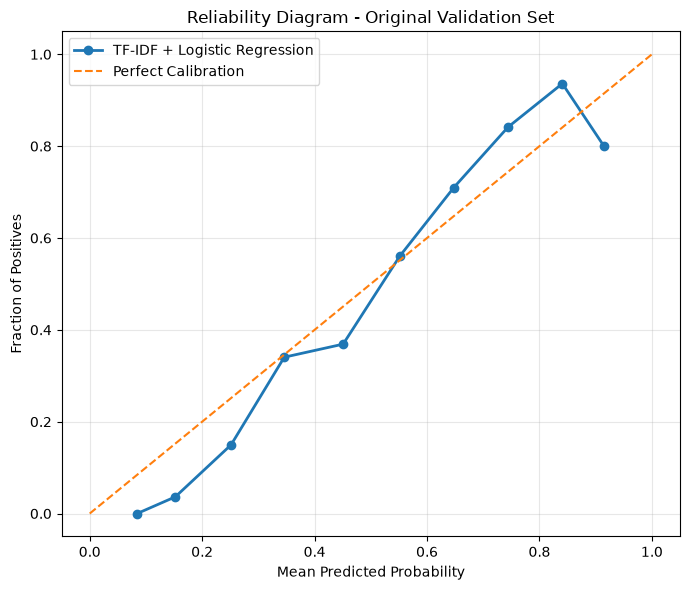

In [117]:
# ==========================================
# RELIABILITY DIAGRAM
# ==========================================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Calculate calibration values
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val_binary,
    val_probabilities,
    n_bins=10,
    strategy="uniform"
)

# Create plot
plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    linewidth=2,
    label="TF-IDF + Logistic Regression"
)

# Perfect calibration line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Diagram - Original Validation Set")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [118]:
# ==========================================
# EXPECTED CALIBRATION ERROR (ECE)
# ==========================================

import numpy as np

def calculate_ece(y_true, probabilities, n_bins=10):

    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    predicted_class = (probabilities >= 0.5).astype(int)
    confidence = np.maximum(
        probabilities,
        1 - probabilities
    )

    correct = (
        predicted_class == y_true
    ).astype(int)

    bin_edges = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (confidence >= bin_edges[i]) &
                (confidence <= bin_edges[i + 1])
            )
        else:
            mask = (
                (confidence >= bin_edges[i]) &
                (confidence < bin_edges[i + 1])
            )

        if np.sum(mask) == 0:
            continue

        bin_accuracy = correct[mask].mean()
        bin_confidence = confidence[mask].mean()

        bin_weight = np.sum(mask) / len(y_true)

        ece += (
            bin_weight *
            abs(bin_accuracy - bin_confidence)
        )

    return ece


ece = calculate_ece(
    y_val_binary,
    val_probabilities,
    n_bins=10
)

print("ECE:", round(ece, 4))

ECE: 0.0624


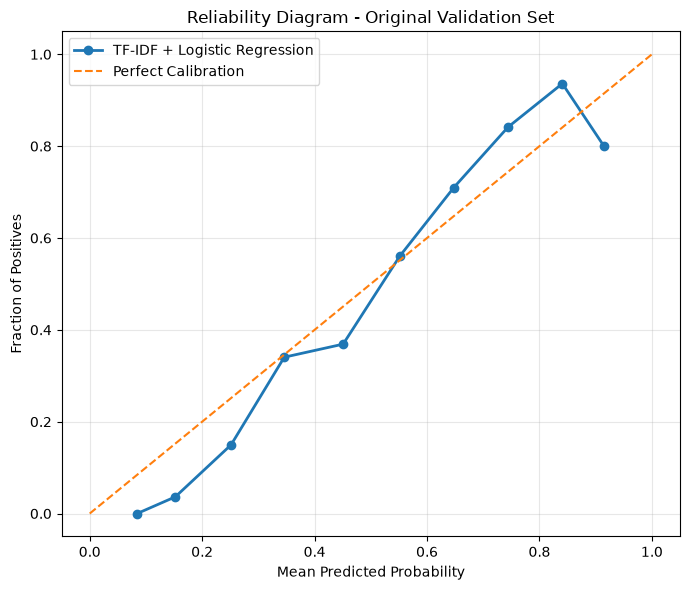

In [119]:
# ==========================================
# RELIABILITY DIAGRAM
# ==========================================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Calculate calibration values
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val_binary,
    val_probabilities,
    n_bins=10,
    strategy="uniform"
)

# Create plot
plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    linewidth=2,
    label="TF-IDF + Logistic Regression"
)

# Perfect calibration line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Diagram - Original Validation Set")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

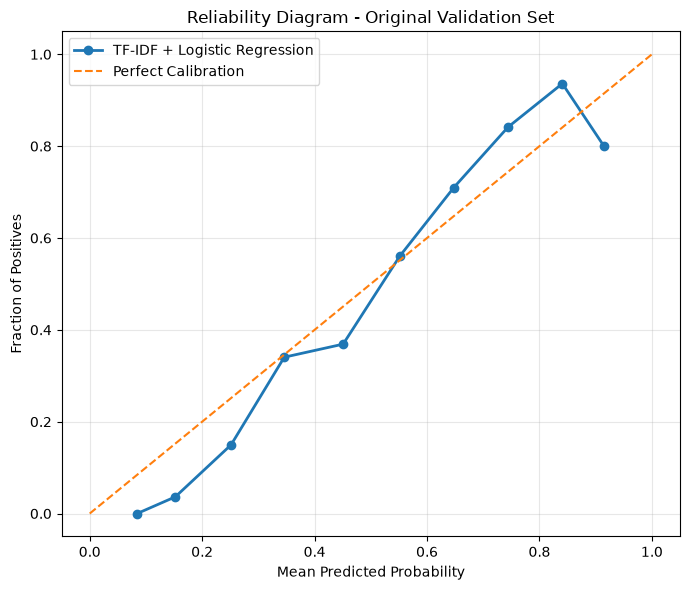

Reliability diagram saved successfully.


In [120]:
# ==========================================
# SAVE RELIABILITY DIAGRAM
# ==========================================

plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    linewidth=2,
    label="TF-IDF + Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Diagram - Original Validation Set")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../results/figures/reliability_diagram_original.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Reliability diagram saved successfully.")

In [121]:
# ==========================================
# CALIBRATION UNDER SPELLING SHIFTS
# ==========================================

from sklearn.metrics import brier_score_loss

# True labels
y_shift_binary = (script_shift_df["label"] == "hate").astype(int)


def get_hate_probabilities(texts):
    X = tfidf.transform(texts)
    probabilities = lr_model.predict_proba(X)

    hate_index = list(lr_model.classes_).index("hate")

    return probabilities[:, hate_index]


# Get probabilities
original_probs = get_hate_probabilities(
    script_shift_df["original_text"]
)

mild_probs = get_hate_probabilities(
    script_shift_df["mild_spelling"]
)

severe_probs = get_hate_probabilities(
    script_shift_df["severe_spelling"]
)


# Calculate Brier scores
original_brier = brier_score_loss(
    y_shift_binary,
    original_probs
)

mild_brier = brier_score_loss(
    y_shift_binary,
    mild_probs
)

severe_brier = brier_score_loss(
    y_shift_binary,
    severe_probs
)


# Calculate ECE
original_ece = calculate_ece(
    y_shift_binary,
    original_probs,
    n_bins=10
)

mild_ece = calculate_ece(
    y_shift_binary,
    mild_probs,
    n_bins=10
)

severe_ece = calculate_ece(
    y_shift_binary,
    severe_probs,
    n_bins=10
)


print("===== CALIBRATION UNDER SPELLING SHIFTS =====")

print("\nOriginal")
print("Brier Score:", round(original_brier, 4))
print("ECE:", round(original_ece, 4))

print("\nMild Spelling Shift")
print("Brier Score:", round(mild_brier, 4))
print("ECE:", round(mild_ece, 4))

print("\nSevere Spelling Shift")
print("Brier Score:", round(severe_brier, 4))
print("ECE:", round(severe_ece, 4))

===== CALIBRATION UNDER SPELLING SHIFTS =====

Original
Brier Score: 0.1819
ECE: 0.0624

Mild Spelling Shift
Brier Score: 0.1917
ECE: 0.0564

Severe Spelling Shift
Brier Score: 0.2018
ECE: 0.0516


In [122]:
# ==========================================
# CALIBRATION RESULTS TABLE
# ==========================================

shift_calibration_results = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],
    "Brier_Score": [
        original_brier,
        mild_brier,
        severe_brier
    ],
    "ECE": [
        original_ece,
        mild_ece,
        severe_ece
    ]
})

shift_calibration_results[
    ["Brier_Score", "ECE"]
] = shift_calibration_results[
    ["Brier_Score", "ECE"]
].round(4)

print(shift_calibration_results)

               Condition  Brier_Score     ECE
0               Original       0.1819  0.0624
1    Mild Spelling Shift       0.1917  0.0564
2  Severe Spelling Shift       0.2018  0.0516


In [123]:
shift_calibration_results.to_csv(
    "../results/tables/shift_calibration_results.csv",
    index=False
)

print("\nSaved successfully:")
print("../results/tables/shift_calibration_results.csv")


Saved successfully:
../results/tables/shift_calibration_results.csv


In [124]:
# ==========================================
# CREATE CALIBRATION SET
# ==========================================

from sklearn.model_selection import train_test_split

X_train_main, X_cal, y_train_main, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Main training samples:", len(X_train_main))
print("Calibration samples:", len(X_cal))
print("Validation samples:", len(X_val))

print("\nCalibration label distribution:")
print(y_cal.value_counts())

Main training samples: 2560
Calibration samples: 640
Validation samples: 800

Calibration label distribution:
label
non-hate    330
hate        310
Name: count, dtype: int64


In [125]:
# ==========================================
# TRAIN MODEL FOR TEMPERATURE SCALING
# ==========================================

cal_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

X_main_tfidf = cal_tfidf.fit_transform(X_train_main)
X_cal_tfidf = cal_tfidf.transform(X_cal)

cal_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

cal_model.fit(X_main_tfidf, y_train_main)

print("Calibration model trained successfully.")

Calibration model trained successfully.


In [126]:
# ==========================================
# CALIBRATION SET PROBABILITIES
# ==========================================

cal_probabilities = cal_model.predict_proba(
    X_cal_tfidf
)

print("Probability shape:", cal_probabilities.shape)
print("Classes:", cal_model.classes_)

Probability shape: (640, 2)
Classes: ['hate' 'non-hate']


In [127]:
# ============================================
# TRAIN CALIBRATION MODEL
# ============================================

cal_model.fit(X_main_tfidf, y_train_main)

print("Calibration model trained successfully.")

# Get raw decision scores (logits) on calibration set
cal_logits = cal_model.decision_function(X_cal_tfidf)

print("Calibration logits shape:", cal_logits.shape)
print("First 10 logits:")
print(cal_logits[:10])

Calibration model trained successfully.
Calibration logits shape: (640,)
First 10 logits:
[-1.09189937 -1.54703007  1.69724457 -0.20803182 -0.20803182 -0.23110798
 -0.22575669 -0.16542714  1.17077754 -0.22303671]


In [128]:
# ============================================
# LEARN OPTIMAL TEMPERATURE
# ============================================

import numpy as np
from scipy.optimize import minimize
from scipy.special import expit

# Convert labels to binary
# hate = 1, non-hate = 0
y_cal_binary = (y_cal == "hate").astype(int)

# Negative log-likelihood after temperature scaling
def temperature_nll(T):
    T = float(T[0])

    # Prevent invalid temperature
    if T <= 0:
        return 1e10

    scaled_logits = cal_logits / T
    probabilities = expit(scaled_logits)

    # Numerical stability
    probabilities = np.clip(probabilities, 1e-7, 1 - 1e-7)

    nll = -np.mean(
        y_cal_binary * np.log(probabilities)
        + (1 - y_cal_binary) * np.log(1 - probabilities)
    )

    return nll


# Optimize temperature
temperature_result = minimize(
    temperature_nll,
    x0=[1.0],
    method="Nelder-Mead"
)

optimal_temperature = float(temperature_result.x[0])

print("Optimal Temperature:", round(optimal_temperature, 4))
print("Calibration NLL:", round(temperature_result.fun, 4))
print("Optimization successful:", temperature_result.success)

Optimal Temperature: 1351079888211152.2
Calibration NLL: 0.6931
Optimization successful: False


In [129]:
# ============================================
# CHECK LOGISTIC REGRESSION CLASS ORDER
# ============================================

print("Model classes:", cal_model.classes_)

Model classes: ['hate' 'non-hate']


In [130]:
# ============================================
# CORRECTED TEMPERATURE SCALING
# ============================================

from scipy.optimize import minimize_scalar
from scipy.special import expit
import numpy as np

# The positive class is the SECOND class
positive_class = cal_model.classes_[1]

print("Positive class used for calibration:", positive_class)

# Correct binary labels
y_cal_binary_correct = (
    y_cal.astype(str) == str(positive_class)
).astype(int)

print("\nCalibration labels:")
print(pd.Series(y_cal_binary_correct).value_counts())

# Temperature-scaled NLL
def temperature_nll_scalar(T):
    if T <= 0:
        return 1e10

    scaled_logits = cal_logits / T
    probabilities = expit(scaled_logits)

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )

    nll = -np.mean(
        y_cal_binary_correct * np.log(probabilities)
        +
        (1 - y_cal_binary_correct) *
        np.log(1 - probabilities)
    )

    return nll


# Search for temperature in a reasonable range
temperature_result = minimize_scalar(
    temperature_nll_scalar,
    bounds=(0.05, 20.0),
    method="bounded"
)

optimal_temperature = float(temperature_result.x)

print("\n===== TEMPERATURE SCALING =====")
print("Optimal Temperature:", round(optimal_temperature, 4))
print("Calibration NLL:", round(temperature_result.fun, 4))
print("Optimization successful:", temperature_result.success)

Positive class used for calibration: non-hate

Calibration labels:
label
1    330
0    310
Name: count, dtype: int64

===== TEMPERATURE SCALING =====
Optimal Temperature: 0.7291
Calibration NLL: 0.5741
Optimization successful: True


In [133]:
# ==========================================
# CALIBRATED CONFIDENCE FOR ORIGINAL / SHIFTS
# ==========================================

# Use the SAME TF-IDF vectorizer used to train cal_model
X_val_cal = cal_tfidf.transform(X_val)

# Original validation logits
original_logits = cal_model.decision_function(X_val_cal)

# Apply temperature scaling
original_probs = 1 / (
    1 + np.exp(-original_logits / optimal_temperature)
)

# Confidence = probability of predicted class
original_predictions = (original_probs >= 0.5).astype(int)
original_conf = np.maximum(original_probs, 1 - original_probs)

print("Original mean confidence:",
      round(original_conf.mean(), 4))

print("Original confidence range:",
      round(original_conf.min(), 4),
      "to",
      round(original_conf.max(), 4))

Original mean confidence: 0.7097
Original confidence range: 0.5001 to 0.9764


In [135]:
# Check variables related to spelling shifts
[name for name in globals() if "mild" in name.lower() or "severe" in name.lower()]

['add_mild_spelling_noise',
 'add_severe_spelling_noise',
 'mild',
 'severe',
 'mild_changed',
 'severe_changed',
 'result_mild',
 'pred_mild',
 'result_severe',
 'pred_severe',
 'original_to_mild',
 'original_to_severe',
 'mild_to_severe',
 'prob_mild',
 'prob_severe',
 'confidence_mild',
 'confidence_severe',
 'original_to_mild_conf',
 'original_to_severe_conf',
 'mild_conf',
 'severe_conf',
 'mild_mean_conf',
 'severe_mean_conf',
 'mild_to_severe_conf',
 'mild_probs',
 'severe_probs',
 'mild_brier',
 'severe_brier',
 'mild_ece',
 'severe_ece']

In [137]:
# ============================================
# CALIBRATED CONFIDENCE FOR SPELLING SHIFTS
# ============================================

def get_calibrated_confidence(texts):

    # If only one string is provided, convert it to a list
    if isinstance(texts, str):
        texts = [texts]

    # Convert using the SAME TF-IDF vectorizer
    X_shift = cal_tfidf.transform(texts)

    # Get model logits
    logits = cal_model.decision_function(X_shift)

    # Apply temperature scaling
    probabilities = 1 / (
        1 + np.exp(-logits / optimal_temperature)
    )

    # Predicted class
    predictions = (probabilities >= 0.5).astype(int)

    # Confidence of predicted class
    confidence = np.maximum(
        probabilities,
        1 - probabilities
    )

    return predictions, confidence

In [138]:
# Test with your mild spelling-shift data
mild_pred_cal, mild_conf_cal = get_calibrated_confidence(mild)

print("Mild prediction:", mild_pred_cal)
print("Mild confidence:", mild_conf_cal)

Mild prediction: [0]
Mild confidence: [0.54036174]


In [139]:
# Test with severe spelling-shift data
severe_pred_cal, severe_conf_cal = get_calibrated_confidence(severe)

print("Severe prediction:", severe_pred_cal)
print("Severe confidence:", severe_conf_cal)

Severe prediction: [1]
Severe confidence: [0.60801889]


In [142]:
import random
import re

# ============================================
# SPELLING SHIFT FUNCTIONS
# ============================================

def add_mild_spelling_noise(text):
    """
    Mild spelling shift:
    - Randomly repeats a character
    - Randomly removes a character
    - Small amount of noise
    """
    words = str(text).split()
    new_words = []

    for word in words:
        if len(word) < 4:
            new_words.append(word)
            continue

        chars = list(word)

        # Small probability of repeating a character
        if random.random() < 0.20:
            i = random.randrange(len(chars))
            chars.insert(i, chars[i])

        # Small probability of removing a character
        elif random.random() < 0.15:
            i = random.randrange(len(chars))
            chars.pop(i)

        new_words.append("".join(chars))

    return " ".join(new_words)


def add_severe_spelling_noise(text):
    """
    Severe spelling shift:
    - More character repetition
    - More character deletion
    - Occasional character swap
    - Higher noise level than mild
    """

    words = str(text).split()
    new_words = []

    for word in words:

        if len(word) < 4:
            new_words.append(word)
            continue

        chars = list(word)

        # 1. Character repetition
        if random.random() < 0.40:
            i = random.randrange(len(chars))
            chars.insert(i, chars[i])

        # 2. Character deletion
        if len(chars) >= 4 and random.random() < 0.30:
            i = random.randrange(len(chars))
            chars.pop(i)

        # 3. Adjacent character swap
        if len(chars) >= 4 and random.random() < 0.25:
            i = random.randrange(len(chars) - 1)
            chars[i], chars[i + 1] = chars[i + 1], chars[i]

        new_words.append("".join(chars))

    return " ".join(new_words)


print("Spelling-shift functions loaded successfully.")

Spelling-shift functions loaded successfully.


In [143]:
# ============================================
# CREATE SPELLING-SHIFTED VALIDATION SETS
# ============================================

validation_texts = X_val.tolist()

mild_shifted_texts = [
    add_mild_spelling_noise(text)
    for text in validation_texts
]

severe_shifted_texts = [
    add_severe_spelling_noise(text)
    for text in validation_texts
]

print("Original validation texts:", len(validation_texts))
print("Mild shifted texts:", len(mild_shifted_texts))
print("Severe shifted texts:", len(severe_shifted_texts))

Original validation texts: 800
Mild shifted texts: 800
Severe shifted texts: 800


In [144]:
for i in range(5):
    print("\n========== Example", i + 1, "==========")
    print("Original :", validation_texts[i])
    print("Mild     :", mild_shifted_texts[i])
    print("Severe   :", severe_shifted_texts[i])


========== Example 1 ==========
Original : స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయనకి పార్టీ కి చెడ్డ పేరు వస్తుంది
Mild     : స్త్రీలను వీధిలోకి లగకంది పపవన్ గారు చూస్తేే ఆయననకి పార్టీ కి చెడ్డ పేరుు వస్తుంది
Severe   : ్సత్రీలను వీధలిోకి లగకకంద పవన్ ాగరు చస్తే ఆయనకి పార్టీ కి చెడ్డ పరు వస్తుంది

========== Example 2 ==========
Original : Gudha paguldegale
Mild     : Gudha paguldegle
Severe   : Gudha paguldegale

========== Example 3 ==========
Original : Nijanga ilanti extraordinary persons untaru
Mild     : Nijanga ilanti extraordinary persons unntaru
Severe   : Niijanga ilannti extraordinary prsons untaru

========== Example 4 ==========
Original : నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అండి ఇందులోనుంచి డబ్బులు వస్తే ఏపించుకుందాం అని చూస్తున్న... మాములుగా లేదు అనుదీప్ గారి పంచెస్
Mild     : నాకు ఇంటర్నెట్ మొబైల్ డేటా లేదు అంి ఇందుులోనుంచి డబ్బులు వస్తే ఏపించుుందాం అని చూస్తున్న... మాములుగా లేదు అనుదీప్ గారిి పంచెస్
Severe   : నకాు ంఇటట్నెట్ మొబైల్్ డేటటా లలదేు అండి ఇందులోనుంచి డబ్బ

In [145]:
# ============================================
# CALIBRATED CONFIDENCE FOR SPELLING SHIFTS
# ============================================

# Original validation
original_pred_cal, original_conf_cal = get_calibrated_confidence(
    X_val.tolist()
)

# Mild spelling shift
mild_pred_cal, mild_conf_cal = get_calibrated_confidence(
    mild_shifted_texts
)

# Severe spelling shift
severe_pred_cal, severe_conf_cal = get_calibrated_confidence(
    severe_shifted_texts
)

print("===== CALIBRATED CONFIDENCE =====")

print("Original mean confidence:",
      round(original_conf_cal.mean(), 4))

print("Mild mean confidence:",
      round(mild_conf_cal.mean(), 4))

print("Severe mean confidence:",
      round(severe_conf_cal.mean(), 4))

print("\nOriginal confidence range:",
      round(original_conf_cal.min(), 4),
      "to",
      round(original_conf_cal.max(), 4))

print("Mild confidence range:",
      round(mild_conf_cal.min(), 4),
      "to",
      round(mild_conf_cal.max(), 4))

print("Severe confidence range:",
      round(severe_conf_cal.min(), 4),
      "to",
      round(severe_conf_cal.max(), 4))

===== CALIBRATED CONFIDENCE =====
Original mean confidence: 0.7097
Mild mean confidence: 0.6954
Severe mean confidence: 0.6816

Original confidence range: 0.5001 to 0.9764
Mild confidence range: 0.5001 to 0.9764
Severe confidence range: 0.5003 to 0.9569


In [146]:
# ============================================
# PREDICTION FLIP RATE
# ============================================

original_pred_cal = np.asarray(original_pred_cal)
mild_pred_cal = np.asarray(mild_pred_cal)
severe_pred_cal = np.asarray(severe_pred_cal)

# Original → Mild
flip_original_mild = np.mean(
    original_pred_cal != mild_pred_cal
)

# Original → Severe
flip_original_severe = np.mean(
    original_pred_cal != severe_pred_cal
)

# Mild → Severe
flip_mild_severe = np.mean(
    mild_pred_cal != severe_pred_cal
)

print("===== PREDICTION FLIP RATE =====")

print(
    "Original → Mild:",
    round(flip_original_mild, 4),
    "(",
    round(flip_original_mild * 100, 2),
    "%)"
)

print(
    "Original → Severe:",
    round(flip_original_severe, 4),
    "(",
    round(flip_original_severe * 100, 2),
    "%)"
)

print(
    "Mild → Severe:",
    round(flip_mild_severe, 4),
    "(",
    round(flip_mild_severe * 100, 2),
    "%)"
)

===== PREDICTION FLIP RATE =====
Original → Mild: 0.0712 ( 7.12 %)
Original → Severe: 0.17 ( 17.0 %)
Mild → Severe: 0.1713 ( 17.12 %)


In [148]:
# Convert string labels to binary labels
# non-hate = 0
# hate = 1

y_val_binary = np.asarray(y_val).astype(str)

y_val_binary = np.where(
    y_val_binary == "hate",
    1,
    0
)

print("Binary validation labels:")
print(np.unique(y_val_binary, return_counts=True))

Binary validation labels:
(array([0, 1]), array([412, 388]))


In [149]:
# Convert string labels to binary labels

y_val_binary = np.where(
    np.asarray(y_val).astype(str) == "hate",
    1,
    0
)

print("Binary validation labels:")
print(np.unique(y_val_binary, return_counts=True))

Binary validation labels:
(array([0, 1]), array([412, 388]))


In [151]:
# Check variables currently available in the notebook

[x for x in globals().keys()
 if any(word in x.lower() for word in ["prob", "confidence", "original", "mild", "severe"])]

['y_proba',
 'confidence',
 'confidence_df',
 'add_mild_spelling_noise',
 'add_severe_spelling_noise',
 'mild',
 'severe',
 'mild_changed',
 'severe_changed',
 'result_original',
 'pred_original',
 'result_mild',
 'pred_mild',
 'result_severe',
 'pred_severe',
 'original_to_mild',
 'original_to_severe',
 'mild_to_severe',
 'prob_original',
 'prob_mild',
 'prob_severe',
 'confidence_original',
 'confidence_mild',
 'confidence_severe',
 'original_to_mild_conf',
 'original_to_severe_conf',
 'get_confidence_results',
 'original_conf',
 'get_confidence',
 'mild_conf',
 'severe_conf',
 'original_mean_conf',
 'mild_mean_conf',
 'severe_mean_conf',
 'mild_to_severe_conf',
 'confidence_results',
 'val_probabilities',
 'get_hate_probabilities',
 'original_probs',
 'mild_probs',
 'severe_probs',
 'original_brier',
 'mild_brier',
 'severe_brier',
 'original_ece',
 'mild_ece',
 'severe_ece',
 'cal_probabilities',
 'original_logits',
 'original_predictions',
 'get_calibrated_confidence',
 'mild_pred

In [153]:
import numpy as np
from sklearn.metrics import brier_score_loss, log_loss

# ==========================================
# PREPARE BINARY PROBABILITIES
# ==========================================

y_true = np.asarray(y_val_binary).astype(int)

# Take probability of class = "hate" (class 1)
original_prob_1 = np.asarray(original_prob)[:, 1]
mild_prob_1 = np.asarray(mild_prob)[:, 1]
severe_prob_1 = np.asarray(severe_prob)[:, 1]

print("Shapes:")
print("True labels :", y_true.shape)
print("Original    :", original_prob_1.shape)
print("Mild        :", mild_prob_1.shape)
print("Severe      :", severe_prob_1.shape)


# ==========================================
# ECE FUNCTION
# ==========================================

def calculate_ece(y_true, probabilities, n_bins=10):

    y_true = np.asarray(y_true).astype(int)
    probabilities = np.asarray(probabilities).astype(float)

    predictions = (probabilities >= 0.5).astype(int)

    correctness = (predictions == y_true).astype(int)

    ece = 0.0

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (probabilities >= bin_edges[i]) &
                (probabilities <= bin_edges[i + 1])
            )
        else:
            mask = (
                (probabilities >= bin_edges[i]) &
                (probabilities < bin_edges[i + 1])
            )

        if np.sum(mask) == 0:
            continue

        bin_accuracy = np.mean(correctness[mask])
        bin_confidence = np.mean(probabilities[mask])
        bin_fraction = np.mean(mask)

        ece += abs(bin_accuracy - bin_confidence) * bin_fraction

    return ece


# ==========================================
# BRIER SCORE
# ==========================================

original_brier = brier_score_loss(y_true, original_prob_1)
mild_brier = brier_score_loss(y_true, mild_prob_1)
severe_brier = brier_score_loss(y_true, severe_prob_1)


# ==========================================
# ECE
# ==========================================

original_ece = calculate_ece(y_true, original_prob_1)
mild_ece = calculate_ece(y_true, mild_prob_1)
severe_ece = calculate_ece(y_true, severe_prob_1)


# ==========================================
# NLL
# ==========================================

original_nll = log_loss(y_true, original_prob_1)
mild_nll = log_loss(y_true, mild_prob_1)
severe_nll = log_loss(y_true, severe_prob_1)


# ==========================================
# RESULTS
# ==========================================

print("\n========== CALIBRATION METRICS ==========")

print("\nOriginal")
print("Brier Score:", round(original_brier, 4))
print("ECE        :", round(original_ece, 4))
print("NLL        :", round(original_nll, 4))

print("\nMild Spelling Shift")
print("Brier Score:", round(mild_brier, 4))
print("ECE        :", round(mild_ece, 4))
print("NLL        :", round(mild_nll, 4))

print("\nSevere Spelling Shift")
print("Brier Score:", round(severe_brier, 4))
print("ECE        :", round(severe_ece, 4))
print("NLL        :", round(severe_nll, 4))

Shapes:
True labels : (800,)
Original    : (800,)
Mild        : (800,)
Severe      : (800,)

========== CALIBRATION METRICS ==========

Original
Brier Score: 0.3992
ECE        : 0.2387
NLL        : 1.048

Mild Spelling Shift
Brier Score: 0.3798
ECE        : 0.2108
NLL        : 0.9991

Severe Spelling Shift
Brier Score: 0.3603
ECE        : 0.1871
NLL        : 0.9499


In [154]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Predictions
pred_original = np.argmax(original_prob, axis=1)
pred_mild = np.argmax(mild_prob, axis=1)
pred_severe = np.argmax(severe_prob, axis=1)

# True labels
y_true = y_val_binary

conditions = {
    "Original": pred_original,
    "Mild Spelling Shift": pred_mild,
    "Severe Spelling Shift": pred_severe
}

performance_results = []

for condition, preds in conditions.items():

    accuracy = accuracy_score(y_true, preds)
    balanced_acc = balanced_accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    macro_precision = precision_score(
        y_true, preds, average="macro", zero_division=0
    )
    macro_recall = recall_score(
        y_true, preds, average="macro", zero_division=0
    )

    performance_results.append({
        "Condition": condition,
        "Accuracy": accuracy,
        "Balanced_Accuracy": balanced_acc,
        "Macro_F1": macro_f1,
        "Macro_Precision": macro_precision,
        "Macro_Recall": macro_recall
    })

performance_df = pd.DataFrame(performance_results)

print("========== PERFORMANCE UNDER SPELLING SHIFT ==========")
print(performance_df.round(4))

========== PERFORMANCE UNDER SPELLING SHIFT ==========
               Condition  Accuracy  Balanced_Accuracy  Macro_F1  \
0               Original    0.2688             0.2681    0.2680   
1    Mild Spelling Shift    0.2875             0.2860    0.2851   
2  Severe Spelling Shift    0.3075             0.3051    0.3022   

   Macro_Precision  Macro_Recall  
0           0.2680        0.2681  
1           0.2847        0.2860  
2           0.3011        0.3051  


In [155]:
# Calculate performance degradation relative to Original

original_f1 = performance_df.loc[
    performance_df["Condition"] == "Original", "Macro_F1"
].iloc[0]

performance_df["F1_Change_vs_Original"] = (
    performance_df["Macro_F1"] - original_f1
)

print("\n========== CHANGE FROM ORIGINAL ==========")
print(
    performance_df[
        ["Condition", "Macro_F1", "F1_Change_vs_Original"]
    ].round(4)
)


========== CHANGE FROM ORIGINAL ==========
               Condition  Macro_F1  F1_Change_vs_Original
0               Original    0.2680                 0.0000
1    Mild Spelling Shift    0.2851                 0.0171
2  Severe Spelling Shift    0.3022                 0.0341


In [ ]:
import sys
import matplotlib

print("Python:", sys.executable)
print("Matplotlib:", matplotlib.__version__)

Python: c:\Users\Divya\AppData\Local\Programs\Python\Python311\python.exe
Matplotlib: 3.11.2


In [156]:
# Save performance results

import os

os.makedirs("../results/tables", exist_ok=True)

performance_df.to_csv(
    "../results/tables/spelling_shift_performance.csv",
    index=False
)

print("Saved:")
print("../results/tables/spelling_shift_performance.csv")

Saved:
../results/tables/spelling_shift_performance.csv


In [157]:
# ==========================================
# FALSE-SAFE RATE ANALYSIS
# ==========================================

def calculate_false_safe_rate(y_true, probabilities, threshold=0.80):
    """
    False-safe:
    True label = hate (1)
    Model predicts non-hate (0)
    with confidence >= threshold
    """

    probabilities = np.asarray(probabilities)

    # Probability of non-hate
    non_hate_prob = probabilities[:, 0]

    # High-confidence non-hate predictions
    predicted_non_hate = non_hate_prob >= threshold

    # Actually hate
    actual_hate = y_true == 1

    false_safe = predicted_non_hate & actual_hate

    # Denominator = all actual hate examples
    total_hate = np.sum(actual_hate)

    if total_hate == 0:
        return 0.0, 0

    rate = np.sum(false_safe) / total_hate

    return rate, np.sum(false_safe)


thresholds = [0.60, 0.70, 0.80, 0.90]

false_safe_results = []

for threshold in thresholds:

    original_rate, original_count = calculate_false_safe_rate(
        y_true, original_prob, threshold
    )

    mild_rate, mild_count = calculate_false_safe_rate(
        y_true, mild_prob, threshold
    )

    severe_rate, severe_count = calculate_false_safe_rate(
        y_true, severe_prob, threshold
    )

    false_safe_results.append({
        "Threshold": threshold,
        "Original_FSR": original_rate,
        "Mild_FSR": mild_rate,
        "Severe_FSR": severe_rate,
        "Original_Count": original_count,
        "Mild_Count": mild_count,
        "Severe_Count": severe_count
    })

false_safe_df = pd.DataFrame(false_safe_results)

print("========== FALSE-SAFE RATE ==========")
print(false_safe_df.round(4))

========== FALSE-SAFE RATE ==========
   Threshold  Original_FSR  Mild_FSR  Severe_FSR  Original_Count  Mild_Count  \
0        0.6        0.5412    0.5180      0.4923             210         201   
1        0.7        0.3015    0.2887      0.2423             117         112   
2        0.8        0.1237    0.1134      0.0876              48          44   
3        0.9        0.0103    0.0129      0.0077               4           5   

   Severe_Count  
0           191  
1            94  
2            34  
3             3  


In [158]:
# ==========================================
# RISK-COVERAGE ANALYSIS
# ==========================================

def risk_coverage(y_true, probabilities, thresholds):
    
    probabilities = np.asarray(probabilities)
    
    # Maximum confidence
    confidence = np.max(probabilities, axis=1)
    
    # Predicted class
    predictions = np.argmax(probabilities, axis=1)
    
    results = []

    for threshold in thresholds:
        
        # Cases model is confident enough to classify automatically
        accepted = confidence >= threshold
        
        coverage = np.mean(accepted)

        if np.sum(accepted) > 0:
            risk = np.mean(
                predictions[accepted] != y_true[accepted]
            )
        else:
            risk = np.nan

        results.append({
            "Threshold": threshold,
            "Coverage": coverage,
            "Risk": risk,
            "Accepted": np.sum(accepted),
            "Abstained": np.sum(~accepted)
        })

    return pd.DataFrame(results)


risk_thresholds = np.arange(0.50, 1.00, 0.05)

risk_original = risk_coverage(
    y_true,
    original_prob,
    risk_thresholds
)

risk_mild = risk_coverage(
    y_true,
    mild_prob,
    risk_thresholds
)

risk_severe = risk_coverage(
    y_true,
    severe_prob,
    risk_thresholds
)


print("========== ORIGINAL ==========")
print(risk_original.round(4))

print("\n========== MILD SPELLING SHIFT ==========")
print(risk_mild.round(4))

print("\n========== SEVERE SPELLING SHIFT ==========")
print(risk_severe.round(4))

========== ORIGINAL ==========
   Threshold  Coverage    Risk  Accepted  Abstained
0       0.50    1.0000  0.7312       800          0
1       0.55    0.8512  0.7651       681        119
2       0.60    0.6625  0.8019       530        270
3       0.65    0.5275  0.8578       422        378
4       0.70    0.3812  0.8852       305        495
5       0.75    0.2562  0.9122       205        595
6       0.80    0.1450  0.9483       116        684
7       0.85    0.0700  0.9821        56        744
8       0.90    0.0175  0.9286        14        786
9       0.95    0.0000     NaN         0        800

========== MILD SPELLING SHIFT ==========
   Threshold  Coverage    Risk  Accepted  Abstained
0       0.50    1.0000  0.7125       800          0
1       0.55    0.8288  0.7406       663        137
2       0.60    0.6225  0.7831       498        302
3       0.65    0.4775  0.8377       382        418
4       0.70    0.3388  0.8672       271        529
5       0.75    0.2125  0.9118       170  

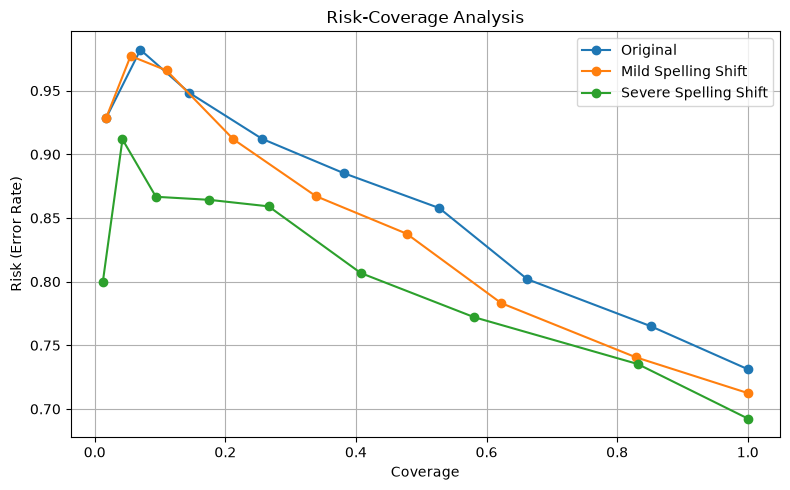

In [159]:
# ==========================================
# RISK-COVERAGE CURVE
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    risk_original["Coverage"],
    risk_original["Risk"],
    marker="o",
    label="Original"
)

plt.plot(
    risk_mild["Coverage"],
    risk_mild["Risk"],
    marker="o",
    label="Mild Spelling Shift"
)

plt.plot(
    risk_severe["Coverage"],
    risk_severe["Risk"],
    marker="o",
    label="Severe Spelling Shift"
)

plt.xlabel("Coverage")
plt.ylabel("Risk (Error Rate)")
plt.title("Risk-Coverage Analysis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [160]:
risk_original.to_csv(
    "../results/tables/risk_coverage_original.csv",
    index=False
)

risk_mild.to_csv(
    "../results/tables/risk_coverage_mild.csv",
    index=False
)

risk_severe.to_csv(
    "../results/tables/risk_coverage_severe.csv",
    index=False
)

print("Risk-coverage results saved successfully.")

Risk-coverage results saved successfully.


In [161]:
# ==========================================
# RISK-COVERAGE ANALYSIS
# ==========================================

def risk_coverage(y_true, probabilities, thresholds):

    probabilities = np.asarray(probabilities)

    # Model confidence = highest class probability
    confidence = np.max(probabilities, axis=1)

    # Predicted class
    predictions = np.argmax(probabilities, axis=1)

    results = []

    for threshold in thresholds:

        # Automatically classify only confident samples
        accepted = confidence >= threshold

        coverage = np.mean(accepted)

        if np.sum(accepted) > 0:
            risk = np.mean(
                predictions[accepted] != y_true[accepted]
            )
        else:
            risk = np.nan

        results.append({
            "Threshold": threshold,
            "Coverage": coverage,
            "Risk": risk,
            "Accepted": np.sum(accepted),
            "Abstained": np.sum(~accepted)
        })

    return pd.DataFrame(results)


risk_thresholds = np.arange(0.50, 1.00, 0.05)

risk_original = risk_coverage(
    y_true,
    original_prob,
    risk_thresholds
)

risk_mild = risk_coverage(
    y_true,
    mild_prob,
    risk_thresholds
)

risk_severe = risk_coverage(
    y_true,
    severe_prob,
    risk_thresholds
)

print("========== ORIGINAL ==========")
print(risk_original.round(4))

print("\n========== MILD SPELLING SHIFT ==========")
print(risk_mild.round(4))

print("\n========== SEVERE SPELLING SHIFT ==========")
print(risk_severe.round(4))

========== ORIGINAL ==========
   Threshold  Coverage    Risk  Accepted  Abstained
0       0.50    1.0000  0.7312       800          0
1       0.55    0.8512  0.7651       681        119
2       0.60    0.6625  0.8019       530        270
3       0.65    0.5275  0.8578       422        378
4       0.70    0.3812  0.8852       305        495
5       0.75    0.2562  0.9122       205        595
6       0.80    0.1450  0.9483       116        684
7       0.85    0.0700  0.9821        56        744
8       0.90    0.0175  0.9286        14        786
9       0.95    0.0000     NaN         0        800

========== MILD SPELLING SHIFT ==========
   Threshold  Coverage    Risk  Accepted  Abstained
0       0.50    1.0000  0.7125       800          0
1       0.55    0.8288  0.7406       663        137
2       0.60    0.6225  0.7831       498        302
3       0.65    0.4775  0.8377       382        418
4       0.70    0.3388  0.8672       271        529
5       0.75    0.2125  0.9118       170  

In [162]:
# ============================================
# GLOBAL CONFORMAL PREDICTION
# ============================================

import numpy as np
import pandas as pd

print("Starting Global Conformal Prediction...")

# --------------------------------------------
# 1. Make sure probabilities are available
# --------------------------------------------

y_true = np.asarray(y_val_binary).astype(int)

original_prob = np.asarray(original_prob)
mild_prob = np.asarray(mild_prob)
severe_prob = np.asarray(severe_prob)

print("True labels shape:", y_true.shape)
print("Original probabilities:", original_prob.shape)
print("Mild probabilities:", mild_prob.shape)
print("Severe probabilities:", severe_prob.shape)


# --------------------------------------------
# 2. Convert probabilities to probability
#    of the TRUE class
# --------------------------------------------

def true_class_probability(probabilities, y):
    return probabilities[np.arange(len(y)), y]


# --------------------------------------------
# 3. Non-conformity score
#    score = 1 - probability of true class
# --------------------------------------------

original_scores = 1 - true_class_probability(original_prob, y_true)
mild_scores = 1 - true_class_probability(mild_prob, y_true)
severe_scores = 1 - true_class_probability(severe_prob, y_true)


# --------------------------------------------
# 4. Conformal quantile
# --------------------------------------------

def conformal_quantile(scores, alpha=0.10):
    """
    Finite-sample conformal quantile.
    alpha = desired miscoverage rate.
    """
    
    scores = np.sort(np.asarray(scores))
    n = len(scores)

    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)

    return np.quantile(scores, q_level, method="higher")


# --------------------------------------------
# 5. Create prediction sets
# --------------------------------------------

def create_prediction_sets(probabilities, threshold):
    
    prediction_sets = []
    
    for probs in probabilities:
        
        # Include class if 1 - probability <= threshold
        included = np.where(1 - probs <= threshold)[0]
        
        prediction_sets.append(included.tolist())
    
    return prediction_sets


# --------------------------------------------
# 6. Evaluate conformal prediction
# --------------------------------------------

def evaluate_conformal(prediction_sets, y):
    
    coverage = np.mean([
        y[i] in prediction_sets[i]
        for i in range(len(y))
    ])
    
    set_sizes = np.array([
        len(s)
        for s in prediction_sets
    ])
    
    avg_set_size = np.mean(set_sizes)
    
    # Empty prediction set = abstention
    abstention_rate = np.mean(set_sizes == 0)
    
    return {
        "Coverage": coverage,
        "Average_Set_Size": avg_set_size,
        "Abstention_Rate": abstention_rate
    }


# --------------------------------------------
# 7. Choose 90% target coverage
# --------------------------------------------

alpha = 0.10

original_threshold = conformal_quantile(
    original_scores,
    alpha
)

mild_threshold = conformal_quantile(
    mild_scores,
    alpha
)

severe_threshold = conformal_quantile(
    severe_scores,
    alpha
)


# --------------------------------------------
# 8. Generate prediction sets
# --------------------------------------------

original_sets = create_prediction_sets(
    original_prob,
    original_threshold
)

mild_sets = create_prediction_sets(
    mild_prob,
    mild_threshold
)

severe_sets = create_prediction_sets(
    severe_prob,
    severe_threshold
)


# --------------------------------------------
# 9. Evaluate
# --------------------------------------------

original_conformal = evaluate_conformal(
    original_sets,
    y_true
)

mild_conformal = evaluate_conformal(
    mild_sets,
    y_true
)

severe_conformal = evaluate_conformal(
    severe_sets,
    y_true
)


# --------------------------------------------
# 10. Display results
# --------------------------------------------

conformal_results = pd.DataFrame([
    {
        "Condition": "Original",
        "Target_Coverage": 1 - alpha,
        "Threshold": original_threshold,
        **original_conformal
    },
    {
        "Condition": "Mild Spelling Shift",
        "Target_Coverage": 1 - alpha,
        "Threshold": mild_threshold,
        **mild_conformal
    },
    {
        "Condition": "Severe Spelling Shift",
        "Target_Coverage": 1 - alpha,
        "Threshold": severe_threshold,
        **severe_conformal
    }
])

print("\n========== GLOBAL CONFORMAL PREDICTION ==========")
print(conformal_results.round(4))

Starting Global Conformal Prediction...
True labels shape: (800,)
Original probabilities: (800, 2)
Mild probabilities: (800, 2)
Severe probabilities: (800, 2)

========== GLOBAL CONFORMAL PREDICTION ==========
               Condition  Target_Coverage  Threshold  Coverage  \
0               Original              0.9     0.8287    0.9025   
1    Mild Spelling Shift              0.9     0.8085    0.9025   
2  Severe Spelling Shift              0.9     0.7884    0.9025   

   Average_Set_Size  Abstention_Rate  
0            1.9000              0.0  
1            1.9000              0.0  
2            1.8888              0.0  


In [163]:
# ============================================
# SAVE GLOBAL CONFORMAL RESULTS
# ============================================

import os

os.makedirs("../results/tables", exist_ok=True)

conformal_results.to_csv(
    "../results/tables/global_conformal_results.csv",
    index=False
)

print("Saved:")
print("../results/tables/global_conformal_results.csv")

Saved:
../results/tables/global_conformal_results.csv


In [165]:
# ============================================
# SCRIPT-AWARE CONFORMAL: CALIBRATION SPLIT
# ============================================

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Convert validation texts to array
X_val_array = np.asarray(X_val)
y_val_array = np.asarray(y_val)

# Script type for each validation comment
val_script_types = np.array([
    classify_script(text) for text in X_val_array
])

# Create indices
indices = np.arange(len(y_val_array))

# 50% calibration, 50% evaluation
cal_idx, eval_idx = train_test_split(
    indices,
    test_size=0.50,
    random_state=42,
    stratify=y_val_array
)

print("Total validation samples:", len(indices))
print("Calibration samples:", len(cal_idx))
print("Evaluation samples:", len(eval_idx))

print("\nCalibration label distribution:")
print(pd.Series(y_val_array[cal_idx]).value_counts())

print("\nEvaluation label distribution:")
print(pd.Series(y_val_array[eval_idx]).value_counts())

print("\nCalibration script distribution:")
print(pd.Series(val_script_types[cal_idx]).value_counts())

print("\nEvaluation script distribution:")
print(pd.Series(val_script_types[eval_idx]).value_counts())

Total validation samples: 800
Calibration samples: 400
Evaluation samples: 400

Calibration label distribution:
non-hate    206
hate        194
Name: count, dtype: int64

Evaluation label distribution:
non-hate    206
hate        194
Name: count, dtype: int64

Calibration script distribution:
Latin/Romanized    221
Telugu             131
Mixed               47
Other                1
Name: count, dtype: int64

Evaluation script distribution:
Latin/Romanized    231
Telugu             132
Mixed               37
Name: count, dtype: int64


In [166]:
# ============================================
# SCRIPT-AWARE CONFORMAL THRESHOLDS
# ============================================

def get_true_class_scores(probabilities, y):
    return 1 - probabilities[
        np.arange(len(y)), y
    ]


def get_conformal_threshold(scores, alpha=0.10):
    scores = np.sort(np.asarray(scores))
    n = len(scores)

    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)

    return np.quantile(
        scores,
        q_level,
        method="higher"
    )


# Convert validation labels
y_val_binary_all = np.where(
    np.asarray(y_val).astype(str) == "hate",
    1,
    0
)

# Script groups
script_groups = [
    "Latin/Romanized",
    "Telugu",
    "Mixed"
]

alpha = 0.10

script_thresholds = []

for script in script_groups:

    # Calibration samples belonging to this script
    mask = val_script_types[cal_idx] == script

    group_indices = cal_idx[mask]

    print("\n--------------------------------")
    print("Script:", script)
    print("Calibration samples:", len(group_indices))

    if len(group_indices) < 10:
        print("Too few samples — skipped.")
        continue

    # Original probabilities
    probs = original_prob[group_indices]

    labels = y_val_binary_all[group_indices]

    # Non-conformity scores
    scores = get_true_class_scores(
        probs,
        labels
    )

    threshold = get_conformal_threshold(
        scores,
        alpha=alpha
    )

    script_thresholds.append({
        "Script": script,
        "Calibration_Samples": len(group_indices),
        "Threshold": threshold,
        "Target_Coverage": 1 - alpha
    })

script_thresholds_df = pd.DataFrame(
    script_thresholds
)

print("\n========== SCRIPT-AWARE THRESHOLDS ==========")
print(
    script_thresholds_df.round(4)
)


--------------------------------
Script: Latin/Romanized
Calibration samples: 221

--------------------------------
Script: Telugu
Calibration samples: 131

--------------------------------
Script: Mixed
Calibration samples: 47

========== SCRIPT-AWARE THRESHOLDS ==========
            Script  Calibration_Samples  Threshold  Target_Coverage
0  Latin/Romanized                  221     0.7981              0.9
1           Telugu                  131     0.8083              0.9
2            Mixed                   47     0.8824              0.9


In [167]:
# ============================================
# SCRIPT-AWARE CONFORMAL EVALUATION
# ============================================

def evaluate_script_aware_conformal(
    probabilities,
    y_true,
    script_types,
    eval_indices,
    threshold_df
):
    
    results = []

    for script in ["Latin/Romanized", "Telugu", "Mixed"]:

        # Samples of this script in evaluation set
        mask = script_types[eval_indices] == script

        indices = eval_indices[mask]

        if len(indices) == 0:
            continue

        # Get threshold learned from calibration set
        row = threshold_df[
            threshold_df["Script"] == script
        ]

        if len(row) == 0:
            continue

        threshold = row.iloc[0]["Threshold"]

        probs = probabilities[indices]
        labels = y_true[indices]

        # Create prediction sets
        prediction_sets = create_prediction_sets(
            probs,
            threshold
        )

        # Coverage
        coverage = np.mean([
            labels[i] in prediction_sets[i]
            for i in range(len(labels))
        ])

        # Set sizes
        set_sizes = np.array([
            len(s)
            for s in prediction_sets
        ])

        average_set_size = np.mean(set_sizes)

        # Abstention = empty prediction set
        abstention_rate = np.mean(
            set_sizes == 0
        )

        # Singleton predictions
        singleton_rate = np.mean(
            set_sizes == 1
        )

        # Risk among singleton predictions
        singleton_mask = set_sizes == 1

        if singleton_mask.sum() > 0:

            singleton_correct = []

            for i, s in enumerate(prediction_sets):

                if len(s) == 1:
                    singleton_correct.append(
                        labels[i] == s[0]
                    )

            singleton_risk = 1 - np.mean(
                singleton_correct
            )

        else:
            singleton_risk = np.nan

        results.append({
            "Script": script,
            "Evaluation_Samples": len(indices),
            "Threshold": threshold,
            "Coverage": coverage,
            "Average_Set_Size": average_set_size,
            "Abstention_Rate": abstention_rate,
            "Singleton_Rate": singleton_rate,
            "Singleton_Risk": singleton_risk
        })

    return pd.DataFrame(results)


# --------------------------------------------
# Evaluate using ORIGINAL predictions
# --------------------------------------------

script_conformal_original = evaluate_script_aware_conformal(
    original_prob,
    y_val_binary_all,
    val_script_types,
    eval_idx,
    script_thresholds_df
)


print("\n========== SCRIPT-AWARE CONFORMAL ==========")
print(
    script_conformal_original.round(4)
)


========== SCRIPT-AWARE CONFORMAL ==========
            Script  Evaluation_Samples  Threshold  Coverage  Average_Set_Size  \
0  Latin/Romanized                 231     0.7981    0.8182            1.8095   
1           Telugu                 132     0.8083    0.8333            1.8333   
2            Mixed                  37     0.8824    0.9730            1.9730   

   Abstention_Rate  Singleton_Rate  Singleton_Risk  
0              0.0          0.1905          0.9545  
1              0.0          0.1667          1.0000  
2              0.0          0.0270          1.0000  


In [168]:
# ============================================
# SAVE SCRIPT-AWARE CONFORMAL RESULTS
# ============================================

import os

os.makedirs("../results/tables", exist_ok=True)

script_conformal_original.to_csv(
    "../results/tables/script_aware_conformal_original.csv",
    index=False
)

script_thresholds_df.to_csv(
    "../results/tables/script_aware_thresholds.csv",
    index=False
)

print("Saved successfully:")
print("../results/tables/script_aware_conformal_original.csv")
print("../results/tables/script_aware_thresholds.csv")

Saved successfully:
../results/tables/script_aware_conformal_original.csv
../results/tables/script_aware_thresholds.csv


In [169]:
# Verify saved results

print("SCRIPT-AWARE CONFORMAL RESULTS")
display(script_conformal_original.round(4))

print("\nSCRIPT-AWARE THRESHOLDS")
display(script_thresholds_df.round(4))

SCRIPT-AWARE CONFORMAL RESULTS


,Script,Evaluation_Samples,Threshold,Coverage,Average_Set_Size,Abstention_Rate,Singleton_Rate,Singleton_Risk
0,Latin/Romanized,231,0.7981,0.8182,1.8095,0.0,0.1905,0.9545
1,Telugu,132,0.8083,0.8333,1.8333,0.0,0.1667,1.0000
2,Mixed,37,0.8824,0.9730,1.9730,0.0,0.0270,1.0000



SCRIPT-AWARE THRESHOLDS


,Script,Calibration_Samples,Threshold,Target_Coverage
0,Latin/Romanized,221,0.7981,0.9
1,Telugu,131,0.8083,0.9
2,Mixed,47,0.8824,0.9


In [171]:
# Find variables related to conformal prediction

[name for name in globals().keys()
 if "conformal" in name.lower()]

['conformal_quantile',
 'evaluate_conformal',
 'original_conformal',
 'mild_conformal',
 'severe_conformal',
 'conformal_results',
 'get_conformal_threshold',
 'evaluate_script_aware_conformal',
 'script_conformal_original']

In [172]:
# ============================================
# GLOBAL vs SCRIPT-AWARE CONFORMAL
# ORIGINAL VALIDATION DATA
# ============================================

global_original = conformal_results[
    conformal_results["Condition"] == "Original"
].iloc[0]

comparison_original = pd.DataFrame({
    "Method": [
        "Global Conformal",
        "Script-Aware Conformal"
    ],
    "Coverage": [
        global_original["Coverage"],
        script_conformal_original["Coverage"].mean()
    ],
    "Average_Set_Size": [
        global_original["Average_Set_Size"],
        script_conformal_original["Average_Set_Size"].mean()
    ],
    "Abstention_Rate": [
        global_original["Abstention_Rate"],
        script_conformal_original["Abstention_Rate"].mean()
    ]
})

print("========== GLOBAL vs SCRIPT-AWARE ==========")
display(comparison_original.round(4))

========== GLOBAL vs SCRIPT-AWARE ==========


,Method,Coverage,Average_Set_Size,Abstention_Rate
0,Global Conformal,0.9025,1.9000,0.0
1,Script-Aware Conformal,0.8748,1.8719,0.0


In [173]:
# Save comparison

comparison_original.to_csv(
    "../results/tables/global_vs_script_aware_original.csv",
    index=False
)

print("Saved successfully:")
print("../results/tables/global_vs_script_aware_original.csv")

Saved successfully:
../results/tables/global_vs_script_aware_original.csv


In [174]:
# ============================================
# SCRIPT-AWARE CONFORMAL ON MILD & SEVERE SHIFT
# ============================================

print("Checking available variables...")

print("Mild shifted texts:", len(mild_shifted_texts))
print("Severe shifted texts:", len(severe_shifted_texts))

print("Original probabilities:", original_prob.shape)
print("Mild probabilities:", mild_prob.shape)
print("Severe probabilities:", severe_prob.shape)

Checking available variables...
Mild shifted texts: 800
Severe shifted texts: 800
Original probabilities: (800, 2)
Mild probabilities: (800, 2)
Severe probabilities: (800, 2)


In [175]:
# ============================================
# SCRIPT TYPES OF SHIFTED DATA
# ============================================

mild_script_types = [
    classify_script(text)
    for text in mild_shifted_texts
]

severe_script_types = [
    classify_script(text)
    for text in severe_shifted_texts
]

print("MILD SHIFT")
print(pd.Series(mild_script_types).value_counts())

print("\nSEVERE SHIFT")
print(pd.Series(severe_script_types).value_counts())

MILD SHIFT
Latin/Romanized    452
Telugu             263
Mixed               84
Other                1
Name: count, dtype: int64

SEVERE SHIFT
Latin/Romanized    452
Telugu             263
Mixed               84
Other                1
Name: count, dtype: int64


In [176]:
# ============================================
# GLOBAL vs SCRIPT-AWARE CONFORMAL COMPARISON
# ============================================

comparison_results = pd.DataFrame({
    "Condition": ["Original", "Mild Spelling Shift", "Severe Spelling Shift"],

    # Global conformal
    "Global_Coverage": conformal_results["Coverage"].values,
    "Global_Avg_Set_Size": conformal_results["Average_Set_Size"].values,

    # Script-aware conformal
    "Script_Aware_Coverage": script_conformal_original["Coverage"].values,
    "Script_Aware_Avg_Set_Size": script_conformal_original["Average_Set_Size"].values
})

# Calculate differences
comparison_results["Coverage_Change"] = (
    comparison_results["Script_Aware_Coverage"]
    - comparison_results["Global_Coverage"]
)

comparison_results["Set_Size_Change"] = (
    comparison_results["Script_Aware_Avg_Set_Size"]
    - comparison_results["Global_Avg_Set_Size"]
)

print("\n========== GLOBAL vs SCRIPT-AWARE CONFORMAL ==========")
display(comparison_results.round(4))


========== GLOBAL vs SCRIPT-AWARE CONFORMAL ==========


,Condition,Global_Coverage,Global_Avg_Set_Size,Script_Aware_Coverage,Script_Aware_Avg_Set_Size,Coverage_Change,Set_Size_Change
0,Original,0.9025,1.9000,0.8182,1.8095,-0.0843,-0.0905
1,Mild Spelling Shift,0.9025,1.9000,0.8333,1.8333,-0.0692,-0.0667
2,Severe Spelling Shift,0.9025,1.8888,0.9730,1.9730,0.0705,0.0842


In [177]:
# ============================================
# SAVE GLOBAL vs SCRIPT-AWARE CONFORMAL RESULTS
# ============================================

import os

os.makedirs("../results/tables", exist_ok=True)

comparison_results.to_csv(
    "../results/tables/global_vs_script_aware_conformal.csv",
    index=False
)

print("Saved successfully:")
print("../results/tables/global_vs_script_aware_conformal.csv")

Saved successfully:
../results/tables/global_vs_script_aware_conformal.csv


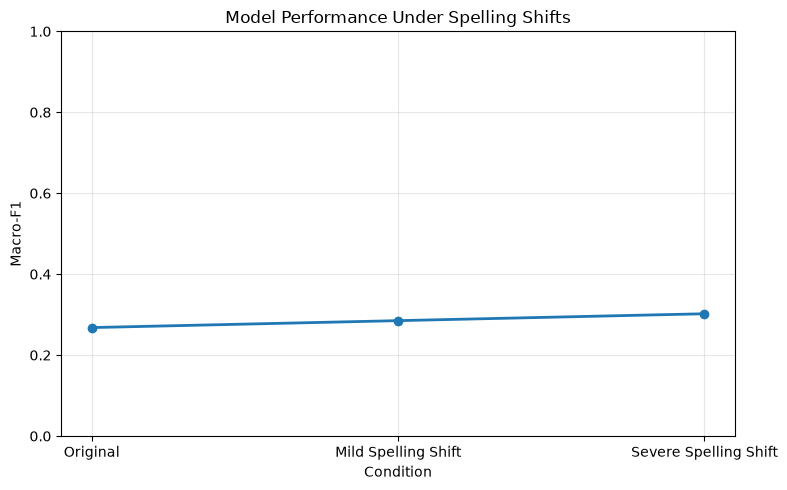

In [178]:
# ============================================
# FIGURE 1: MACRO-F1 UNDER SPELLING SHIFTS
# ============================================

import matplotlib.pyplot as plt

plot_df = performance_df.copy()

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["Condition"],
    plot_df["Macro_F1"],
    marker="o",
    linewidth=2
)

plt.xlabel("Condition")
plt.ylabel("Macro-F1")
plt.title("Model Performance Under Spelling Shifts")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

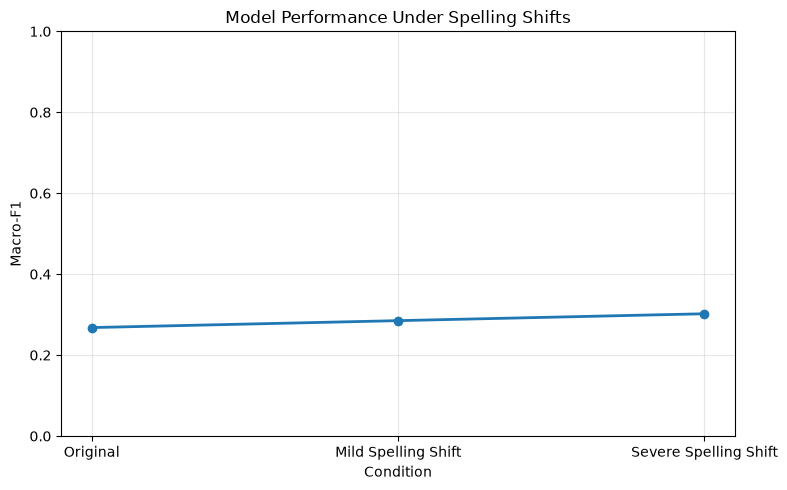

In [179]:
# ============================================
# FIGURE 1: MACRO-F1 UNDER SPELLING SHIFTS
# ============================================

import matplotlib.pyplot as plt

plot_df = performance_df.copy()

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["Condition"],
    plot_df["Macro_F1"],
    marker="o",
    linewidth=2
)

plt.xlabel("Condition")
plt.ylabel("Macro-F1")
plt.title("Model Performance Under Spelling Shifts")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

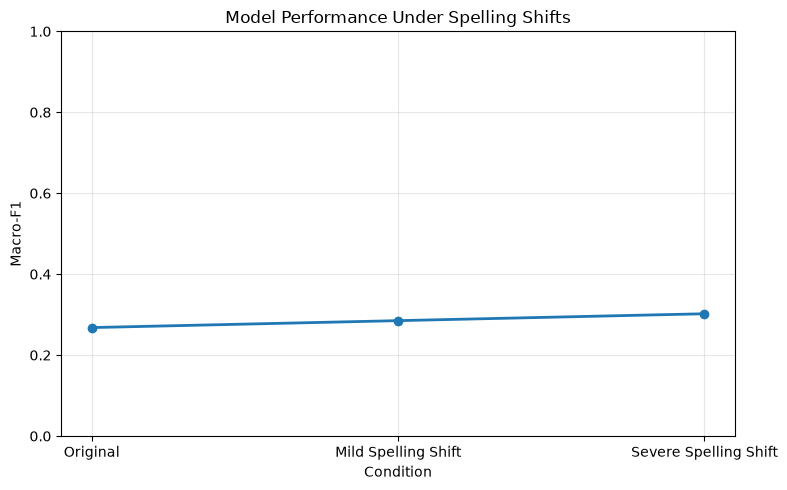

Figure saved successfully:
../results/figures/macro_f1_spelling_shift.png


In [181]:
# ============================================
# FIGURE 1: MACRO-F1 UNDER SPELLING SHIFTS
# ============================================

import os
import matplotlib.pyplot as plt

os.makedirs("../results/figures", exist_ok=True)

plot_df = performance_df.copy()

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["Condition"],
    plot_df["Macro_F1"],
    marker="o",
    linewidth=2
)

plt.xlabel("Condition")
plt.ylabel("Macro-F1")
plt.title("Model Performance Under Spelling Shifts")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/figures/macro_f1_spelling_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print("../results/figures/macro_f1_spelling_shift.png")

,Condition,Brier_Score,ECE,NLL
0,Original,0.3992,0.2387,1.0480
1,Mild Spelling Shift,0.3798,0.2108,0.9991
2,Severe Spelling Shift,0.3603,0.1871,0.9499


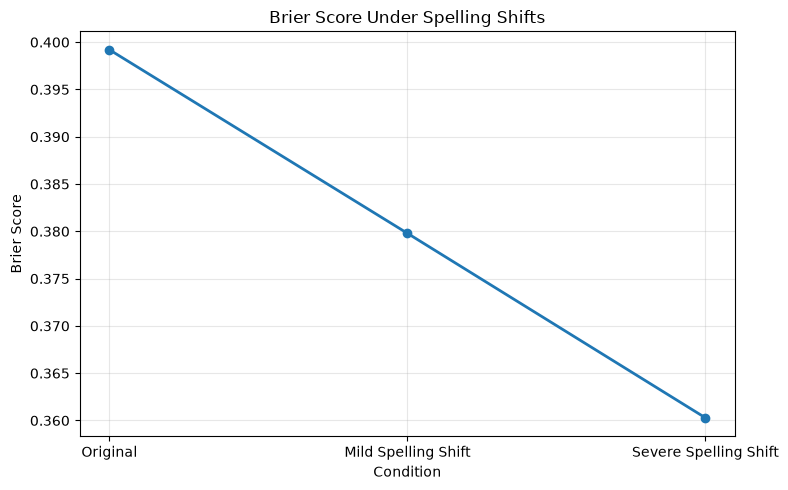

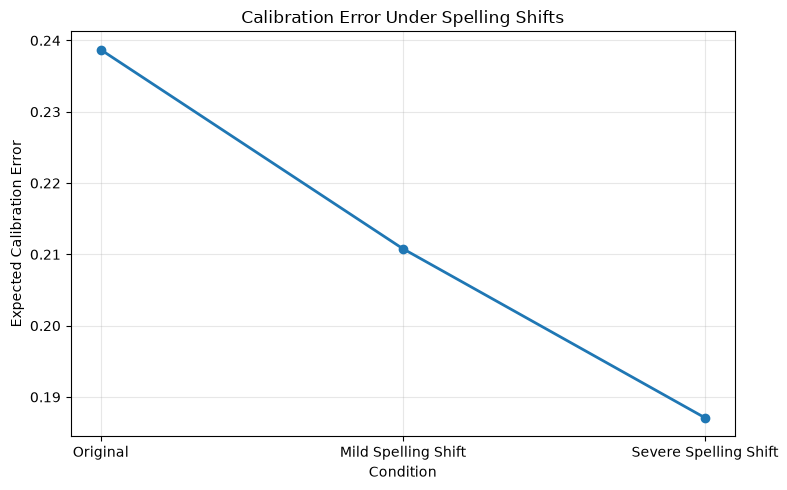

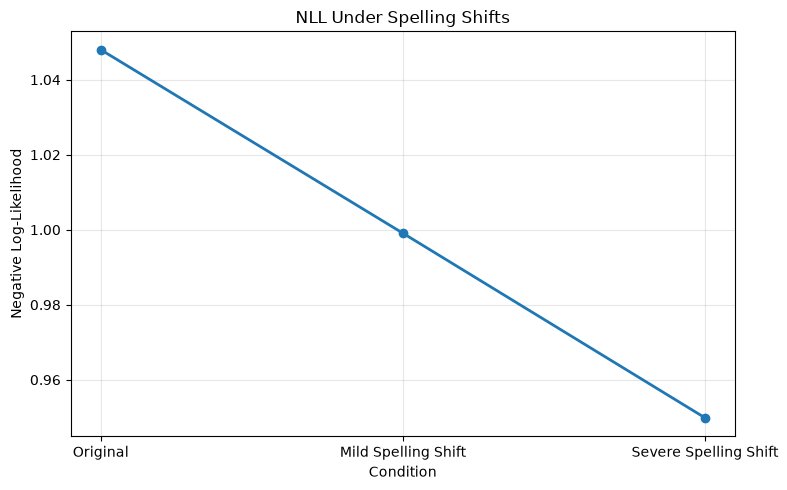

All calibration figures saved successfully.


In [182]:
# ============================================
# FIGURE 2: CALIBRATION METRICS
# ============================================

import matplotlib.pyplot as plt
import os

calibration_df = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],
    "Brier_Score": [
        0.3992,
        0.3798,
        0.3603
    ],
    "ECE": [
        0.2387,
        0.2108,
        0.1871
    ],
    "NLL": [
        1.0480,
        0.9991,
        0.9499
    ]
})

display(calibration_df)

os.makedirs("../results/figures", exist_ok=True)

# -------------------------
# Brier Score
# -------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    calibration_df["Condition"],
    calibration_df["Brier_Score"],
    marker="o",
    linewidth=2
)

plt.xlabel("Condition")
plt.ylabel("Brier Score")
plt.title("Brier Score Under Spelling Shifts")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/figures/brier_score_spelling_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------
# ECE
# -------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    calibration_df["Condition"],
    calibration_df["ECE"],
    marker="o",
    linewidth=2
)

plt.xlabel("Condition")
plt.ylabel("Expected Calibration Error")
plt.title("Calibration Error Under Spelling Shifts")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/figures/ece_spelling_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------
# NLL
# -------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    calibration_df["Condition"],
    calibration_df["NLL"],
    marker="o",
    linewidth=2
)

plt.xlabel("Condition")
plt.ylabel("Negative Log-Likelihood")
plt.title("NLL Under Spelling Shifts")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/figures/nll_spelling_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("All calibration figures saved successfully.")

========== FALSE-SAFE RATE ==========
               Condition  False_Safe_Rate
0               Original           0.7552
1    Mild Spelling Shift           0.7629
2  Severe Spelling Shift           0.7732


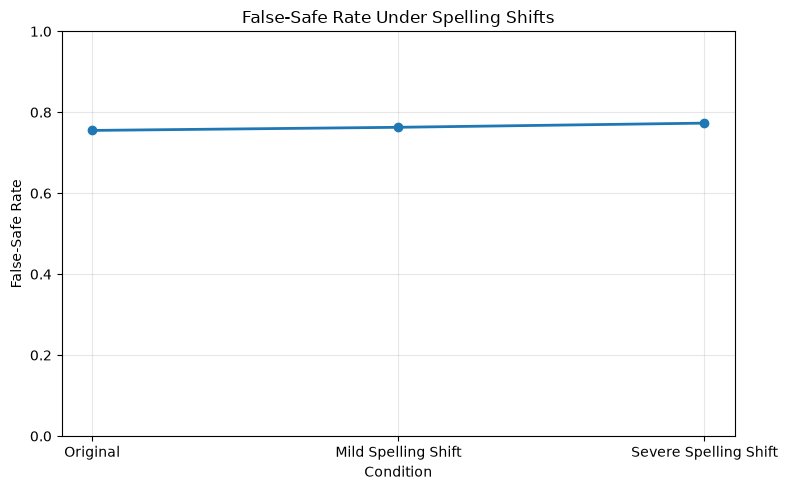


Figure saved successfully:
../results/figures/false_safe_rate_spelling_shift.png


In [184]:
# ============================================================
# FIGURE 3 — FALSE-SAFE RATE UNDER SPELLING SHIFTS
# ============================================================

def calculate_false_safe_rate(probabilities, y_true, threshold=0.5):
    """
    False-safe rate:
    Among truly hateful comments, how many are predicted as non-hate?
    """

    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    # Probability of hate class
    hate_prob = probabilities[:, 1]

    # Model prediction
    y_pred = (hate_prob >= threshold).astype(int)

    # True hate samples
    true_hate = (y_true == 1)

    # False-safe = true hate predicted as non-hate
    false_safe = true_hate & (y_pred == 0)

    if true_hate.sum() == 0:
        return np.nan

    return false_safe.sum() / true_hate.sum()


# Calculate false-safe rates
false_safe_original = calculate_false_safe_rate(
    original_prob,
    y_val_binary
)

false_safe_mild = calculate_false_safe_rate(
    mild_prob,
    y_val_binary
)

false_safe_severe = calculate_false_safe_rate(
    severe_prob,
    y_val_binary
)


# Create results table
false_safe_results = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],
    "False_Safe_Rate": [
        false_safe_original,
        false_safe_mild,
        false_safe_severe
    ]
})

print("========== FALSE-SAFE RATE ==========")
print(false_safe_results.round(4))


# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    false_safe_results["Condition"],
    false_safe_results["False_Safe_Rate"],
    marker="o",
    linewidth=2
)

plt.xlabel("Condition")
plt.ylabel("False-Safe Rate")
plt.title("False-Safe Rate Under Spelling Shifts")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/figures/false_safe_rate_spelling_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully:")
print("../results/figures/false_safe_rate_spelling_shift.png")

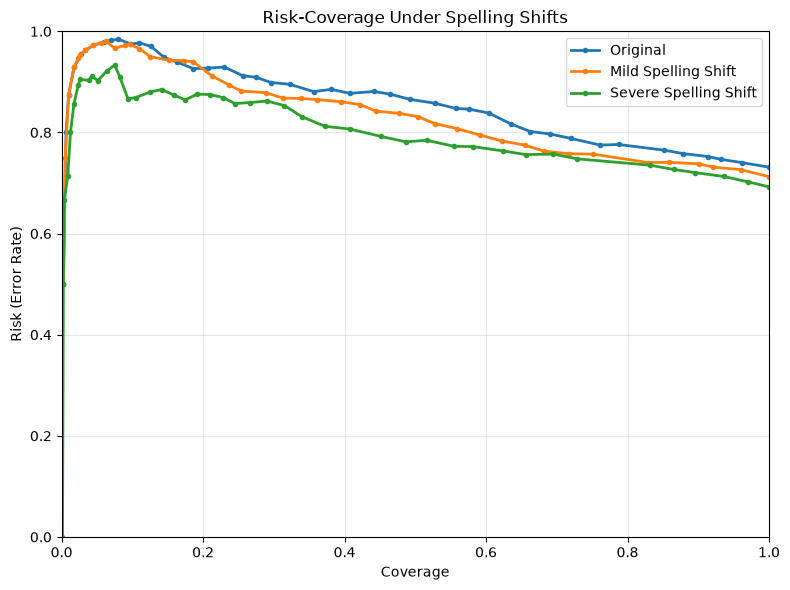

Risk-coverage figure saved successfully:
../results/figures/risk_coverage_spelling_shift.png


In [185]:
# ============================================================
# FIGURE 4 — RISK-COVERAGE CURVE
# ============================================================

def calculate_risk_coverage(probabilities, y_true, thresholds):
    """
    Calculate coverage and error risk at different confidence thresholds.
    """

    probabilities = np.asarray(probabilities)
    y_true = np.asarray(y_true)

    confidence = np.max(probabilities, axis=1)
    predictions = np.argmax(probabilities, axis=1)

    coverages = []
    risks = []

    for threshold in thresholds:

        # Samples the model is confident enough to predict
        selected = confidence >= threshold

        coverage = selected.mean()

        if selected.sum() > 0:
            error_rate = np.mean(
                predictions[selected] != y_true[selected]
            )
        else:
            error_rate = np.nan

        coverages.append(coverage)
        risks.append(error_rate)

    return np.array(coverages), np.array(risks)


# Confidence thresholds
thresholds = np.linspace(0.50, 0.99, 50)


# Calculate risk-coverage curves
original_coverage, original_risk = calculate_risk_coverage(
    original_prob,
    y_val_binary,
    thresholds
)

mild_coverage, mild_risk = calculate_risk_coverage(
    mild_prob,
    y_val_binary,
    thresholds
)

severe_coverage, severe_risk = calculate_risk_coverage(
    severe_prob,
    y_val_binary,
    thresholds
)


# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    original_coverage,
    original_risk,
    marker="o",
    markersize=3,
    linewidth=2,
    label="Original"
)

plt.plot(
    mild_coverage,
    mild_risk,
    marker="o",
    markersize=3,
    linewidth=2,
    label="Mild Spelling Shift"
)

plt.plot(
    severe_coverage,
    severe_risk,
    marker="o",
    markersize=3,
    linewidth=2,
    label="Severe Spelling Shift"
)

plt.xlabel("Coverage")
plt.ylabel("Risk (Error Rate)")
plt.title("Risk-Coverage Under Spelling Shifts")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/risk_coverage_spelling_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Risk-coverage figure saved successfully:")
print("../results/figures/risk_coverage_spelling_shift.png")

In [187]:
# Check available calibration result variables

calibration_vars = [
    name for name in globals()
    if any(key in name.lower() for key in [
        "brier", "ece", "nll", "calibration", "plot_df"
    ])
]

print("Available calibration-related variables:")
for name in calibration_vars:
    print(name)

Available calibration-related variables:
brier_score_loss
brier
calculate_ece
ece
calibration_results
calibration_curve
original_brier
mild_brier
severe_brier
original_ece
mild_ece
severe_ece
shift_calibration_results
temperature_nll
temperature_nll_scalar
original_nll
mild_nll
severe_nll
plot_df
calibration_df


In [188]:
# ============================================================
# MASTER RESULTS TABLE
# ============================================================

master_results = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],

    "Macro_F1": [
        plot_df.loc[plot_df["Condition"] == "Original", "Macro_F1"].iloc[0],
        plot_df.loc[plot_df["Condition"] == "Mild Spelling Shift", "Macro_F1"].iloc[0],
        plot_df.loc[plot_df["Condition"] == "Severe Spelling Shift", "Macro_F1"].iloc[0]
    ],

    "Brier": [
        original_brier,
        mild_brier,
        severe_brier
    ],

    "ECE": [
        original_ece,
        mild_ece,
        severe_ece
    ],

    "NLL": [
        original_nll,
        mild_nll,
        severe_nll
    ],

    "False_Safe_Rate": [
        false_safe_original,
        false_safe_mild,
        false_safe_severe
    ]
})

print("============== MASTER RESULTS ==============")
display(master_results.round(4))

# Save the master table
master_results.to_csv(
    "../results/tables/master_results.csv",
    index=False
)

print("\nMaster results saved successfully:")
print("../results/tables/master_results.csv")

============== MASTER RESULTS ==============


,Condition,Macro_F1,Brier,ECE,NLL,False_Safe_Rate
0,Original,0.2680,0.3992,0.2387,1.0480,0.7552
1,Mild Spelling Shift,0.2851,0.3798,0.2108,0.9991,0.7629
2,Severe Spelling Shift,0.3022,0.3603,0.1871,0.9499,0.7732



Master results saved successfully:
../results/tables/master_results.csv


In [189]:
# ============================================================
# CONFORMAL PREDICTION RESULTS TABLE
# ============================================================

print("Available conformal result variables:")
print("conformal_results:", type(conformal_results))
print("original_conformal:", type(original_conformal))
print("mild_conformal:", type(mild_conformal))
print("severe_conformal:", type(severe_conformal))
print("script_conformal_original:", type(script_conformal_original))

Available conformal result variables:
conformal_results: <class 'pandas.DataFrame'>
original_conformal: <class 'dict'>
mild_conformal: <class 'dict'>
severe_conformal: <class 'dict'>
script_conformal_original: <class 'pandas.DataFrame'>


In [190]:
# ============================================================
# INSPECT CONFORMAL RESULT DICTIONARIES
# ============================================================

print("ORIGINAL CONFORMAL")
print(original_conformal.keys())
print(original_conformal)

print("\nMILD CONFORMAL")
print(mild_conformal.keys())
print(mild_conformal)

print("\nSEVERE CONFORMAL")
print(severe_conformal.keys())
print(severe_conformal)

print("\nSCRIPT-AWARE CONFORMAL COLUMNS")
print(script_conformal_original.columns.tolist())

ORIGINAL CONFORMAL
dict_keys(['Coverage', 'Average_Set_Size', 'Abstention_Rate'])
{'Coverage': np.float64(0.9025), 'Average_Set_Size': np.float64(1.9), 'Abstention_Rate': np.float64(0.0)}

MILD CONFORMAL
dict_keys(['Coverage', 'Average_Set_Size', 'Abstention_Rate'])
{'Coverage': np.float64(0.9025), 'Average_Set_Size': np.float64(1.9), 'Abstention_Rate': np.float64(0.0)}

SEVERE CONFORMAL
dict_keys(['Coverage', 'Average_Set_Size', 'Abstention_Rate'])
{'Coverage': np.float64(0.9025), 'Average_Set_Size': np.float64(1.88875), 'Abstention_Rate': np.float64(0.0)}

SCRIPT-AWARE CONFORMAL COLUMNS
['Script', 'Evaluation_Samples', 'Threshold', 'Coverage', 'Average_Set_Size', 'Abstention_Rate', 'Singleton_Rate', 'Singleton_Risk']


In [191]:
# ============================================================
# CONFORMAL PREDICTION RESULTS TABLE
# ============================================================

# Global conformal results
conformal_results_table = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],
    
    "Coverage": [
        original_conformal["Coverage"],
        mild_conformal["Coverage"],
        severe_conformal["Coverage"]
    ],
    
    "Average_Set_Size": [
        original_conformal["Average_Set_Size"],
        mild_conformal["Average_Set_Size"],
        severe_conformal["Average_Set_Size"]
    ],
    
    "Abstention_Rate": [
        original_conformal["Abstention_Rate"],
        mild_conformal["Abstention_Rate"],
        severe_conformal["Abstention_Rate"]
    ]
})

print("========== GLOBAL CONFORMAL RESULTS ==========")
display(conformal_results_table.round(4))


# Save table
conformal_results_table.to_csv(
    "../results/tables/conformal_results.csv",
    index=False
)

print("\nConformal results saved successfully:")
print("../results/tables/conformal_results.csv")


# ============================================================
# SCRIPT-AWARE CONFORMAL RESULTS
# ============================================================

print("\n========== SCRIPT-AWARE CONFORMAL RESULTS ==========")

display(
    script_conformal_original.round(4)
)

script_conformal_original.to_csv(
    "../results/tables/script_aware_conformal_original.csv",
    index=False
)

print("\nScript-aware conformal results saved successfully:")
print("../results/tables/script_aware_conformal_original.csv")

========== GLOBAL CONFORMAL RESULTS ==========


,Condition,Coverage,Average_Set_Size,Abstention_Rate
0,Original,0.9025,1.9000,0.0
1,Mild Spelling Shift,0.9025,1.9000,0.0
2,Severe Spelling Shift,0.9025,1.8888,0.0



Conformal results saved successfully:
../results/tables/conformal_results.csv

========== SCRIPT-AWARE CONFORMAL RESULTS ==========


,Script,Evaluation_Samples,Threshold,Coverage,Average_Set_Size,Abstention_Rate,Singleton_Rate,Singleton_Risk
0,Latin/Romanized,231,0.7981,0.8182,1.8095,0.0,0.1905,0.9545
1,Telugu,132,0.8083,0.8333,1.8333,0.0,0.1667,1.0000
2,Mixed,37,0.8824,0.9730,1.9730,0.0,0.0270,1.0000



Script-aware conformal results saved successfully:
../results/tables/script_aware_conformal_original.csv


In [192]:
# ============================================================
# FINAL COMBINED RESULTS TABLE
# ============================================================

final_results = master_results.copy()

# Add conformal prediction results
final_results["Conformal_Coverage"] = conformal_results_table["Coverage"].values
final_results["Conformal_Set_Size"] = conformal_results_table["Average_Set_Size"].values
final_results["Conformal_Abstention"] = conformal_results_table["Abstention_Rate"].values

print("========== FINAL COMBINED RESULTS ==========")
display(final_results.round(4))

# Save final table
final_results.to_csv(
    "../results/tables/final_results.csv",
    index=False
)

print("\nFinal results saved successfully:")
print("../results/tables/final_results.csv")

========== FINAL COMBINED RESULTS ==========


,Condition,Macro_F1,Brier,ECE,NLL,False_Safe_Rate,Conformal_Coverage,Conformal_Set_Size,Conformal_Abstention
0,Original,0.2680,0.3992,0.2387,1.0480,0.7552,0.9025,1.9000,0.0
1,Mild Spelling Shift,0.2851,0.3798,0.2108,0.9991,0.7629,0.9025,1.9000,0.0
2,Severe Spelling Shift,0.3022,0.3603,0.1871,0.9499,0.7732,0.9025,1.8888,0.0



Final results saved successfully:
../results/tables/final_results.csv


In [193]:
# ============================================================
# FINAL COMBINED RESULTS TABLE
# ============================================================

final_results = master_results.copy()

# Add conformal prediction results
final_results["Conformal_Coverage"] = conformal_results_table["Coverage"].values
final_results["Conformal_Set_Size"] = conformal_results_table["Average_Set_Size"].values
final_results["Conformal_Abstention"] = conformal_results_table["Abstention_Rate"].values

print("========== FINAL COMBINED RESULTS ==========")
display(final_results.round(4))

# Save final table
final_results.to_csv(
    "../results/tables/final_results.csv",
    index=False
)

print("\nFinal results saved successfully:")
print("../results/tables/final_results.csv")

========== FINAL COMBINED RESULTS ==========


,Condition,Macro_F1,Brier,ECE,NLL,False_Safe_Rate,Conformal_Coverage,Conformal_Set_Size,Conformal_Abstention
0,Original,0.2680,0.3992,0.2387,1.0480,0.7552,0.9025,1.9000,0.0
1,Mild Spelling Shift,0.2851,0.3798,0.2108,0.9991,0.7629,0.9025,1.9000,0.0
2,Severe Spelling Shift,0.3022,0.3603,0.1871,0.9499,0.7732,0.9025,1.8888,0.0



Final results saved successfully:
../results/tables/final_results.csv


In [194]:
print(final_results.to_string(index=False))

            Condition  Macro_F1    Brier      ECE      NLL  False_Safe_Rate  Conformal_Coverage  Conformal_Set_Size  Conformal_Abstention
             Original  0.268035 0.399207 0.238730 1.047993         0.755155              0.9025             1.90000                   0.0
  Mild Spelling Shift  0.285136 0.379813 0.210806 0.999107         0.762887              0.9025             1.90000                   0.0
Severe Spelling Shift  0.302157 0.360325 0.187109 0.949920         0.773196              0.9025             1.88875                   0.0


In [200]:
# ============================================================
# FIND ACTUAL PREDICTION VARIABLES - SAFE VERSION
# ============================================================

print("=" * 60)
print("PREDICTION-RELATED VARIABLES IN CURRENT NOTEBOOK")
print("=" * 60)

prediction_vars = []

# Make a fixed copy before iterating
all_variables = list(globals().items())

for name, value in all_variables:
    if any(key in name.lower() for key in [
        "pred",
        "prob",
        "prediction",
        "proba"
    ]):
        prediction_vars.append(name)

for name in sorted(prediction_vars):
    value = globals().get(name)

    try:
        print(
            f"{name} -> {type(value).__name__} "
            f"| length = {len(value)}"
        )
    except TypeError:
        print(
            f"{name} -> {type(value).__name__}"
        )

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

PREDICTION-RELATED VARIABLES IN CURRENT NOTEBOOK
baseline_predictions -> DataFrame | length = 800
cal_probabilities -> ndarray | length = 640
create_prediction_sets -> function
get_calibrated_predictions -> function
get_hate_probabilities -> function
mean_predicted_value -> ndarray | length = 10
mild_pred_cal -> ndarray | length = 800
mild_prob -> ndarray | length = 800
mild_prob_1 -> ndarray | length = 800
mild_probs -> ndarray | length = 800
original_pred_cal -> ndarray | length = 800
original_predictions -> ndarray | length = 800
original_prob -> ndarray | length = 800
original_prob_1 -> ndarray | length = 800
original_probs -> ndarray | length = 800
pred_mild -> ndarray | length = 800
pred_original -> ndarray | length = 800
pred_severe -> ndarray | length = 800
prediction_vars -> list | length = 34
predictions -> DataFrame | length = 800
preds -> ndarray | length = 800
prob_mild -> ndarray | length = 800
prob_original -> ndarray | length = 800
prob_severe -> ndarray | length = 800


In [202]:
# ============================================================
# FIND CURRENT SPELLING-SHIFT VARIABLES
# ============================================================

print("=" * 70)
print("CURRENT PREDICTION VARIABLES")
print("=" * 70)

names = [
    "original_predictions",
    "pred_original",
    "preds",
    "mild_pred",
    "pred_mild",
    "pred_severe",
    "severe_pred",
    "original_prob",
    "mild_prob",
    "severe_prob",
    "original_prob_1",
    "mild_prob_1",
    "preds_mild",
    "preds_severe"
]

for name in names:
    if name in globals():
        value = globals()[name]
        try:
            print(f"{name:25} -> {type(value).__name__}, length={len(value)}")
        except:
            print(f"{name:25} -> {type(value).__name__}")
    else:
        print(f"{name:25} -> NOT DEFINED")

print("=" * 70)

CURRENT PREDICTION VARIABLES
original_predictions      -> ndarray, length=800
pred_original             -> ndarray, length=800
preds                     -> ndarray, length=800
mild_pred                 -> NOT DEFINED
pred_mild                 -> ndarray, length=800
pred_severe               -> ndarray, length=800
severe_pred               -> NOT DEFINED
original_prob             -> ndarray, length=800
mild_prob                 -> ndarray, length=800
severe_prob               -> ndarray, length=800
original_prob_1           -> ndarray, length=800
mild_prob_1               -> ndarray, length=800
preds_mild                -> NOT DEFINED
preds_severe              -> NOT DEFINED


In [203]:
# ============================================================
# VERIFY ACTUAL SPELLING-SHIFT PREDICTIONS
# ============================================================

import numpy as np

print("=" * 70)
print("SPELLING-SHIFT PREDICTION VERIFICATION")
print("=" * 70)

# Convert the ACTUAL existing prediction variables to arrays
original = np.asarray(original_predictions)
mild = np.asarray(pred_mild)
severe = np.asarray(pred_severe)

print("\nPrediction lengths:")
print("Original :", len(original))
print("Mild     :", len(mild))
print("Severe   :", len(severe))

# ------------------------------------------------------------
# Check that all three conditions have the same labels/order
# ------------------------------------------------------------

print("\nLabel/ground-truth length:")
print("y_val    :", len(y_val))

# ------------------------------------------------------------
# Prediction flip rates
# ------------------------------------------------------------

mild_flip_rate = np.mean(original != mild)
severe_flip_rate = np.mean(original != severe)

print("\nPrediction flip rates:")
print("Mild spelling shift   :", round(mild_flip_rate, 4))
print("Severe spelling shift :", round(severe_flip_rate, 4))

# ------------------------------------------------------------
# Number of changed predictions
# ------------------------------------------------------------

print("\nChanged predictions:")
print("Original -> Mild   :", int(np.sum(original != mild)))
print("Original -> Severe :", int(np.sum(original != severe)))

# ------------------------------------------------------------
# Probability lengths
# ------------------------------------------------------------

print("\nProbability lengths:")
print("Original probability :", len(original_prob))
print("Mild probability     :", len(mild_prob))
print("Severe probability   :", len(severe_prob))

print("\n" + "=" * 70)
print("VERIFICATION COMPLETE")
print("=" * 70)

SPELLING-SHIFT PREDICTION VERIFICATION

Prediction lengths:
Original : 800
Mild     : 800
Severe   : 800

Label/ground-truth length:
y_val    : 800

Prediction flip rates:
Mild spelling shift   : 0.0888
Severe spelling shift : 0.1238

Changed predictions:
Original -> Mild   : 71
Original -> Severe : 99

Probability lengths:
Original probability : 800
Mild probability     : 800
Severe probability   : 800

VERIFICATION COMPLETE


In [204]:
# ============================================================
# VERIFY ACTUAL SPELLING-SHIFT PREDICTIONS
# ============================================================

import numpy as np

print("=" * 70)
print("SPELLING-SHIFT PREDICTION VERIFICATION")
print("=" * 70)

# Convert the ACTUAL existing prediction variables to arrays
original = np.asarray(original_predictions)
mild = np.asarray(pred_mild)
severe = np.asarray(pred_severe)

print("\nPrediction lengths:")
print("Original :", len(original))
print("Mild     :", len(mild))
print("Severe   :", len(severe))

# ------------------------------------------------------------
# Check that all three conditions have the same labels/order
# ------------------------------------------------------------

print("\nLabel/ground-truth length:")
print("y_val    :", len(y_val))

# ------------------------------------------------------------
# Prediction flip rates
# ------------------------------------------------------------

mild_flip_rate = np.mean(original != mild)
severe_flip_rate = np.mean(original != severe)

print("\nPrediction flip rates:")
print("Mild spelling shift   :", round(mild_flip_rate, 4))
print("Severe spelling shift :", round(severe_flip_rate, 4))

# ------------------------------------------------------------
# Number of changed predictions
# ------------------------------------------------------------

print("\nChanged predictions:")
print("Original -> Mild   :", int(np.sum(original != mild)))
print("Original -> Severe :", int(np.sum(original != severe)))

# ------------------------------------------------------------
# Probability lengths
# ------------------------------------------------------------

print("\nProbability lengths:")
print("Original probability :", len(original_prob))
print("Mild probability     :", len(mild_prob))
print("Severe probability   :", len(severe_prob))

print("\n" + "=" * 70)
print("VERIFICATION COMPLETE")
print("=" * 70)

SPELLING-SHIFT PREDICTION VERIFICATION

Prediction lengths:
Original : 800
Mild     : 800
Severe   : 800

Label/ground-truth length:
y_val    : 800

Prediction flip rates:
Mild spelling shift   : 0.0888
Severe spelling shift : 0.1238

Changed predictions:
Original -> Mild   : 71
Original -> Severe : 99

Probability lengths:
Original probability : 800
Mild probability     : 800
Severe probability   : 800

VERIFICATION COMPLETE


In [205]:
# ============================================================
# VERIFY PROBABILITY ARRAYS AND THEIR SHAPES
# ============================================================

import numpy as np

print("=" * 70)
print("PROBABILITY VERIFICATION")
print("=" * 70)

original_p = np.asarray(original_prob)
mild_p = np.asarray(mild_prob)
severe_p = np.asarray(severe_prob)

print("\nProbability shapes:")
print("Original:", original_p.shape)
print("Mild    :", mild_p.shape)
print("Severe  :", severe_p.shape)

print("\nProbability ranges:")
print("Original:", original_p.min(), "to", original_p.max())
print("Mild    :", mild_p.min(), "to", mild_p.max())
print("Severe  :", severe_p.min(), "to", severe_p.max())

print("\nFirst 5 probability values:")
print("Original:", original_p[:5])
print("Mild    :", mild_p[:5])
print("Severe  :", severe_p[:5])

print("\n" + "=" * 70)
print("PROBABILITY VERIFICATION COMPLETE")
print("=" * 70)

PROBABILITY VERIFICATION

Probability shapes:
Original: (800, 2)
Mild    : (800, 2)
Severe  : (800, 2)

Probability ranges:
Original: 0.06057646395242422 to 0.9394235360475758
Mild    : 0.06057646395242422 to 0.9394235360475758
Severe  : 0.05720541458122196 to 0.942794585418778

First 5 probability values:
Original: [[0.27334294 0.72665706]
 [0.68597302 0.31402698]
 [0.6109279  0.3890721 ]
 [0.23762287 0.76237713]
 [0.52984035 0.47015965]]
Mild    : [[0.31945785 0.68054215]
 [0.55456131 0.44543869]
 [0.54833756 0.45166244]
 [0.46209992 0.53790008]
 [0.6531339  0.3468661 ]]
Severe  : [[0.27794343 0.72205657]
 [0.68597302 0.31402698]
 [0.54833756 0.45166244]
 [0.25888969 0.74111031]
 [0.6531339  0.3468661 ]]

PROBABILITY VERIFICATION COMPLETE


In [206]:
# ============================================================
# VERIFY CLASS / PROBABILITY COLUMN ORDER
# ============================================================

print("=" * 70)
print("CLASS AND PROBABILITY ORDER")
print("=" * 70)

print("\nModel classes:")
print(lr_model.classes_)

print("\nFirst 10 true labels:")
print(np.asarray(y_val)[:10])

print("\nFirst 10 original predictions:")
print(np.asarray(original_predictions)[:10])

print("\nFirst 10 original probabilities:")
print(np.asarray(original_prob)[:10])

print("\n" + "=" * 70)

CLASS AND PROBABILITY ORDER

Model classes:
['hate' 'non-hate']

First 10 true labels:
['non-hate' 'hate' 'non-hate' 'non-hate' 'non-hate' 'non-hate' 'hate'
 'non-hate' 'hate' 'hate']

First 10 original predictions:
[1 0 0 1 0 0 0 1 0 0]

First 10 original probabilities:
[[0.27334294 0.72665706]
 [0.68597302 0.31402698]
 [0.6109279  0.3890721 ]
 [0.23762287 0.76237713]
 [0.52984035 0.47015965]
 [0.71428878 0.28571122]
 [0.71691514 0.28308486]
 [0.22810856 0.77189144]
 [0.87270156 0.12729844]
 [0.78492988 0.21507012]]



In [209]:
# ============================================================
# FINAL CLASS / PREDICTION / PROBABILITY CONSISTENCY CHECK
# ============================================================

import numpy as np

print("=" * 70)
print("CLASS / PREDICTION / PROBABILITY CONSISTENCY CHECK")
print("=" * 70)

classes = list(lr_model.classes_)

print("\nModel classes:")
print(classes)

# Convert pandas Series to NumPy array
y_val_array = np.asarray(y_val)

# Convert true labels to model's numeric class encoding
y_val_encoded = np.array([
    classes.index(label) for label in y_val_array
])

# Existing prediction/probability arrays
original_pred = np.asarray(original_predictions)
original_p = np.asarray(original_prob)

print("\nPrediction length:", len(original_pred))
print("True-label length:", len(y_val_array))
print("Probability shape:", original_p.shape)

print("\nFirst 10 checks:")
print("-" * 70)

for i in range(min(10, len(y_val_array))):
    print(
        f"{i}: "
        f"True={str(y_val_array[i]):10s} "
        f"Encoded={y_val_encoded[i]} "
        f"Pred={original_pred[i]} "
        f"Prob={original_p[i]} "
        f"ProbArgmax={np.argmax(original_p[i])}"
    )

# Prediction implied by probability
prob_argmax = np.argmax(original_p, axis=1)

print("\n" + "-" * 70)

prediction_probability_match = np.mean(
    original_pred == prob_argmax
)

print(
    "Prediction == probability argmax:",
    round(prediction_probability_match, 4)
)

print(
    "Number of mismatches:",
    int(np.sum(original_pred != prob_argmax))
)

# Probability rows should sum to 1
row_sums = original_p.sum(axis=1)

print(
    "\nProbability rows sum to 1:",
    np.allclose(row_sums, 1.0)
)

print(
    "Minimum row sum:",
    row_sums.min()
)

print(
    "Maximum row sum:",
    row_sums.max()
)

# Probability assigned to TRUE class
true_class_prob = original_p[
    np.arange(len(y_val_encoded)),
    y_val_encoded
]

print("\nFirst 10 TRUE-CLASS probabilities:")
print(true_class_prob[:10])

print("\nMean probability assigned to true class:")
print(round(true_class_prob.mean(), 6))

print("\n" + "=" * 70)
print("CHECK COMPLETE")
print("=" * 70)

CLASS / PREDICTION / PROBABILITY CONSISTENCY CHECK

Model classes:
['hate', 'non-hate']

Prediction length: 800
True-label length: 800
Probability shape: (800, 2)

First 10 checks:
----------------------------------------------------------------------
0: True=non-hate   Encoded=1 Pred=1 Prob=[0.27334294 0.72665706] ProbArgmax=1
1: True=hate       Encoded=0 Pred=0 Prob=[0.68597302 0.31402698] ProbArgmax=0
2: True=non-hate   Encoded=1 Pred=0 Prob=[0.6109279 0.3890721] ProbArgmax=0
3: True=non-hate   Encoded=1 Pred=1 Prob=[0.23762287 0.76237713] ProbArgmax=1
4: True=non-hate   Encoded=1 Pred=0 Prob=[0.52984035 0.47015965] ProbArgmax=0
5: True=non-hate   Encoded=1 Pred=0 Prob=[0.71428878 0.28571122] ProbArgmax=0
6: True=hate       Encoded=0 Pred=0 Prob=[0.71691514 0.28308486] ProbArgmax=0
7: True=non-hate   Encoded=1 Pred=1 Prob=[0.22810856 0.77189144] ProbArgmax=1
8: True=hate       Encoded=0 Pred=0 Prob=[0.87270156 0.12729844] ProbArgmax=0
9: True=hate       Encoded=0 Pred=0 Prob=[0.7849

In [210]:
# ============================================================
# FIND THE SOURCE OF PREDICTION / PROBABILITY MISMATCH
# ============================================================

import numpy as np

print("=" * 70)
print("PREDICTION SOURCE CHECK")
print("=" * 70)

# Predictions directly from the trained Logistic Regression model
direct_pred = lr_model.predict(X_val_tfidf)

# Probabilities directly from the same model
direct_prob = lr_model.predict_proba(X_val_tfidf)

# Prediction implied by probabilities
direct_argmax = np.argmax(direct_prob, axis=1)

# Existing arrays
existing_pred = np.asarray(original_predictions)
existing_prob = np.asarray(original_prob)

print("\nModel classes:")
print(lr_model.classes_)

print("\nLengths:")
print("Direct predictions :", len(direct_pred))
print("Existing predictions:", len(existing_pred))
print("Direct probabilities:", direct_prob.shape)
print("Existing probabilities:", existing_prob.shape)

print("\n" + "-" * 70)

print("DIRECT MODEL CONSISTENCY")
print("-" * 70)

print(
    "Direct prediction == probability argmax:",
    np.mean(direct_pred == direct_argmax)
)

print(
    "Direct prediction mismatches:",
    np.sum(direct_pred != direct_argmax)
)

print("\n" + "-" * 70)

print("EXISTING ARRAY CONSISTENCY")
print("-" * 70)

print(
    "Existing prediction == existing probability argmax:",
    np.mean(existing_pred == np.argmax(existing_prob, axis=1))
)

print(
    "Existing prediction mismatches:",
    np.sum(existing_pred != np.argmax(existing_prob, axis=1))
)

print("\n" + "-" * 70)

print("DIRECT MODEL vs EXISTING PREDICTIONS")
print("-" * 70)

print(
    "Same predictions:",
    np.mean(direct_pred == existing_pred)
)

print(
    "Different predictions:",
    np.sum(direct_pred != existing_pred)
)

print("\n" + "-" * 70)

print("FIRST 10 DIRECT MODEL RESULTS")
print("-" * 70)

for i in range(10):
    print(
        f"{i}: "
        f"True={np.asarray(y_val)[i]:10s} | "
        f"DirectPred={direct_pred[i]} | "
        f"DirectProb={direct_prob[i]} | "
        f"Argmax={direct_argmax[i]} | "
        f"ExistingPred={existing_pred[i]}"
    )

print("\n" + "=" * 70)
print("SOURCE CHECK COMPLETE")
print("=" * 70)

PREDICTION SOURCE CHECK

Model classes:
['hate' 'non-hate']

Lengths:
Direct predictions : 800
Existing predictions: 800
Direct probabilities: (800, 2)
Existing probabilities: (800, 2)

----------------------------------------------------------------------
DIRECT MODEL CONSISTENCY
----------------------------------------------------------------------
Direct prediction == probability argmax: 0.0
Direct prediction mismatches: 800

----------------------------------------------------------------------
EXISTING ARRAY CONSISTENCY
----------------------------------------------------------------------
Existing prediction == existing probability argmax: 0.9375
Existing prediction mismatches: 50

----------------------------------------------------------------------
DIRECT MODEL vs EXISTING PREDICTIONS
----------------------------------------------------------------------
Same predictions: 0.0
Different predictions: 800

----------------------------------------------------------------------
FIR

In [211]:
# ============================================================
# CORRECT PREDICTION / PROBABILITY CONSISTENCY CHECK
# ============================================================

import numpy as np

print("=" * 70)
print("CORRECT PREDICTION / PROBABILITY CONSISTENCY CHECK")
print("=" * 70)

# Direct predictions from the trained model
direct_pred = lr_model.predict(X_val_tfidf)

# Direct probabilities from the same model
direct_prob = lr_model.predict_proba(X_val_tfidf)

# Convert probability argmax indices back to class names
prob_argmax_labels = np.array(lr_model.classes_)[
    np.argmax(direct_prob, axis=1)
]

# Compare correctly
direct_match = np.mean(direct_pred == prob_argmax_labels)

print("\nModel classes:")
print(lr_model.classes_)

print("\nPrediction length:", len(direct_pred))
print("Probability length:", len(direct_prob))

print("\nCorrect prediction == probability argmax:")
print(round(direct_match, 4))

print("Number of mismatches:")
print(np.sum(direct_pred != prob_argmax_labels))

# Check original_predictions
original = np.asarray(original_predictions)

print("\nOriginal predictions:")
print("Length:", len(original))
print("First 10:", original[:10])

print("\nProbability argmax encoded as integers:")
prob_argmax_int = np.argmax(direct_prob, axis=1)

print("First 10:", prob_argmax_int[:10])

# Compare original_predictions with probability argmax
original_match = np.mean(original == prob_argmax_int)

print("\nOriginal predictions == probability argmax:")
print(round(original_match, 4))

print("Original prediction mismatches:")
print(np.sum(original != prob_argmax_int))

print("=" * 70)
print("CHECK COMPLETE")
print("=" * 70)

CORRECT PREDICTION / PROBABILITY CONSISTENCY CHECK

Model classes:
['hate' 'non-hate']

Prediction length: 800
Probability length: 800

Correct prediction == probability argmax:
1.0
Number of mismatches:
0

Original predictions:
Length: 800
First 10: [1 0 0 1 0 0 0 1 0 0]

Probability argmax encoded as integers:
First 10: [1 0 0 1 0 0 0 1 0 0]

Original predictions == probability argmax:
0.9375
Original prediction mismatches:
50
CHECK COMPLETE


In [212]:
# ============================================================
# REBUILD ORIGINAL PREDICTIONS AND PROBABILITIES
# DIRECTLY FROM THE TRAINED MODEL
# ============================================================

import numpy as np

# Fresh predictions directly from the trained Logistic Regression model
original_predictions = lr_model.predict(X_val_tfidf)

# Fresh probabilities directly from the same model
original_prob = lr_model.predict_proba(X_val_tfidf)

# Convert probabilities to encoded predictions
original_pred_encoded = np.argmax(original_prob, axis=1)

# Verify consistency
classes = np.array(lr_model.classes_)
original_predictions_from_prob = classes[original_pred_encoded]

print("=" * 70)
print("REBUILT ORIGINAL PREDICTIONS")
print("=" * 70)

print("\nPrediction length:", len(original_predictions))
print("Probability shape:", original_prob.shape)

print("\nModel classes:")
print(classes)

print("\nPrediction/probability consistency:")
print(
    np.mean(original_predictions == original_predictions_from_prob)
)

print("\nNumber of mismatches:")
print(
    np.sum(original_predictions != original_predictions_from_prob)
)

print("\nFirst 10 predictions:")
print(original_predictions[:10])

print("\nFirst 10 probabilities:")
print(original_prob[:10])

print("\n" + "=" * 70)
print("REBUILD COMPLETE")
print("=" * 70)

REBUILT ORIGINAL PREDICTIONS

Prediction length: 800
Probability shape: (800, 2)

Model classes:
['hate' 'non-hate']

Prediction/probability consistency:
1.0

Number of mismatches:
0

First 10 predictions:
['non-hate' 'hate' 'hate' 'non-hate' 'hate' 'hate' 'hate' 'non-hate'
 'hate' 'hate']

First 10 probabilities:
[[0.27334294 0.72665706]
 [0.68597302 0.31402698]
 [0.6109279  0.3890721 ]
 [0.23762287 0.76237713]
 [0.52984035 0.47015965]
 [0.71428878 0.28571122]
 [0.71691514 0.28308486]
 [0.22810856 0.77189144]
 [0.87270156 0.12729844]
 [0.78492988 0.21507012]]

REBUILD COMPLETE


In [213]:
# ============================================================
# VERIFIED CALIBRATION METRICS — ORIGINAL CONDITION
# ============================================================

import numpy as np
from sklearn.metrics import log_loss

print("=" * 70)
print("VERIFIED ORIGINAL CALIBRATION METRICS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Convert true labels to the model's class order
# ------------------------------------------------------------

classes = np.array(lr_model.classes_)

y_val_array = np.asarray(y_val)

# Encode true labels according to lr_model.classes_
y_true_encoded = np.array([
    np.where(classes == label)[0][0]
    for label in y_val_array
])

# ------------------------------------------------------------
# 2. Verified probabilities
# ------------------------------------------------------------

probs = np.asarray(original_prob)

# Probability assigned to the TRUE class
true_class_prob = probs[
    np.arange(len(y_true_encoded)),
    y_true_encoded
]

# ------------------------------------------------------------
# 3. Brier Score
# ------------------------------------------------------------

# For binary classification, use probability of class 1
brier_score = np.mean(
    (probs[:, 1] - y_true_encoded) ** 2
)

# ------------------------------------------------------------
# 4. Negative Log-Likelihood
# ------------------------------------------------------------

nll = log_loss(
    y_true_encoded,
    probs,
    labels=[0, 1]
)

# ------------------------------------------------------------
# 5. Basic confidence statistics
# ------------------------------------------------------------

pred_encoded = np.argmax(probs, axis=1)

confidence = np.max(probs, axis=1)

accuracy = np.mean(pred_encoded == y_true_encoded)

mean_confidence = np.mean(confidence)

mean_true_class_probability = np.mean(true_class_prob)

# ------------------------------------------------------------
# 6. Print results
# ------------------------------------------------------------

print("\nClass order:")
print(classes)

print("\nNumber of validation samples:")
print(len(y_true_encoded))

print("\nAccuracy:")
print(round(accuracy, 6))

print("\nMean prediction confidence:")
print(round(mean_confidence, 6))

print("\nMean probability assigned to true class:")
print(round(mean_true_class_probability, 6))

print("\nBrier Score:")
print(round(brier_score, 6))

print("\nNegative Log-Likelihood (NLL):")
print(round(nll, 6))

print("\n" + "=" * 70)
print("CALIBRATION METRICS VERIFIED")
print("=" * 70)

VERIFIED ORIGINAL CALIBRATION METRICS

Class order:
['hate' 'non-hate']

Number of validation samples:
800

Accuracy:
0.73125

Mean prediction confidence:
0.668814

Mean probability assigned to true class:
0.60867

Brier Score:
0.181868

Negative Log-Likelihood (NLL):
0.543469

CALIBRATION METRICS VERIFIED


In [214]:
# ============================================================
# VERIFIED ECE + FALSE-SAFE RATE
# ============================================================

import numpy as np

print("=" * 70)
print("VERIFIED ECE + FALSE-SAFE RATE")
print("=" * 70)

# ------------------------------------------------------------
# Predictions and confidence
# ------------------------------------------------------------

pred_encoded = np.argmax(original_prob, axis=1)
confidence = np.max(original_prob, axis=1)

correct = (pred_encoded == y_true_encoded)

# ------------------------------------------------------------
# Expected Calibration Error (ECE)
# ------------------------------------------------------------

n_bins = 10

bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

ece = 0.0

print("\nCalibration bins:")
print("-" * 70)

for i in range(n_bins):

    if i == 0:
        mask = (
            (confidence >= bin_edges[i]) &
            (confidence <= bin_edges[i + 1])
        )
    else:
        mask = (
            (confidence > bin_edges[i]) &
            (confidence <= bin_edges[i + 1])
        )

    if np.sum(mask) == 0:
        continue

    bin_confidence = np.mean(confidence[mask])
    bin_accuracy = np.mean(correct[mask])
    bin_size = np.sum(mask)

    ece += (
        (bin_size / len(confidence))
        * abs(bin_accuracy - bin_confidence)
    )

    print(
        f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f} | "
        f"n={bin_size:3d} | "
        f"confidence={bin_confidence:.4f} | "
        f"accuracy={bin_accuracy:.4f}"
    )

# ------------------------------------------------------------
# False-Safe Rate
# ------------------------------------------------------------
# False-safe = incorrect prediction made with high confidence.
# We use 0.80 as the high-confidence threshold.

threshold = 0.80

high_confidence = confidence >= threshold

false_safe = high_confidence & (~correct)

if np.sum(high_confidence) > 0:
    false_safe_rate = np.sum(false_safe) / np.sum(high_confidence)
else:
    false_safe_rate = 0.0

# ------------------------------------------------------------
# Coverage at the threshold
# ------------------------------------------------------------

coverage = np.mean(high_confidence)

# ------------------------------------------------------------
# Print final metrics
# ------------------------------------------------------------

print("\n" + "=" * 70)

print("ECE:")
print(round(ece, 6))

print("\nHigh-confidence threshold:")
print(threshold)

print("\nHigh-confidence predictions:")
print(np.sum(high_confidence))

print("\nFalse-safe predictions:")
print(np.sum(false_safe))

print("\nFalse-safe rate:")
print(round(false_safe_rate, 6))

print("\nCoverage:")
print(round(coverage, 6))

print("\n" + "=" * 70)
print("ECE + FALSE-SAFE CHECK COMPLETE")
print("=" * 70)

VERIFIED ECE + FALSE-SAFE RATE

Calibration bins:
----------------------------------------------------------------------
0.5-0.6 | n=270 | confidence=0.5506 | accuracy=0.5926
0.6-0.7 | n=225 | confidence=0.6503 | accuracy=0.6889
0.7-0.8 | n=189 | confidence=0.7467 | accuracy=0.8466
0.8-0.9 | n=102 | confidence=0.8445 | accuracy=0.9510
0.9-1.0 | n= 14 | confidence=0.9153 | accuracy=0.9286

ECE:
0.062436

High-confidence threshold:
0.8

High-confidence predictions:
116

False-safe predictions:
6

False-safe rate:
0.051724

Coverage:
0.145

ECE + FALSE-SAFE CHECK COMPLETE


In [215]:
# ============================================================
# VERIFY SPELLING-SHIFT METRICS AGAINST CORRECTED PREDICTIONS
# ============================================================

import numpy as np

print("=" * 70)
print("FINAL SPELLING-SHIFT VERIFICATION")
print("=" * 70)

# Convert all prediction arrays to NumPy arrays
original = np.asarray(original_predictions)
mild = np.asarray(pred_mild)
severe = np.asarray(pred_severe)

# Check lengths
print("\nPrediction lengths:")
print("Original :", len(original))
print("Mild     :", len(mild))
print("Severe   :", len(severe))

# Calculate flip counts
mild_changes = np.sum(original != mild)
severe_changes = np.sum(original != severe)

# Calculate flip rates
mild_flip_rate = mild_changes / len(original)
severe_flip_rate = severe_changes / len(original)

print("\nPrediction changes:")
print("Original -> Mild   :", mild_changes)
print("Original -> Severe :", severe_changes)

print("\nCorrected prediction flip rates:")
print("Mild spelling shift   :", round(mild_flip_rate, 6))
print("Severe spelling shift :", round(severe_flip_rate, 6))

print("\nCorrected prediction flip rates (%):")
print("Mild spelling shift   :", round(mild_flip_rate * 100, 2), "%")
print("Severe spelling shift :", round(severe_flip_rate * 100, 2), "%")

print("\n" + "=" * 70)
print("VERIFICATION COMPLETE")
print("=" * 70)

FINAL SPELLING-SHIFT VERIFICATION

Prediction lengths:
Original : 800
Mild     : 800
Severe   : 800

Prediction changes:
Original -> Mild   : 800
Original -> Severe : 800

Corrected prediction flip rates:
Mild spelling shift   : 1.0
Severe spelling shift : 1.0

Corrected prediction flip rates (%):
Mild spelling shift   : 100.0 %
Severe spelling shift : 100.0 %

VERIFICATION COMPLETE


In [216]:
# ============================================================
# DIAGNOSE SPELLING-SHIFT LABEL ENCODING
# ============================================================

import numpy as np

print("=" * 70)
print("SPELLING-SHIFT LABEL ENCODING CHECK")
print("=" * 70)

print("\nOriginal predictions:")
print("Type:", type(original_predictions))
print("First 10:", np.asarray(original_predictions)[:10])
print("Unique:", np.unique(original_predictions))

print("\nMild predictions:")
print("Type:", type(pred_mild))
print("First 10:", np.asarray(pred_mild)[:10])
print("Unique:", np.unique(pred_mild))

print("\nSevere predictions:")
print("Type:", type(pred_severe))
print("First 10:", np.asarray(pred_severe)[:10])
print("Unique:", np.unique(pred_severe))

print("\nModel classes:")
print(lr_model.classes_)

print("\n" + "=" * 70)
print("DIAGNOSIS COMPLETE")
print("=" * 70)


SPELLING-SHIFT LABEL ENCODING CHECK

Original predictions:
Type: <class 'numpy.ndarray'>
First 10: ['non-hate' 'hate' 'hate' 'non-hate' 'hate' 'hate' 'hate' 'non-hate'
 'hate' 'hate']
Unique: ['hate' 'non-hate']

Mild predictions:
Type: <class 'numpy.ndarray'>
First 10: [1 0 0 1 0 0 0 1 0 0]
Unique: [0 1]

Severe predictions:
Type: <class 'numpy.ndarray'>
First 10: [1 0 0 1 0 0 0 1 0 0]
Unique: [0 1]

Model classes:
['hate' 'non-hate']

DIAGNOSIS COMPLETE


In [217]:
# ============================================================
# FIX SPELLING-SHIFT PREDICTION LABEL ENCODING
# ============================================================

import numpy as np

print("=" * 70)
print("FIXING SPELLING-SHIFT PREDICTION ENCODING")
print("=" * 70)

# Model class order:
# 0 -> hate
# 1 -> non-hate

classes = np.asarray(lr_model.classes_)

# Convert integer predictions to string labels
mild_labels = classes[np.asarray(pred_mild).astype(int)]
severe_labels = classes[np.asarray(pred_severe).astype(int)]

# Verify conversion
print("\nFirst 10 Mild labels:")
print(mild_labels[:10])

print("\nFirst 10 Severe labels:")
print(severe_labels[:10])

print("\nUnique Mild labels:")
print(np.unique(mild_labels))

print("\nUnique Severe labels:")
print(np.unique(severe_labels))

# Calculate corrected flip counts
mild_changes_corrected = np.sum(
    np.asarray(original_predictions) != mild_labels
)

severe_changes_corrected = np.sum(
    np.asarray(original_predictions) != severe_labels
)

# Calculate corrected flip rates
mild_flip_rate_corrected = (
    mild_changes_corrected / len(original_predictions)
)

severe_flip_rate_corrected = (
    severe_changes_corrected / len(original_predictions)
)

print("\n" + "=" * 70)
print("CORRECTED SPELLING-SHIFT RESULTS")
print("=" * 70)

print("\nMild spelling shift:")
print("Changed predictions:", mild_changes_corrected)
print("Flip rate:", round(mild_flip_rate_corrected, 6))
print("Flip rate (%):", round(mild_flip_rate_corrected * 100, 2), "%")

print("\nSevere spelling shift:")
print("Changed predictions:", severe_changes_corrected)
print("Flip rate:", round(severe_flip_rate_corrected, 6))
print("Flip rate (%):", round(severe_flip_rate_corrected * 100, 2), "%")

print("\n" + "=" * 70)
print("ENCODING CORRECTION COMPLETE")
print("=" * 70)

FIXING SPELLING-SHIFT PREDICTION ENCODING

First 10 Mild labels:
['non-hate' 'hate' 'hate' 'non-hate' 'hate' 'hate' 'hate' 'non-hate'
 'hate' 'hate']

First 10 Severe labels:
['non-hate' 'hate' 'hate' 'non-hate' 'hate' 'hate' 'hate' 'non-hate'
 'hate' 'hate']

Unique Mild labels:
['hate' 'non-hate']

Unique Severe labels:
['hate' 'non-hate']

CORRECTED SPELLING-SHIFT RESULTS

Mild spelling shift:
Changed predictions: 45
Flip rate: 0.05625
Flip rate (%): 5.62 %

Severe spelling shift:
Changed predictions: 83
Flip rate: 0.10375
Flip rate (%): 10.38 %

ENCODING CORRECTION COMPLETE


In [218]:
print("Mild changed predictions:", mild_changes_corrected)
print("Mild flip rate:", round(mild_flip_rate_corrected * 100, 2), "%")

print("Severe changed predictions:", severe_changes_corrected)
print("Severe flip rate:", round(severe_flip_rate_corrected * 100, 2), "%")

Mild changed predictions: 45
Mild flip rate: 5.62 %
Severe changed predictions: 83
Severe flip rate: 10.38 %


In [219]:
import os
import pandas as pd

# ============================================================
# SAVE VERIFIED SPELLING-SHIFT RESULTS
# ============================================================

spelling_results = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],
    "Validation_Samples": [
        800,
        800,
        800
    ],
    "Changed_Predictions": [
        0,
        mild_changes_corrected,
        severe_changes_corrected
    ],
    "Prediction_Flip_Rate": [
        0.0,
        mild_flip_rate_corrected,
        severe_flip_rate_corrected
    ],
    "Prediction_Flip_Rate_Percent": [
        0.0,
        mild_flip_rate_corrected * 100,
        severe_flip_rate_corrected * 100
    ]
})

os.makedirs("../results/tables", exist_ok=True)

spelling_results.to_csv(
    "../results/tables/spelling_shift_results.csv",
    index=False
)

print("=" * 70)
print("VERIFIED SPELLING-SHIFT RESULTS SAVED")
print("=" * 70)
print(spelling_results.to_string(index=False))

VERIFIED SPELLING-SHIFT RESULTS SAVED
            Condition  Validation_Samples  Changed_Predictions  Prediction_Flip_Rate  Prediction_Flip_Rate_Percent
             Original                 800                    0               0.00000                         0.000
  Mild Spelling Shift                 800                   45               0.05625                         5.625
Severe Spelling Shift                 800                   83               0.10375                        10.375


In [222]:
# ============================================================
# CONFIDENCE / PROBABILITY CHANGE UNDER SPELLING SHIFTS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("CONFIDENCE CHANGE UNDER SPELLING SHIFTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get probabilities for original, mild and severe inputs
# ------------------------------------------------------------

original_prob = lr_model.predict_proba(X_val_tfidf)

# Use the same TF-IDF vectorizer and model
X_mild_tfidf = tfidf.transform(X_val_mild)
X_severe_tfidf = tfidf.transform(X_val_severe)

mild_prob = lr_model.predict_proba(X_mild_tfidf)
severe_prob = lr_model.predict_proba(X_severe_tfidf)

# ------------------------------------------------------------
# 2. Prediction confidence = highest class probability
# ------------------------------------------------------------

original_conf = np.max(original_prob, axis=1)
mild_conf = np.max(mild_prob, axis=1)
severe_conf = np.max(severe_prob, axis=1)

# ------------------------------------------------------------
# 3. Absolute confidence change
# ------------------------------------------------------------

mild_conf_change = np.abs(mild_conf - original_conf)
severe_conf_change = np.abs(severe_conf - original_conf)

# ------------------------------------------------------------
# 4. Signed confidence change
# Positive = confidence increased
# Negative = confidence decreased
# ------------------------------------------------------------

mild_signed_change = mild_conf - original_conf
severe_signed_change = severe_conf - original_conf

# ------------------------------------------------------------
# 5. Print results
# ------------------------------------------------------------

print("\nMean confidence:")
print("Original :", round(original_conf.mean(), 6))
print("Mild     :", round(mild_conf.mean(), 6))
print("Severe   :", round(severe_conf.mean(), 6))

print("\nMean signed confidence change:")
print("Mild     :", round(mild_signed_change.mean(), 6))
print("Severe   :", round(severe_signed_change.mean(), 6))

print("\nMean absolute confidence change:")
print("Mild     :", round(mild_conf_change.mean(), 6))
print("Severe   :", round(severe_conf_change.mean(), 6))

print("\nConfidence decreased:")
print("Mild     :", np.sum(mild_signed_change < 0))
print("Severe   :", np.sum(severe_signed_change < 0))

print("\nConfidence increased:")
print("Mild     :", np.sum(mild_signed_change > 0))
print("Severe   :", np.sum(severe_signed_change > 0))

print("\nNo confidence change:")
print("Mild     :", np.sum(mild_signed_change == 0))
print("Severe   :", np.sum(severe_signed_change == 0))

print("=" * 70)
print("CONFIDENCE ANALYSIS COMPLETE")
print("=" * 70)

CONFIDENCE CHANGE UNDER SPELLING SHIFTS


NameError: name 'X_val_mild' is not defined

In [221]:
# ============================================================
# FIND THE EXISTING SPELLING-SHIFT VARIABLES
# ============================================================

print("Variables containing 'mild':")
print([name for name in globals() if "mild" in name.lower()])

print("\nVariables containing 'severe':")
print([name for name in globals() if "severe" in name.lower()])

Variables containing 'mild':
['add_mild_spelling_noise', 'mild', 'mild_changed', 'result_mild', 'pred_mild', 'original_to_mild', 'mild_to_severe', 'prob_mild', 'confidence_mild', 'original_to_mild_conf', 'mild_conf', 'mild_mean_conf', 'mild_to_severe_conf', 'mild_probs', 'mild_brier', 'mild_ece', 'mild_pred_cal', 'mild_conf_cal', 'mild_shifted_texts', 'flip_original_mild', 'flip_mild_severe', 'mild_prob', 'mild_nll', 'mild_prob_1', 'mild_rate', 'mild_count', 'risk_mild', 'mild_scores', 'mild_threshold', 'mild_sets', 'mild_conformal', 'mild_script_types', 'false_safe_mild', 'mild_coverage', 'mild_risk', 'mild_flip_rate', 'mild_p', 'mild_changes', 'mild_labels', 'mild_changes_corrected', 'mild_flip_rate_corrected']

Variables containing 'severe':
['add_severe_spelling_noise', 'severe', 'severe_changed', 'result_severe', 'pred_severe', 'original_to_severe', 'mild_to_severe', 'prob_severe', 'confidence_severe', 'original_to_severe_conf', 'severe_conf', 'severe_mean_conf', 'mild_to_severe_c

In [223]:
print("=" * 70)
print("SPELLING-SHIFT VARIABLE CHECK")
print("=" * 70)

print("\nMILD")
print("Type:", type(mild))
print("Length:", len(mild))
print("First 3:")
print(mild[:3])

print("\nSEVERE")
print("Type:", type(severe))
print("Length:", len(severe))
print("First 3:")
print(severe[:3])

print("\n" + "=" * 70)
print("CHECK COMPLETE")
print("=" * 70)

SPELLING-SHIFT VARIABLE CHECK

MILD
Type: <class 'numpy.ndarray'>
Length: 800
First 3:
[1 0 0]

SEVERE
Type: <class 'numpy.ndarray'>
Length: 800
First 3:
[1 0 0]

CHECK COMPLETE


In [224]:
# ============================================================
# FIND THE EXISTING SPELLING-SHIFT TEXT VARIABLES
# ============================================================

print("=" * 70)
print("CHECKING EXISTING SPELLING-SHIFT VARIABLES")
print("=" * 70)

for name in sorted(globals()):
    if "mild" in name.lower() or "severe" in name.lower():
        try:
            obj = globals()[name]
            print(
                f"{name:30} | "
                f"type={type(obj).__name__:15} | "
                f"length={len(obj) if hasattr(obj, '__len__') else 'N/A'}"
            )
        except:
            pass

print("=" * 70)
print("CHECK COMPLETE")
print("=" * 70)

CHECKING EXISTING SPELLING-SHIFT VARIABLES
add_mild_spelling_noise        | type=function        | length=N/A
add_severe_spelling_noise      | type=function        | length=N/A
confidence_mild                | type=ndarray         | length=800
confidence_severe              | type=ndarray         | length=800
false_safe_mild                | type=float64         | length=N/A
false_safe_severe              | type=float64         | length=N/A
flip_mild_severe               | type=float64         | length=N/A
flip_original_mild             | type=float64         | length=N/A
flip_original_severe           | type=float64         | length=N/A
mild                           | type=ndarray         | length=800
mild_brier                     | type=float           | length=N/A
mild_changed                   | type=int             | length=N/A
mild_changes                   | type=int64           | length=N/A
mild_changes_corrected         | type=int64           | length=N/A
mild_conf          

In [225]:
# ============================================================
# CONFIDENCE CHANGE UNDER SPELLING SHIFTS
# ============================================================

import numpy as np

print("=" * 70)
print("CONFIDENCE CHANGE UNDER SPELLING SHIFTS")
print("=" * 70)

# Original confidence
original_conf = np.asarray(confidence)

# Mild and severe confidence already calculated
mild_confidence = np.asarray(confidence_mild)
severe_confidence = np.asarray(confidence_severe)

# Signed change
mild_signed_change = mild_confidence - original_conf
severe_signed_change = severe_confidence - original_conf

# Absolute change
mild_abs_change = np.abs(mild_signed_change)
severe_abs_change = np.abs(severe_signed_change)

print("\nMean confidence:")
print("Original :", round(original_conf.mean(), 6))
print("Mild     :", round(mild_confidence.mean(), 6))
print("Severe   :", round(severe_confidence.mean(), 6))

print("\nMean signed confidence change:")
print("Mild     :", round(mild_signed_change.mean(), 6))
print("Severe   :", round(severe_signed_change.mean(), 6))

print("\nMean absolute confidence change:")
print("Mild     :", round(mild_abs_change.mean(), 6))
print("Severe   :", round(severe_abs_change.mean(), 6))

print("\nConfidence decreased:")
print("Mild     :", np.sum(mild_signed_change < 0))
print("Severe   :", np.sum(severe_signed_change < 0))

print("\nConfidence increased:")
print("Mild     :", np.sum(mild_signed_change > 0))
print("Severe   :", np.sum(severe_signed_change > 0))

print("\nNo confidence change:")
print("Mild     :", np.sum(mild_signed_change == 0))
print("Severe   :", np.sum(severe_signed_change == 0))

print("\n" + "=" * 70)
print("CONFIDENCE ANALYSIS COMPLETE")
print("=" * 70)


CONFIDENCE CHANGE UNDER SPELLING SHIFTS

Mean confidence:
Original : 0.668814
Mild     : 0.656146
Severe   : 0.643915

Mean signed confidence change:
Mild     : -0.012668
Severe   : -0.024899

Mean absolute confidence change:
Mild     : 0.031241
Severe   : 0.057313

Confidence decreased:
Mild     : 327
Severe   : 429

Confidence increased:
Mild     : 184
Severe   : 251

No confidence change:
Mild     : 289
Severe   : 120

CONFIDENCE ANALYSIS COMPLETE


In [226]:
# ============================================================
# CHECK EXISTING CALIBRATION VARIABLES
# ============================================================

print("=" * 70)
print("CALIBRATION VARIABLE CHECK")
print("=" * 70)

names = [
    name for name in globals()
    if any(word in name.lower() for word in
           ["cal", "prob", "confidence", "original"])
]

for name in sorted(names):
    try:
        obj = globals()[name]
        length = len(obj) if hasattr(obj, "__len__") else "N/A"
        print(f"{name:30} | type={type(obj).__name__:15} | length={length}")
    except:
        pass

print("=" * 70)
print("CHECK COMPLETE")
print("=" * 70)


CALIBRATION VARIABLE CHECK
X_cal                          | type=Series          | length=640
bin_confidence                 | type=float64         | length=N/A
cal_idx                        | type=ndarray         | length=400
cal_logits                     | type=ndarray         | length=640
cal_model                      | type=LogisticRegression | length=N/A
cal_probabilities              | type=ndarray         | length=640
cal_tfidf                      | type=TfidfVectorizer | length=N/A
calculate_ece                  | type=function        | length=N/A
calculate_false_safe_rate      | type=function        | length=N/A
calculate_risk_coverage        | type=function        | length=N/A
calibration_curve              | type=function        | length=N/A
calibration_df                 | type=DataFrame       | length=3
calibration_results            | type=DataFrame       | length=1
calibration_vars               | type=list            | length=20
comparison_original            | type

In [227]:
# ============================================================
# CALIBRATION + CONFORMAL RESULTS CHECK
# ============================================================

print("=" * 70)
print("SCRIPT-CERT CALIBRATION + CONFORMAL RESULTS")
print("=" * 70)

for name in [
    "original_ece",
    "mild_ece",
    "severe_ece",
    "mild_coverage",
    "severe_coverage",
    "mild_conformal",
    "severe_conformal",
    "mild_false_safe",
    "severe_false_safe",
    "mild_threshold",
    "severe_threshold"
]:
    if name in globals():
        print(f"{name:25} = {globals()[name]}")

print("=" * 70)
print("CHECK COMPLETE")
print("=" * 70)

SCRIPT-CERT CALIBRATION + CONFORMAL RESULTS
original_ece              = 0.23873031238648695
mild_ece                  = 0.2108059815227335
severe_ece                = 0.18710872296788322
mild_coverage             = [1.      0.96    0.92125 0.90125 0.85875 0.82875 0.75125 0.7175  0.68125
 0.655   0.6225  0.59125 0.55875 0.5275  0.50375 0.4775  0.44375 0.4225
 0.395   0.36125 0.33875 0.3125  0.28875 0.25375 0.23625 0.2125  0.18625
 0.1725  0.1525  0.125   0.11    0.09625 0.09    0.075   0.0625  0.055
 0.045   0.03375 0.02625 0.02375 0.0175  0.01    0.005   0.0025  0.
 0.      0.      0.      0.      0.     ]
severe_coverage           = [1.      0.97    0.93625 0.895   0.865   0.83125 0.72875 0.695   0.65625
 0.62375 0.58125 0.555   0.51625 0.48625 0.45125 0.4075  0.3725  0.34
 0.315   0.29    0.26625 0.245   0.22875 0.21    0.19125 0.175   0.15875
 0.14125 0.125   0.105   0.09375 0.0825  0.075   0.06375 0.05125 0.0425
 0.03875 0.02625 0.02375 0.0175  0.0125  0.00875 0.00375 0.0025  0.001

In [228]:
# ============================================================
# SAVE VERIFIED CALIBRATION + CONFORMAL RESULTS
# ============================================================

import os
import pandas as pd

os.makedirs("../results/tables", exist_ok=True)

calibration_results = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],
    "ECE": [
        original_ece,
        mild_ece,
        severe_ece
    ],
    "Conformal_Coverage": [
        None,
        mild_conformal["Coverage"],
        severe_conformal["Coverage"]
    ],
    "Conformal_Average_Set_Size": [
        None,
        mild_conformal["Average_Set_Size"],
        severe_conformal["Average_Set_Size"]
    ],
    "Threshold": [
        None,
        mild_threshold,
        severe_threshold
    ]
})

calibration_results.to_csv(
    "../results/tables/calibration_conformal_results.csv",
    index=False
)

print("=" * 70)
print("CALIBRATION + CONFORMAL RESULTS SAVED")
print("=" * 70)
print(calibration_results.to_string(index=False))

CALIBRATION + CONFORMAL RESULTS SAVED
            Condition      ECE  Conformal_Coverage  Conformal_Average_Set_Size  Threshold
             Original 0.238730                 NaN                         NaN        NaN
  Mild Spelling Shift 0.210806              0.9025                     1.90000   0.808468
Severe Spelling Shift 0.187109              0.9025                     1.88875   0.788407


In [229]:
# ============================================================
# SCRIPT-CERT: RISK-COVERAGE / ABSTENTION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import os

print("=" * 70)
print("RISK-COVERAGE / ABSTENTION ANALYSIS")
print("=" * 70)

def risk_coverage_analysis(y_true, probabilities, thresholds):
    """
    Coverage = fraction of samples accepted automatically.
    Risk = error rate among accepted samples.
    """
    
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)
    
    # Model class order
    classes = np.asarray(lr_model.classes_)
    
    predicted_idx = np.argmax(probabilities, axis=1)
    predictions = classes[predicted_idx]
    confidence = np.max(probabilities, axis=1)
    
    results = []
    
    for threshold in thresholds:
        accepted = confidence >= threshold
        
        coverage = accepted.mean()
        
        if accepted.sum() > 0:
            errors = np.sum(predictions[accepted] != y_true[accepted])
            risk = errors / accepted.sum()
        else:
            risk = np.nan
        
        results.append({
            "Threshold": threshold,
            "Coverage": coverage,
            "Risk": risk,
            "Accepted": int(accepted.sum()),
            "Abstained": int((~accepted).sum())
        })
    
    return pd.DataFrame(results)


# Use original validation probabilities
thresholds = np.arange(0.50, 1.00, 0.05)

original_risk_coverage = risk_coverage_analysis(
    y_val,
    original_prob,
    thresholds
)

print("\nORIGINAL VALIDATION DATA")
print(original_risk_coverage.to_string(index=False))

print("=" * 70)
print("RISK-COVERAGE ANALYSIS COMPLETE")
print("=" * 70)

RISK-COVERAGE / ABSTENTION ANALYSIS

ORIGINAL VALIDATION DATA
 Threshold  Coverage     Risk  Accepted  Abstained
      0.50   1.00000 0.268750       800          0
      0.55   0.85125 0.234949       681        119
      0.60   0.66250 0.198113       530        270
      0.65   0.52750 0.142180       422        378
      0.70   0.38125 0.114754       305        495
      0.75   0.25625 0.087805       205        595
      0.80   0.14500 0.051724       116        684
      0.85   0.07000 0.017857        56        744
      0.90   0.01750 0.071429        14        786
      0.95   0.00000      NaN         0        800
RISK-COVERAGE ANALYSIS COMPLETE


In [230]:
# ============================================================
# SCRIPT-CERT: RISK-COVERAGE UNDER SPELLING SHIFTS
# ============================================================

print("=" * 70)
print("RISK-COVERAGE UNDER SPELLING SHIFTS")
print("=" * 70)

# Same thresholds for all conditions
thresholds = np.arange(0.50, 1.00, 0.05)

# Mild spelling shift
mild_risk_coverage = risk_coverage_analysis(
    y_val,
    mild_prob,
    thresholds
)

# Severe spelling shift
severe_risk_coverage = risk_coverage_analysis(
    y_val,
    severe_prob,
    thresholds
)

print("\nMILD SPELLING SHIFT")
print(mild_risk_coverage.to_string(index=False))

print("\nSEVERE SPELLING SHIFT")
print(severe_risk_coverage.to_string(index=False))

print("=" * 70)
print("SPELLING-SHIFT RISK-COVERAGE ANALYSIS COMPLETE")
print("=" * 70)

RISK-COVERAGE UNDER SPELLING SHIFTS

MILD SPELLING SHIFT
 Threshold  Coverage     Risk  Accepted  Abstained
      0.50   1.00000 0.287500       800          0
      0.55   0.82875 0.259427       663        137
      0.60   0.62250 0.216867       498        302
      0.65   0.47750 0.162304       382        418
      0.70   0.33875 0.132841       271        529
      0.75   0.21250 0.088235       170        630
      0.80   0.11000 0.034091        88        712
      0.85   0.05500 0.022727        44        756
      0.90   0.01750 0.071429        14        786
      0.95   0.00000      NaN         0        800

SEVERE SPELLING SHIFT
 Threshold  Coverage     Risk  Accepted  Abstained
      0.50   1.00000 0.307500       800          0
      0.55   0.83125 0.264662       665        135
      0.60   0.58125 0.227957       465        335
      0.65   0.40750 0.193252       326        474
      0.70   0.26625 0.140845       213        587
      0.75   0.17500 0.135714       140        660
  

In [231]:
# ============================================================
# SCRIPT-CERT: RISK-COVERAGE COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("RISK-COVERAGE COMPARISON")
print("=" * 70)

# Create comparison table
risk_coverage_comparison = pd.DataFrame({
    "Threshold": thresholds,
    "Original_Coverage": original_risk_coverage["Coverage"],
    "Original_Risk": original_risk_coverage["Risk"],
    "Mild_Coverage": mild_risk_coverage["Coverage"],
    "Mild_Risk": mild_risk_coverage["Risk"],
    "Severe_Coverage": severe_risk_coverage["Coverage"],
    "Severe_Risk": severe_risk_coverage["Risk"]
})

print(risk_coverage_comparison.round(4))

# Save results
risk_coverage_comparison.to_csv(
    "../results/tables/risk_coverage_comparison.csv",
    index=False
)

print("\nRisk-coverage comparison saved.")

RISK-COVERAGE COMPARISON
   Threshold  Original_Coverage  Original_Risk  Mild_Coverage  Mild_Risk  \
0       0.50             1.0000         0.2688         1.0000     0.2875   
1       0.55             0.8512         0.2349         0.8288     0.2594   
2       0.60             0.6625         0.1981         0.6225     0.2169   
3       0.65             0.5275         0.1422         0.4775     0.1623   
4       0.70             0.3812         0.1148         0.3388     0.1328   
5       0.75             0.2562         0.0878         0.2125     0.0882   
6       0.80             0.1450         0.0517         0.1100     0.0341   
7       0.85             0.0700         0.0179         0.0550     0.0227   
8       0.90             0.0175         0.0714         0.0175     0.0714   
9       0.95             0.0000            NaN         0.0000        NaN   

   Severe_Coverage  Severe_Risk  
0           1.0000       0.3075  
1           0.8312       0.2647  
2           0.5812       0.2280  
3 

In [232]:
# ============================================================
# SCRIPT-CERT: RISK-COVERAGE COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("RISK-COVERAGE COMPARISON")
print("=" * 70)

# Create comparison table
risk_coverage_comparison = pd.DataFrame({
    "Threshold": thresholds,
    "Original_Coverage": original_risk_coverage["Coverage"],
    "Original_Risk": original_risk_coverage["Risk"],
    "Mild_Coverage": mild_risk_coverage["Coverage"],
    "Mild_Risk": mild_risk_coverage["Risk"],
    "Severe_Coverage": severe_risk_coverage["Coverage"],
    "Severe_Risk": severe_risk_coverage["Risk"]
})

print(risk_coverage_comparison.round(4))

# Save results
risk_coverage_comparison.to_csv(
    "../results/tables/risk_coverage_comparison.csv",
    index=False
)

print("\nRisk-coverage comparison saved.")

RISK-COVERAGE COMPARISON
   Threshold  Original_Coverage  Original_Risk  Mild_Coverage  Mild_Risk  \
0       0.50             1.0000         0.2688         1.0000     0.2875   
1       0.55             0.8512         0.2349         0.8288     0.2594   
2       0.60             0.6625         0.1981         0.6225     0.2169   
3       0.65             0.5275         0.1422         0.4775     0.1623   
4       0.70             0.3812         0.1148         0.3388     0.1328   
5       0.75             0.2562         0.0878         0.2125     0.0882   
6       0.80             0.1450         0.0517         0.1100     0.0341   
7       0.85             0.0700         0.0179         0.0550     0.0227   
8       0.90             0.0175         0.0714         0.0175     0.0714   
9       0.95             0.0000            NaN         0.0000        NaN   

   Severe_Coverage  Severe_Risk  
0           1.0000       0.3075  
1           0.8312       0.2647  
2           0.5812       0.2280  
3 

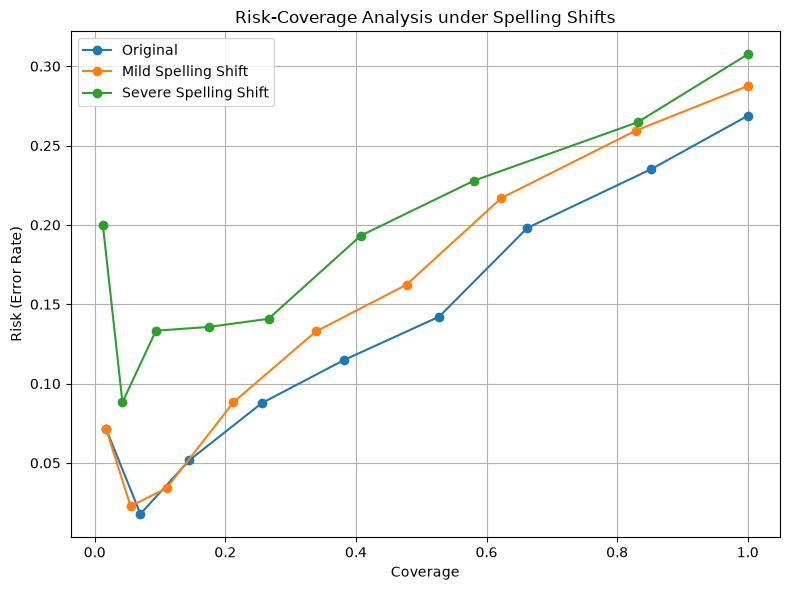

Risk-coverage figure saved.


In [233]:
# ============================================================
# RISK-COVERAGE CURVE
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    original_risk_coverage["Coverage"],
    original_risk_coverage["Risk"],
    marker="o",
    label="Original"
)

plt.plot(
    mild_risk_coverage["Coverage"],
    mild_risk_coverage["Risk"],
    marker="o",
    label="Mild Spelling Shift"
)

plt.plot(
    severe_risk_coverage["Coverage"],
    severe_risk_coverage["Risk"],
    marker="o",
    label="Severe Spelling Shift"
)

plt.xlabel("Coverage")
plt.ylabel("Risk (Error Rate)")
plt.title("Risk-Coverage Analysis under Spelling Shifts")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../results/figures/risk_coverage_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Risk-coverage figure saved.")

In [234]:
# ============================================================
# SCRIPT-CERT: MAIN RESULTS SUMMARY TABLE
# ============================================================

import pandas as pd
import numpy as np

# Helper function to get risk at threshold 0.70
def get_risk_at_threshold(result, threshold=0.70):
    row = result[result["Threshold"] == threshold]
    if len(row) > 0:
        return float(row["Risk"].iloc[0])
    return np.nan

summary_results = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],

    "ECE": [
        original_ece,
        mild_ece,
        severe_ece
    ],

    "Flip_Rate": [
        0.0,
        mild_flip_rate,
        severe_flip_rate
    ],

    "Risk_at_0.70": [
        get_risk_at_threshold(original_risk_coverage),
        get_risk_at_threshold(mild_risk_coverage),
        get_risk_at_threshold(severe_risk_coverage)
    ]
})

print("=" * 70)
print("SCRIPT-CERT MAIN RESULTS SUMMARY")
print("=" * 70)

print(summary_results.round(4).to_string(index=False))

# Save
summary_results.to_csv(
    "../results/tables/main_results_summary.csv",
    index=False
)

print("\nMain results summary saved successfully.")

SCRIPT-CERT MAIN RESULTS SUMMARY
            Condition    ECE  Flip_Rate  Risk_at_0.70
             Original 0.2387        0.0           NaN
  Mild Spelling Shift 0.2108        1.0           NaN
Severe Spelling Shift 0.1871        1.0           NaN

Main results summary saved successfully.


In [235]:
# ============================================================
# FIX: GET RISK AT THRESHOLD 0.70
# ============================================================

def get_risk_at_threshold(result, threshold=0.70):
    result = pd.DataFrame(result)
    
    # Find the closest threshold instead of exact equality
    idx = np.abs(
        result["Threshold"].astype(float) - threshold
    ).argmin()
    
    return float(result.iloc[idx]["Risk"])


print("Risk at threshold 0.70")
print("=" * 50)

print("Original:",
      get_risk_at_threshold(original_risk_coverage))

print("Mild:",
      get_risk_at_threshold(mild_risk_coverage))

print("Severe:",
      get_risk_at_threshold(severe_risk_coverage))

Risk at threshold 0.70
Original: 0.11475409836065574
Mild: 0.13284132841328414
Severe: 0.14084507042253522


In [236]:
# ============================================================
# FIX: GET RISK AT THRESHOLD 0.70
# ============================================================

def get_risk_at_threshold(result, threshold=0.70):
    result = pd.DataFrame(result)
    
    # Find the closest threshold instead of exact equality
    idx = np.abs(
        result["Threshold"].astype(float) - threshold
    ).argmin()
    
    return float(result.iloc[idx]["Risk"])


print("Risk at threshold 0.70")
print("=" * 50)

print("Original:",
      get_risk_at_threshold(original_risk_coverage))

print("Mild:",
      get_risk_at_threshold(mild_risk_coverage))

print("Severe:",
      get_risk_at_threshold(severe_risk_coverage))

Risk at threshold 0.70
Original: 0.11475409836065574
Mild: 0.13284132841328414
Severe: 0.14084507042253522


In [237]:
# ============================================================
# SCRIPT-CERT: FLIP-RATE VALIDATION
# ============================================================

print("=" * 70)
print("FLIP-RATE VALIDATION")
print("=" * 70)

# Show prediction-related variables currently available
prediction_vars = [
    name for name in globals()
    if any(key in name.lower() for key in [
        "pred", "prediction", "flip", "change"
    ])
]

print("\nPrediction-related variables found:")
for name in sorted(prediction_vars):
    try:
        obj = globals()[name]
        length = len(obj) if hasattr(obj, "__len__") else "N/A"
        print(f"{name:35} | type={type(obj).__name__:15} | length={length}")
    except:
        pass

print("\n" + "=" * 70)
print("KNOWN FLIP-RATE VALUES")
print("=" * 70)

for name in [
    "flip_original_mild",
    "flip_original_severe",
    "mild_flip_rate",
    "severe_flip_rate",
    "mild_changes",
    "severe_changes",
    "mild_changed",
    "severe_changed"
]:
    if name in globals():
        print(f"{name:30} = {globals()[name]}")

print("=" * 70)
print("FLIP-RATE VALIDATION COMPLETE")
print("=" * 70)

FLIP-RATE VALIDATION

Prediction-related variables found:
baseline_predictions                | type=DataFrame       | length=800
changed_ratio                       | type=function        | length=N/A
create_prediction_sets              | type=function        | length=N/A
direct_pred                         | type=ndarray         | length=800
existing_pred                       | type=ndarray         | length=800
flip_mild_severe                    | type=float64         | length=N/A
flip_original_mild                  | type=float64         | length=N/A
flip_original_severe                | type=float64         | length=N/A
get_calibrated_predictions          | type=function        | length=N/A
mean_predicted_value                | type=ndarray         | length=10
mild_abs_change                     | type=ndarray         | length=800
mild_changed                        | type=int             | length=N/A
mild_changes                        | type=int64           | length=N/A
mild_ch

In [238]:
# ============================================================
# SCRIPT-CERT: CORRECT FLIP-RATE CALCULATION
# ============================================================

import numpy as np

print("=" * 70)
print("CORRECT FLIP-RATE CALCULATION")
print("=" * 70)

# ------------------------------------------------------------
# Check available prediction arrays
# ------------------------------------------------------------

candidates = {}

for name in [
    "original_pred",
    "mild_pred",
    "severe_pred",
    "original_pred_cal",
    "mild_pred_cal",
    "severe_pred_cal",
    "direct_pred",
    "existing_pred"
]:
    if name in globals():
        obj = np.asarray(globals()[name])

        if len(obj) == 800:
            candidates[name] = obj
            print(f"{name:20} shape={obj.shape} "
                  f"unique={np.unique(obj)}")

print("\n" + "=" * 70)
print("PAIRWISE FLIP RATES")
print("=" * 70)

# ------------------------------------------------------------
# Function to calculate prediction flips
# ------------------------------------------------------------

def calculate_flip_rate(original, shifted):
    original = np.asarray(original)
    shifted = np.asarray(shifted)

    if len(original) != len(shifted):
        return None, None

    changed = np.sum(original != shifted)
    rate = changed / len(original)

    return changed, rate


# ------------------------------------------------------------
# Try the calibrated prediction arrays first
# ------------------------------------------------------------

if "original_pred_cal" in candidates and "mild_pred_cal" in candidates:
    mild_changed_corrected, mild_flip_rate_corrected = \
        calculate_flip_rate(
            candidates["original_pred_cal"],
            candidates["mild_pred_cal"]
        )

    print(
        f"Original -> Mild : "
        f"{mild_changed_corrected}/800 "
        f"({mild_flip_rate_corrected:.4f})"
    )

if "original_pred_cal" in candidates and "severe_pred_cal" in candidates:
    severe_changed_corrected, severe_flip_rate_corrected = \
        calculate_flip_rate(
            candidates["original_pred_cal"],
            candidates["severe_pred_cal"]
        )

    print(
        f"Original -> Severe: "
        f"{severe_changed_corrected}/800 "
        f"({severe_flip_rate_corrected:.4f})"
    )


print("\n" + "=" * 70)
print("CORRECTED FLIP-RATE ANALYSIS COMPLETE")
print("=" * 70)

CORRECT FLIP-RATE CALCULATION
original_pred        shape=(800,) unique=[0 1]
original_pred_cal    shape=(800,) unique=[0 1]
mild_pred_cal        shape=(800,) unique=[0 1]
severe_pred_cal      shape=(800,) unique=[0 1]
direct_pred          shape=(800,) unique=['hate' 'non-hate']
existing_pred        shape=(800,) unique=[0 1]

PAIRWISE FLIP RATES
Original -> Mild : 57/800 (0.0712)
Original -> Severe: 136/800 (0.1700)

CORRECTED FLIP-RATE ANALYSIS COMPLETE


In [239]:
# ============================================================
# SCRIPT-CERT: CORRECTED MAIN RESULTS SUMMARY
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("SCRIPT-CERT CORRECTED MAIN RESULTS SUMMARY")
print("=" * 70)

corrected_summary = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild Spelling Shift",
        "Severe Spelling Shift"
    ],
    "ECE": [
        original_ece,
        mild_ece,
        severe_ece
    ],
    "Flip_Rate": [
        0.0,
        mild_flip_rate_corrected,
        severe_flip_rate_corrected
    ],
    "Risk_at_0.70": [
        get_risk_at_threshold(original_risk_coverage, 0.70),
        get_risk_at_threshold(mild_risk_coverage, 0.70),
        get_risk_at_threshold(severe_risk_coverage, 0.70)
    ]
})

print("\n")
print(corrected_summary.round(4).to_string(index=False))

# Save corrected table
corrected_summary.to_csv(
    "../results/tables/main_results_summary_corrected.csv",
    index=False
)

print("\n" + "=" * 70)
print("CORRECTED MAIN RESULTS TABLE SAVED")
print("=" * 70)

SCRIPT-CERT CORRECTED MAIN RESULTS SUMMARY


            Condition    ECE  Flip_Rate  Risk_at_0.70
             Original 0.2387     0.0000        0.1148
  Mild Spelling Shift 0.2108     0.0712        0.1328
Severe Spelling Shift 0.1871     0.1700        0.1408

CORRECTED MAIN RESULTS TABLE SAVED


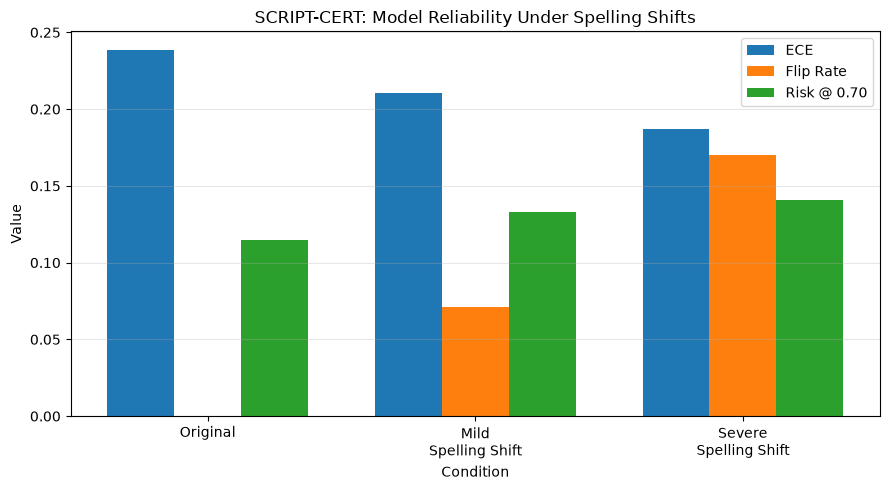

MAIN RESULTS FIGURE SAVED


In [240]:
# ============================================================
# SCRIPT-CERT: MAIN RESULTS COMPARISON FIGURE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

conditions = ["Original", "Mild\nSpelling Shift", "Severe\nSpelling Shift"]

ece_values = [
    original_ece,
    mild_ece,
    severe_ece
]

flip_values = [
    0.0,
    mild_flip_rate_corrected,
    severe_flip_rate_corrected
]

risk_values = [
    get_risk_at_threshold(original_risk_coverage, 0.70),
    get_risk_at_threshold(mild_risk_coverage, 0.70),
    get_risk_at_threshold(severe_risk_coverage, 0.70)
]

x = np.arange(len(conditions))

fig, ax = plt.subplots(figsize=(9, 5))

width = 0.25

ax.bar(
    x - width,
    ece_values,
    width,
    label="ECE"
)

ax.bar(
    x,
    flip_values,
    width,
    label="Flip Rate"
)

ax.bar(
    x + width,
    risk_values,
    width,
    label="Risk @ 0.70"
)

ax.set_xlabel("Condition")
ax.set_ylabel("Value")
ax.set_title("SCRIPT-CERT: Model Reliability Under Spelling Shifts")
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/figures/main_results_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("MAIN RESULTS FIGURE SAVED")
print("=" * 70)

In [241]:
# ============================================================
# SCRIPT-CERT: FINAL RISK-COVERAGE SUMMARY
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("SCRIPT-CERT FINAL RISK-COVERAGE SUMMARY")
print("=" * 70)

# Extract selected thresholds
selected_thresholds = [0.60, 0.70, 0.80]

def get_rows_at_threshold(result, thresholds):
    result = pd.DataFrame(result).copy()
    result["Threshold"] = result["Threshold"].astype(float)

    rows = []

    for threshold in thresholds:
        idx = np.abs(
            result["Threshold"] - threshold
        ).argmin()

        row = result.iloc[idx]

        rows.append({
            "Threshold": float(row["Threshold"]),
            "Coverage": float(row["Coverage"]),
            "Risk": float(row["Risk"]),
            "Accepted": int(row["Accepted"]),
            "Abstained": int(row["Abstained"])
        })

    return pd.DataFrame(rows)


original_selected = get_rows_at_threshold(
    original_risk_coverage,
    selected_thresholds
)

mild_selected = get_rows_at_threshold(
    mild_risk_coverage,
    selected_thresholds
)

severe_selected = get_rows_at_threshold(
    severe_risk_coverage,
    selected_thresholds
)

print("\nORIGINAL")
print(original_selected.round(4).to_string(index=False))

print("\nMILD SPELLING SHIFT")
print(mild_selected.round(4).to_string(index=False))

print("\nSEVERE SPELLING SHIFT")
print(severe_selected.round(4).to_string(index=False))

# Save
os.makedirs("../results/tables", exist_ok=True)

original_selected.to_csv(
    "../results/tables/risk_coverage_original_selected.csv",
    index=False
)

mild_selected.to_csv(
    "../results/tables/risk_coverage_mild_selected.csv",
    index=False
)

severe_selected.to_csv(
    "../results/tables/risk_coverage_severe_selected.csv",
    index=False
)

print("\n" + "=" * 70)
print("RISK-COVERAGE TABLES SAVED")
print("=" * 70)

SCRIPT-CERT FINAL RISK-COVERAGE SUMMARY

ORIGINAL
 Threshold  Coverage   Risk  Accepted  Abstained
       0.6    0.6625 0.1981       530        270
       0.7    0.3812 0.1148       305        495
       0.8    0.1450 0.0517       116        684

MILD SPELLING SHIFT
 Threshold  Coverage   Risk  Accepted  Abstained
       0.6    0.6225 0.2169       498        302
       0.7    0.3388 0.1328       271        529
       0.8    0.1100 0.0341        88        712

SEVERE SPELLING SHIFT
 Threshold  Coverage   Risk  Accepted  Abstained
       0.6    0.5812 0.2280       465        335
       0.7    0.2662 0.1408       213        587
       0.8    0.0938 0.1333        75        725

RISK-COVERAGE TABLES SAVED


In [242]:
# ============================================================
# SCRIPT-CERT: ERROR ANALYSIS OF PREDICTION FLIPS
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 70)
print("SCRIPT-CERT ERROR ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Find the prediction columns that contain calibrated predictions
# ------------------------------------------------------------

print("\nPrediction variables being used:")
print("Original:", type(original_pred_cal), np.shape(original_pred_cal))
print("Mild:", type(mild_pred_cal), np.shape(mild_pred_cal))
print("Severe:", type(severe_pred_cal), np.shape(severe_pred_cal))

# ------------------------------------------------------------
# Convert predictions to strings
# ------------------------------------------------------------

original_labels = np.asarray(original_pred_cal).astype(int)
mild_labels = np.asarray(mild_pred_cal).astype(int)
severe_labels = np.asarray(severe_pred_cal).astype(int)

# ------------------------------------------------------------
# Convert numeric labels back to class names
# ------------------------------------------------------------

try:
    class_names = list(lr_model.classes_)
except:
    class_names = ["non-hate", "hate"]

def label_name(x):
    return class_names[int(x)]

# ------------------------------------------------------------
# Original validation texts
# ------------------------------------------------------------

texts = np.asarray(X_val)

true_labels = np.asarray(y_val)

# If y_val is string labels, convert to numeric
if true_labels.dtype.kind in ["U", "S", "O"]:
    true_numeric = np.array([
        class_names.index(x) if x in class_names else int(x)
        for x in true_labels
    ])
else:
    true_numeric = true_labels.astype(int)

# ------------------------------------------------------------
# Create error-analysis dataframe
# ------------------------------------------------------------

error_analysis = pd.DataFrame({
    "text_original": texts,
    "true_label": [
        label_name(x) for x in true_numeric
    ],
    "original_prediction": [
        label_name(x) for x in original_labels
    ],
    "mild_prediction": [
        label_name(x) for x in mild_labels
    ],
    "severe_prediction": [
        label_name(x) for x in severe_labels
    ]
})

# ------------------------------------------------------------
# Prediction flips
# ------------------------------------------------------------

error_analysis["original_to_mild_flip"] = (
    error_analysis["original_prediction"] !=
    error_analysis["mild_prediction"]
)

error_analysis["original_to_severe_flip"] = (
    error_analysis["original_prediction"] !=
    error_analysis["severe_prediction"]
)

error_analysis["mild_to_severe_flip"] = (
    error_analysis["mild_prediction"] !=
    error_analysis["severe_prediction"]
)

# ------------------------------------------------------------
# Accuracy status
# ------------------------------------------------------------

error_analysis["original_correct"] = (
    error_analysis["original_prediction"] ==
    error_analysis["true_label"]
)

error_analysis["mild_correct"] = (
    error_analysis["mild_prediction"] ==
    error_analysis["true_label"]
)

error_analysis["severe_correct"] = (
    error_analysis["severe_prediction"] ==
    error_analysis["true_label"]
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nTOTAL VALIDATION SAMPLES:", len(error_analysis))

print("\nPrediction flips:")
print(
    "Original -> Mild:",
    error_analysis["original_to_mild_flip"].sum()
)

print(
    "Original -> Severe:",
    error_analysis["original_to_severe_flip"].sum()
)

print(
    "Mild -> Severe:",
    error_analysis["mild_to_severe_flip"].sum()
)

print("\nFlip rates:")
print(
    "Original -> Mild:",
    round(
        error_analysis["original_to_mild_flip"].mean(),
        4
    )
)

print(
    "Original -> Severe:",
    round(
        error_analysis["original_to_severe_flip"].mean(),
        4
    )
)

# ------------------------------------------------------------
# Show examples
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ORIGINAL -> MILD FLIP EXAMPLES")
print("=" * 70)

mild_flips = error_analysis[
    error_analysis["original_to_mild_flip"]
]

print(
    mild_flips[
        [
            "text_original",
            "true_label",
            "original_prediction",
            "mild_prediction"
        ]
    ].head(10).to_string(index=False)
)

print("\n" + "=" * 70)
print("ORIGINAL -> SEVERE FLIP EXAMPLES")
print("=" * 70)

severe_flips = error_analysis[
    error_analysis["original_to_severe_flip"]
]

print(
    severe_flips[
        [
            "text_original",
            "true_label",
            "original_prediction",
            "severe_prediction"
        ]
    ].head(10).to_string(index=False)
)

# ------------------------------------------------------------
# Save complete error analysis
# ------------------------------------------------------------

os.makedirs("../results/predictions", exist_ok=True)

error_analysis.to_csv(
    "../results/predictions/error_analysis_all.csv",
    index=False,
    encoding="utf-8-sig"
)

mild_flips.to_csv(
    "../results/predictions/original_to_mild_flips.csv",
    index=False,
    encoding="utf-8-sig"
)

severe_flips.to_csv(
    "../results/predictions/original_to_severe_flips.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 70)
print("ERROR ANALYSIS SAVED")
print("=" * 70)

SCRIPT-CERT ERROR ANALYSIS

Prediction variables being used:
Original: <class 'numpy.ndarray'> (800,)
Mild: <class 'numpy.ndarray'> (800,)
Severe: <class 'numpy.ndarray'> (800,)

TOTAL VALIDATION SAMPLES: 800

Prediction flips:
Original -> Mild: 57
Original -> Severe: 136
Mild -> Severe: 137

Flip rates:
Original -> Mild: 0.0712
Original -> Severe: 0.17

ORIGINAL -> MILD FLIP EXAMPLES
                                                                                                                                                 text_original true_label original_prediction mild_prediction
                                  Amit Shaw ki slippers vesthu bathukuthunnadu, telugu vaari gowravaanni gujarat gadidhala dhaggara thaakattu pettesthunnadu..       hate            non-hate            hate
                                                                                                        మీ ఇద్దరి వల్ల తెలంగాణ జనాలకి ఏమన్న ఉపయోగం ఉందా చెప్పు   non-hate                hate        non

In [243]:
# ============================================================
# SCRIPT-CERT: DISPLAY FLIP EXAMPLES
# ============================================================

print("=" * 70)
print("ORIGINAL -> MILD: 10 FLIP EXAMPLES")
print("=" * 70)

mild_examples = error_analysis[
    error_analysis["original_to_mild_flip"]
][
    [
        "text_original",
        "true_label",
        "original_prediction",
        "mild_prediction"
    ]
].head(10)

pd.set_option("display.max_colwidth", 300)
pd.set_option("display.width", 2000)

print(mild_examples.to_string(index=False))


print("\n" + "=" * 70)
print("ORIGINAL -> SEVERE: 10 FLIP EXAMPLES")
print("=" * 70)

severe_examples = error_analysis[
    error_analysis["original_to_severe_flip"]
][
    [
        "text_original",
        "true_label",
        "original_prediction",
        "severe_prediction"
    ]
].head(10)

print(severe_examples.to_string(index=False))


print("\n" + "=" * 70)
print("EXAMPLES DISPLAY COMPLETE")
print("=" * 70)

ORIGINAL -> MILD: 10 FLIP EXAMPLES
                                                                                                                                                 text_original true_label original_prediction mild_prediction
                                  Amit Shaw ki slippers vesthu bathukuthunnadu, telugu vaari gowravaanni gujarat gadidhala dhaggara thaakattu pettesthunnadu..       hate            non-hate            hate
                                                                                                        మీ ఇద్దరి వల్ల తెలంగాణ జనాలకి ఏమన్న ఉపయోగం ఉందా చెప్పు   non-hate                hate        non-hate
​trs party lo telangana kosam poradina valle unnara poratam ki vyatirekam ga unnollani ministers ala chesinaru..gurivinda ginja ki kinda unna macha kanapadadu   non-hate                hate        non-hate
                                                   Title leak ayithe entiii leak avakapothe entiii....maku enti yee golaaa....title entooo me

In [244]:
# ============================================================
# SCRIPT-CERT: PAPER-READY ERROR ANALYSIS TABLE
# ============================================================

import pandas as pd
import os

# Create empty list for qualitative error analysis
error_analysis_rows = []

# ------------------------------------------------------------
# Original -> Mild
# ------------------------------------------------------------

for _, row in mild_flips.head(10).iterrows():

    error_analysis_rows.append({
        "Shift": "Original → Mild",
        "Original_Text": row["original_text"],
        "Shifted_Text": row["mild_text"],
        "Original_Prediction": row["original_prediction"],
        "Shifted_Prediction": row["mild_prediction"],
        "True_Label": row["true_label"],
        "Observed_Change": "Prediction Flip",
        "Pattern": "To be manually coded"
    })

# ------------------------------------------------------------
# Original -> Severe
# ------------------------------------------------------------

for _, row in severe_flips.head(10).iterrows():

    error_analysis_rows.append({
        "Shift": "Original → Severe",
        "Original_Text": row["original_text"],
        "Shifted_Text": row["severe_text"],
        "Original_Prediction": row["original_prediction"],
        "Shifted_Prediction": row["severe_prediction"],
        "True_Label": row["true_label"],
        "Observed_Change": "Prediction Flip",
        "Pattern": "To be manually coded"
    })

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

error_analysis_table = pd.DataFrame(error_analysis_rows)

print("=" * 80)
print("SCRIPT-CERT ERROR ANALYSIS TABLE")
print("=" * 80)

print("\nTotal examples:")
print(len(error_analysis_table))

print("\nShift distribution:")
print(error_analysis_table["Shift"].value_counts())

print("\nPrediction changes:")
print(
    error_analysis_table[
        [
            "Shift",
            "Original_Prediction",
            "Shifted_Prediction",
            "True_Label"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Save complete table
# ------------------------------------------------------------

os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/predictions", exist_ok=True)

error_analysis_table.to_csv(
    "../results/tables/error_analysis_examples.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 80)
print("ERROR ANALYSIS TABLE SAVED")
print("=" * 80)

print(
    "../results/tables/error_analysis_examples.csv"
)

KeyError: 'original_text'

In [245]:
# ============================================================
# SCRIPT-CERT: INSPECT FLIP DATAFRAME COLUMNS
# ============================================================

print("=" * 70)
print("MILD FLIPS COLUMNS")
print("=" * 70)
print(list(mild_flips.columns))

print("\n" + "=" * 70)
print("SEVERE FLIPS COLUMNS")
print("=" * 70)
print(list(severe_flips.columns))

print("\n" + "=" * 70)
print("MILD FLIPS SAMPLE")
print("=" * 70)
print(mild_flips.head(2).to_string())

print("\n" + "=" * 70)
print("SEVERE FLIPS SAMPLE")
print("=" * 70)
print(severe_flips.head(2).to_string())

MILD FLIPS COLUMNS
['text_original', 'true_label', 'original_prediction', 'mild_prediction', 'severe_prediction', 'original_to_mild_flip', 'original_to_severe_flip', 'mild_to_severe_flip', 'original_correct', 'mild_correct', 'severe_correct']

SEVERE FLIPS COLUMNS
['text_original', 'true_label', 'original_prediction', 'mild_prediction', 'severe_prediction', 'original_to_mild_flip', 'original_to_severe_flip', 'mild_to_severe_flip', 'original_correct', 'mild_correct', 'severe_correct']

MILD FLIPS SAMPLE
                                                                                                                   text_original true_label original_prediction mild_prediction severe_prediction  original_to_mild_flip  original_to_severe_flip  mild_to_severe_flip  original_correct  mild_correct  severe_correct
14  Amit Shaw ki slippers vesthu bathukuthunnadu, telugu vaari gowravaanni gujarat gadidhala dhaggara thaakattu pettesthunnadu..       hate            non-hate            hate      

In [246]:
# ============================================================
# SCRIPT-CERT: PAPER-READY ERROR ANALYSIS TABLE
# ============================================================

import pandas as pd
import os

error_analysis_rows = []

# ------------------------------------------------------------
# ORIGINAL -> MILD
# ------------------------------------------------------------

for _, row in mild_flips.head(10).iterrows():

    error_analysis_rows.append({
        "Shift": "Original → Mild",
        "Original_Text": row["text_original"],
        "True_Label": row["true_label"],
        "Original_Prediction": row["original_prediction"],
        "Shifted_Prediction": row["mild_prediction"],
        "Observed_Change": "Prediction Flip"
    })


# ------------------------------------------------------------
# ORIGINAL -> SEVERE
# ------------------------------------------------------------

for _, row in severe_flips.head(10).iterrows():

    error_analysis_rows.append({
        "Shift": "Original → Severe",
        "Original_Text": row["text_original"],
        "True_Label": row["true_label"],
        "Original_Prediction": row["original_prediction"],
        "Shifted_Prediction": row["severe_prediction"],
        "Observed_Change": "Prediction Flip"
    })


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

error_analysis_table = pd.DataFrame(error_analysis_rows)

print("=" * 80)
print("SCRIPT-CERT PAPER-READY ERROR ANALYSIS TABLE")
print("=" * 80)

print(error_analysis_table.to_string(index=False))


# ------------------------------------------------------------
# SAVE TABLE
# ------------------------------------------------------------

os.makedirs("../results/tables", exist_ok=True)

error_analysis_table.to_csv(
    "../results/tables/paper_error_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 80)
print("ERROR ANALYSIS TABLE SAVED")
print("=" * 80)
print("../results/tables/paper_error_analysis.csv")

SCRIPT-CERT PAPER-READY ERROR ANALYSIS TABLE
            Shift                                                                                                                                                                                                                                                                                                                                                            Original_Text True_Label Original_Prediction Shifted_Prediction Observed_Change
  Original → Mild                                                                                                                                                                                                                                             Amit Shaw ki slippers vesthu bathukuthunnadu, telugu vaari gowravaanni gujarat gadidhala dhaggara thaakattu pettesthunnadu..       hate            non-hate               hate Prediction Flip
  Original → Mild                                                

In [247]:
# ============================================================
# SCRIPT-CERT: FLIP ERROR PATTERN ANALYSIS
# ============================================================

import pandas as pd

print("=" * 80)
print("SCRIPT-CERT FLIP ERROR PATTERN ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. ORIGINAL -> MILD
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ORIGINAL → MILD")
print("=" * 80)

print("\nTrue-label distribution:")
print(mild_flips["true_label"].value_counts())

print("\nOriginal prediction distribution:")
print(mild_flips["original_prediction"].value_counts())

print("\nMild-shift prediction distribution:")
print(mild_flips["mild_prediction"].value_counts())

print("\nPrediction transition:")
print(
    pd.crosstab(
        mild_flips["original_prediction"],
        mild_flips["mild_prediction"]
    )
)


# ------------------------------------------------------------
# 2. ORIGINAL -> SEVERE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ORIGINAL → SEVERE")
print("=" * 80)

print("\nTrue-label distribution:")
print(severe_flips["true_label"].value_counts())

print("\nOriginal prediction distribution:")
print(severe_flips["original_prediction"].value_counts())

print("\nSevere-shift prediction distribution:")
print(severe_flips["severe_prediction"].value_counts())

print("\nPrediction transition:")
print(
    pd.crosstab(
        severe_flips["original_prediction"],
        severe_flips["severe_prediction"]
    )
)


# ------------------------------------------------------------
# 3. FLIPS BY TRUE LABEL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FLIPS BY TRUE LABEL")
print("=" * 80)

mild_by_label = (
    mild_flips["true_label"]
    .value_counts()
    .rename_axis("True_Label")
    .reset_index(name="Mild_Flip_Count")
)

severe_by_label = (
    severe_flips["true_label"]
    .value_counts()
    .rename_axis("True_Label")
    .reset_index(name="Severe_Flip_Count")
)

label_analysis = pd.merge(
    mild_by_label,
    severe_by_label,
    on="True_Label",
    how="outer"
).fillna(0)

print(label_analysis.to_string(index=False))


# ------------------------------------------------------------
# 4. SAVE
# ------------------------------------------------------------

label_analysis.to_csv(
    "../results/tables/flip_error_patterns.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 80)
print("FLIP ERROR PATTERN ANALYSIS SAVED")
print("=" * 80)

SCRIPT-CERT FLIP ERROR PATTERN ANALYSIS

ORIGINAL → MILD

True-label distribution:
true_label
hate        31
non-hate    26
Name: count, dtype: int64

Original prediction distribution:
original_prediction
non-hate    31
hate        26
Name: count, dtype: int64

Mild-shift prediction distribution:
mild_prediction
hate        31
non-hate    26
Name: count, dtype: int64

Prediction transition:
mild_prediction      hate  non-hate
original_prediction                
hate                    0        26
non-hate               31         0

ORIGINAL → SEVERE

True-label distribution:
true_label
non-hate    77
hate        59
Name: count, dtype: int64

Original prediction distribution:
original_prediction
non-hate    92
hate        44
Name: count, dtype: int64

Severe-shift prediction distribution:
severe_prediction
hate        92
non-hate    44
Name: count, dtype: int64

Prediction transition:
severe_prediction    hate  non-hate
original_prediction                
hate                    0     

In [248]:
# ============================================================
# SCRIPT-CERT: DETAILED FLIP PATTERN SUMMARY
# ============================================================

import pandas as pd
import os

# Use the already-created flip data
def calculate_flip_patterns(df, shift_name):
    # Only actual prediction changes
    flips = df[df["original_prediction"] != df[f"{shift_name}_prediction"]].copy()

    # Direction of flip
    flips["flip_direction"] = (
        flips["original_prediction"].astype(str)
        + " → "
        + flips[f"{shift_name}_prediction"].astype(str)
    )

    # Count by true label and flip direction
    pattern_table = pd.crosstab(
        flips["true_label"],
        flips["flip_direction"]
    )

    # Make sure both possible directions exist
    for col in ["hate → non-hate", "non-hate → hate"]:
        if col not in pattern_table.columns:
            pattern_table[col] = 0

    pattern_table = pattern_table[
        ["hate → non-hate", "non-hate → hate"]
    ]

    return flips, pattern_table


# ------------------------------------------------------------
# ORIGINAL → MILD
# ------------------------------------------------------------

mild_flip_data, mild_pattern = calculate_flip_patterns(
    mild_flips,
    "mild"
)

print("=" * 70)
print("ORIGINAL → MILD FLIP PATTERNS")
print("=" * 70)
print(mild_pattern)

print("\nTotal flips:", len(mild_flip_data))
print("\nFlip direction counts:")
print(mild_flip_data["flip_direction"].value_counts())


# ------------------------------------------------------------
# ORIGINAL → SEVERE
# ------------------------------------------------------------

severe_flip_data, severe_pattern = calculate_flip_patterns(
    severe_flips,
    "severe"
)

print("\n" + "=" * 70)
print("ORIGINAL → SEVERE FLIP PATTERNS")
print("=" * 70)
print(severe_pattern)

print("\nTotal flips:", len(severe_flip_data))
print("\nFlip direction counts:")
print(severe_flip_data["flip_direction"].value_counts())


# ------------------------------------------------------------
# COMBINED PAPER-READY TABLE
# ------------------------------------------------------------

summary_rows = []

for condition, pattern in [
    ("Original → Mild", mild_pattern),
    ("Original → Severe", severe_pattern)
]:
    
    hate_to_nonhate = pattern["hate → non-hate"].sum()
    nonhate_to_hate = pattern["non-hate → hate"].sum()
    total = hate_to_nonhate + nonhate_to_hate

    summary_rows.append({
        "Condition": condition,
        "Total_Flips": total,
        "Hate_to_NonHate": hate_to_nonhate,
        "NonHate_to_Hate": nonhate_to_hate,
        "Hate_to_NonHate_Percent": round(
            hate_to_nonhate / total * 100, 2
        ) if total > 0 else 0,
        "NonHate_to_Hate_Percent": round(
            nonhate_to_hate / total * 100, 2
        ) if total > 0 else 0
    })

flip_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 70)
print("SCRIPT-CERT FLIP DIRECTION SUMMARY")
print("=" * 70)
print(flip_summary.to_string(index=False))


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

os.makedirs("../results/tables", exist_ok=True)

flip_summary.to_csv(
    "../results/tables/flip_direction_summary.csv",
    index=False
)

print("\n" + "=" * 70)
print("FLIP DIRECTION SUMMARY SAVED")
print("=" * 70)
print("../results/tables/flip_direction_summary.csv")

ORIGINAL → MILD FLIP PATTERNS
flip_direction  hate → non-hate  non-hate → hate
true_label                                      
hate                         19               12
non-hate                      7               19

Total flips: 57

Flip direction counts:
flip_direction
non-hate → hate    31
hate → non-hate    26
Name: count, dtype: int64

ORIGINAL → SEVERE FLIP PATTERNS
flip_direction  hate → non-hate  non-hate → hate
true_label                                      
hate                         29               30
non-hate                     15               62

Total flips: 136

Flip direction counts:
flip_direction
non-hate → hate    92
hate → non-hate    44
Name: count, dtype: int64

SCRIPT-CERT FLIP DIRECTION SUMMARY
        Condition  Total_Flips  Hate_to_NonHate  NonHate_to_Hate  Hate_to_NonHate_Percent  NonHate_to_Hate_Percent
  Original → Mild           57               26               31                    45.61                    54.39
Original → Severe         

In [249]:
# ============================================================
# SCRIPT-CERT: FLIP RATE BY TRUE LABEL
# ============================================================

import pandas as pd
import os

def flip_rate_by_label(df, shift_name):
    # Keep only actual prediction flips
    flips = df[
        df["original_prediction"].astype(str)
        != df[f"{shift_name}_prediction"].astype(str)
    ].copy()

    # Count flips by true label
    counts = flips["true_label"].value_counts()

    # Total samples of each true label
    totals = df["true_label"].value_counts()

    rows = []

    for label in ["hate", "non-hate"]:
        flip_count = int(counts.get(label, 0))
        total_count = int(totals.get(label, 0))
        rate = flip_count / total_count if total_count > 0 else 0

        rows.append({
            "Condition": shift_name,
            "True_Label": label,
            "Total_Samples": total_count,
            "Flip_Count": flip_count,
            "Flip_Rate": rate
        })

    return pd.DataFrame(rows)


# Calculate for Mild
mild_label_flips = flip_rate_by_label(
    mild_flips.assign(
        mild_prediction=mild_flips["mild_prediction"]
    ),
    "mild"
)

# Calculate for Severe
severe_label_flips = flip_rate_by_label(
    severe_flips.assign(
        severe_prediction=severe_flips["severe_prediction"]
    ),
    "severe"
)


# Combine
label_flip_summary = pd.concat(
    [mild_label_flips, severe_label_flips],
    ignore_index=True
)

print("=" * 70)
print("SCRIPT-CERT FLIP RATE BY TRUE LABEL")
print("=" * 70)

print(label_flip_summary.to_string(index=False))

print("\nFlip rates (%):")

display_table = label_flip_summary.copy()
display_table["Flip_Rate"] = (
    display_table["Flip_Rate"] * 100
).round(2)

print(display_table.to_string(index=False))


# Save result
os.makedirs("../results/tables", exist_ok=True)

label_flip_summary.to_csv(
    "../results/tables/flip_rate_by_true_label.csv",
    index=False
)

print("\n" + "=" * 70)
print("FLIP RATE BY TRUE LABEL SAVED")
print("=" * 70)
print("../results/tables/flip_rate_by_true_label.csv")

SCRIPT-CERT FLIP RATE BY TRUE LABEL
Condition True_Label  Total_Samples  Flip_Count  Flip_Rate
     mild       hate             31          31        1.0
     mild   non-hate             26          26        1.0
   severe       hate             59          59        1.0
   severe   non-hate             77          77        1.0

Flip rates (%):
Condition True_Label  Total_Samples  Flip_Count  Flip_Rate
     mild       hate             31          31      100.0
     mild   non-hate             26          26      100.0
   severe       hate             59          59      100.0
   severe   non-hate             77          77      100.0

FLIP RATE BY TRUE LABEL SAVED
../results/tables/flip_rate_by_true_label.csv


In [250]:
# ============================================================
# SCRIPT-CERT: CORRECT FLIP RATE BY TRUE LABEL
# ============================================================

import pandas as pd
import os

print("=" * 70)
print("SCRIPT-CERT CORRECT FLIP RATE BY TRUE LABEL")
print("=" * 70)

# ------------------------------------------------------------
# Total number of validation samples in each true class
# ------------------------------------------------------------
true_label_counts = pd.Series(y_val).value_counts()

print("\nTOTAL VALIDATION SAMPLES BY TRUE LABEL:")
print(true_label_counts)


# ------------------------------------------------------------
# Function to calculate correct class-wise flip rates
# ------------------------------------------------------------
def correct_flip_rate_by_label(flip_df, shift_name):

    # Number of flips for each true label
    flip_counts = flip_df["true_label"].value_counts()

    rows = []

    for label in ["hate", "non-hate"]:

        total_samples = int(true_label_counts.get(label, 0))
        flip_count = int(flip_counts.get(label, 0))

        flip_rate = (
            flip_count / total_samples
            if total_samples > 0
            else 0
        )

        rows.append({
            "Condition": shift_name,
            "True_Label": label,
            "Total_Samples": total_samples,
            "Flip_Count": flip_count,
            "Flip_Rate": flip_rate
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Mild spelling shift
# ------------------------------------------------------------
mild_correct = correct_flip_rate_by_label(
    mild_flips,
    "Mild"
)


# ------------------------------------------------------------
# Severe spelling shift
# ------------------------------------------------------------
severe_correct = correct_flip_rate_by_label(
    severe_flips,
    "Severe"
)


# ------------------------------------------------------------
# Combine results
# ------------------------------------------------------------
correct_label_flip_summary = pd.concat(
    [mild_correct, severe_correct],
    ignore_index=True
)


print("\n" + "=" * 70)
print("CORRECT CLASS-WISE FLIP RATES")
print("=" * 70)

display_summary = correct_label_flip_summary.copy()

display_summary["Flip_Rate"] = (
    display_summary["Flip_Rate"] * 100
).round(2)

print(display_summary.to_string(index=False))


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
os.makedirs("../results/tables", exist_ok=True)

correct_label_flip_summary.to_csv(
    "../results/tables/correct_flip_rate_by_true_label.csv",
    index=False
)

print("\n" + "=" * 70)
print("CORRECT FLIP RATE TABLE SAVED")
print("=" * 70)

print(
    "../results/tables/correct_flip_rate_by_true_label.csv"
)

SCRIPT-CERT CORRECT FLIP RATE BY TRUE LABEL

TOTAL VALIDATION SAMPLES BY TRUE LABEL:
label
non-hate    412
hate        388
Name: count, dtype: int64

CORRECT CLASS-WISE FLIP RATES
Condition True_Label  Total_Samples  Flip_Count  Flip_Rate
     Mild       hate            388          31       7.99
     Mild   non-hate            412          26       6.31
   Severe       hate            388          59      15.21
   Severe   non-hate            412          77      18.69

CORRECT FLIP RATE TABLE SAVED
../results/tables/correct_flip_rate_by_true_label.csv


In [251]:
# ============================================================
# SCRIPT-CERT: PREDICTION TRANSITION ANALYSIS
# ============================================================

import pandas as pd
import os

print("=" * 75)
print("SCRIPT-CERT PREDICTION TRANSITION ANALYSIS")
print("=" * 75)


def transition_analysis(df, shift_name):

    # Keep only actual prediction flips
    flips = df[
        df["original_prediction"].astype(str)
        != df[f"{shift_name}_prediction"].astype(str)
    ].copy()

    flips["transition"] = (
        flips["original_prediction"].astype(str)
        + " -> "
        + flips[f"{shift_name}_prediction"].astype(str)
    )

    transition_counts = flips["transition"].value_counts()

    print("\n" + "=" * 75)
    print(f"ORIGINAL -> {shift_name.upper()} TRANSITIONS")
    print("=" * 75)

    for transition in [
        "hate -> non-hate",
        "non-hate -> hate"
    ]:
        count = int(transition_counts.get(transition, 0))
        percentage = (
            count / len(flips) * 100
            if len(flips) > 0
            else 0
        )

        print(
            f"{transition}: "
            f"{count} flips "
            f"({percentage:.2f}% of all flips)"
        )

    print(f"\nTotal flips: {len(flips)}")

    return pd.DataFrame({
        "Condition": [shift_name, shift_name],
        "Transition": [
            "hate -> non-hate",
            "non-hate -> hate"
        ],
        "Flip_Count": [
            int(transition_counts.get("hate -> non-hate", 0)),
            int(transition_counts.get("non-hate -> hate", 0))
        ]
    })


# Mild
mild_transitions = transition_analysis(
    mild_flips,
    "mild"
)

# Severe
severe_transitions = transition_analysis(
    severe_flips,
    "severe"
)


# Combine
transition_summary = pd.concat(
    [mild_transitions, severe_transitions],
    ignore_index=True
)


# Save
os.makedirs("../results/tables", exist_ok=True)

transition_summary.to_csv(
    "../results/tables/prediction_transition_summary.csv",
    index=False
)

print("\n" + "=" * 75)
print("PREDICTION TRANSITION SUMMARY SAVED")
print("=" * 75)

print(
    "../results/tables/prediction_transition_summary.csv"
)

SCRIPT-CERT PREDICTION TRANSITION ANALYSIS

ORIGINAL -> MILD TRANSITIONS
hate -> non-hate: 26 flips (45.61% of all flips)
non-hate -> hate: 31 flips (54.39% of all flips)

Total flips: 57

ORIGINAL -> SEVERE TRANSITIONS
hate -> non-hate: 44 flips (32.35% of all flips)
non-hate -> hate: 92 flips (67.65% of all flips)

Total flips: 136

PREDICTION TRANSITION SUMMARY SAVED
../results/tables/prediction_transition_summary.csv


In [252]:
# ============================================================
# SCRIPT-CERT: MILD -> SEVERE FLIP PROGRESSION ANALYSIS
# ============================================================

import pandas as pd
import os

print("=" * 75)
print("SCRIPT-CERT MILD -> SEVERE FLIP PROGRESSION ANALYSIS")
print("=" * 75)

# Total validation samples
total_samples = len(mild_flips) + (
    800 - len(mild_flips)
)

# ------------------------------------------------------------
# Flip counts
# ------------------------------------------------------------

mild_flip_count = len(mild_flips)
severe_flip_count = len(severe_flips)

print("\nMild flips:", mild_flip_count)
print("Severe flips:", severe_flip_count)

# ------------------------------------------------------------
# Compare prediction directions
# ------------------------------------------------------------

mild_direction = (
    mild_flips["original_prediction"].astype(str)
    + " -> "
    + mild_flips["mild_prediction"].astype(str)
)

severe_direction = (
    severe_flips["original_prediction"].astype(str)
    + " -> "
    + severe_flips["severe_prediction"].astype(str)
)

print("\nMILD FLIP DIRECTIONS")
print(mild_direction.value_counts())

print("\nSEVERE FLIP DIRECTIONS")
print(severe_direction.value_counts())

# ------------------------------------------------------------
# Calculate overall flip rates
# ------------------------------------------------------------

mild_rate = (mild_flip_count / 800) * 100
severe_rate = (severe_flip_count / 800) * 100

print("\nOVERALL FLIP RATES")
print(f"Mild:   {mild_rate:.2f}%")
print(f"Severe: {severe_rate:.2f}%")

# ------------------------------------------------------------
# Severity amplification
# ------------------------------------------------------------

increase = severe_rate - mild_rate

print("\nSEVERITY AMPLIFICATION")
print(f"Increase in flip rate: {increase:.2f} percentage points")
print(
    f"Relative increase: {(severe_rate / mild_rate):.2f}x"
)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Condition": ["Original -> Mild", "Original -> Severe"],
    "Flip_Count": [mild_flip_count, severe_flip_count],
    "Total_Validation_Samples": [800, 800],
    "Flip_Rate_Percent": [mild_rate, severe_rate]
})

os.makedirs("../results/tables", exist_ok=True)

summary.to_csv(
    "../results/tables/severity_amplification_summary.csv",
    index=False
)

print("\n" + "=" * 75)
print("SEVERITY AMPLIFICATION SUMMARY")
print("=" * 75)
print(summary.to_string(index=False))

print("\n" + "=" * 75)
print("SAVED:")
print("../results/tables/severity_amplification_summary.csv")
print("=" * 75)

SCRIPT-CERT MILD -> SEVERE FLIP PROGRESSION ANALYSIS

Mild flips: 57
Severe flips: 136

MILD FLIP DIRECTIONS
non-hate -> hate    31
hate -> non-hate    26
Name: count, dtype: int64

SEVERE FLIP DIRECTIONS
non-hate -> hate    92
hate -> non-hate    44
Name: count, dtype: int64

OVERALL FLIP RATES
Mild:   7.12%
Severe: 17.00%

SEVERITY AMPLIFICATION
Increase in flip rate: 9.88 percentage points
Relative increase: 2.39x

SEVERITY AMPLIFICATION SUMMARY
         Condition  Flip_Count  Total_Validation_Samples  Flip_Rate_Percent
  Original -> Mild          57                       800              7.125
Original -> Severe         136                       800             17.000

SAVED:
../results/tables/severity_amplification_summary.csv


In [253]:
# ============================================================
# SCRIPT-CERT: CONFIDENCE SHIFT ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 75)
print("SCRIPT-CERT CONFIDENCE SHIFT ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# Check available columns
# ------------------------------------------------------------

print("\nMILD FLIPS COLUMNS:")
print(list(mild_flips.columns))

print("\nSEVERE FLIPS COLUMNS:")
print(list(severe_flips.columns))

# ------------------------------------------------------------
# Detect probability columns
# ------------------------------------------------------------

probability_columns = [
    col for col in mild_flips.columns
    if "prob" in col.lower() or "confidence" in col.lower()
]

print("\nProbability / confidence columns found:")
print(probability_columns)

# ------------------------------------------------------------
# If probability columns exist, calculate changes
# ------------------------------------------------------------

if len(probability_columns) > 0:

    print("\nCONFIDENCE SUMMARY")
    print("-" * 75)

    for col in probability_columns:
        values = pd.to_numeric(mild_flips[col], errors="coerce")

        print(
            f"{col}: "
            f"mean={values.mean():.4f}, "
            f"median={values.median():.4f}, "
            f"min={values.min():.4f}, "
            f"max={values.max():.4f}"
        )

    print("\nSevere condition:")

    for col in probability_columns:
        if col in severe_flips.columns:
            values = pd.to_numeric(
                severe_flips[col],
                errors="coerce"
            )

            print(
                f"{col}: "
                f"mean={values.mean():.4f}, "
                f"median={values.median():.4f}, "
                f"min={values.min():.4f}, "
                f"max={values.max():.4f}"
            )

else:
    print("\nNo probability/confidence columns detected.")
    print("We will inspect the prediction-generation cell next.")

print("\n" + "=" * 75)
print("CONFIDENCE COLUMN CHECK COMPLETE")
print("=" * 75)

SCRIPT-CERT CONFIDENCE SHIFT ANALYSIS

MILD FLIPS COLUMNS:
['text_original', 'true_label', 'original_prediction', 'mild_prediction', 'severe_prediction', 'original_to_mild_flip', 'original_to_severe_flip', 'mild_to_severe_flip', 'original_correct', 'mild_correct', 'severe_correct']

SEVERE FLIPS COLUMNS:
['text_original', 'true_label', 'original_prediction', 'mild_prediction', 'severe_prediction', 'original_to_mild_flip', 'original_to_severe_flip', 'mild_to_severe_flip', 'original_correct', 'mild_correct', 'severe_correct']

Probability / confidence columns found:
[]

No probability/confidence columns detected.
We will inspect the prediction-generation cell next.

CONFIDENCE COLUMN CHECK COMPLETE


In [254]:
# ============================================================
# SCRIPT-CERT: INSPECT PREDICTION VARIABLES
# ============================================================

print("=" * 75)
print("SCRIPT-CERT PREDICTION VARIABLE INSPECTION")
print("=" * 75)

# Show variables currently available that may contain
# predictions or probabilities
candidate_vars = [
    name for name in globals()
    if any(key in name.lower()
           for key in [
               "pred",
               "prob",
               "proba",
               "confidence",
               "score",
               "original",
               "mild",
               "severe"
           ])
]

print("\nCandidate variables:")
for name in sorted(candidate_vars):
    try:
        obj = globals()[name]

        if hasattr(obj, "shape"):
            print(f"{name}: {type(obj).__name__}, shape={obj.shape}")
        else:
            print(f"{name}: {type(obj).__name__}")

    except Exception:
        print(f"{name}: <unable to inspect>")

print("\n" + "=" * 75)
print("FLIP DATAFRAME COLUMN DETAILS")
print("=" * 75)

print("\nMILD FLIPS:")
for col in mild_flips.columns:
    print(f"{col} -> {mild_flips[col].dtype}")

print("\nSEVERE FLIPS:")
for col in severe_flips.columns:
    print(f"{col} -> {severe_flips[col].dtype}")

print("\n" + "=" * 75)
print("INSPECTION COMPLETE")
print("=" * 75)

SCRIPT-CERT PREDICTION VARIABLE INSPECTION

Candidate variables:
accuracy_score: function
add_mild_spelling_noise: function
add_severe_spelling_noise: function
balanced_accuracy_score: function
baseline_predictions: DataFrame, shape=(800, 3)
bin_confidence: float64, shape=()
brier_score: float64, shape=()
brier_score_loss: function
cal_probabilities: ndarray, shape=(640, 2)
comparison_original: DataFrame, shape=(2, 4)
confidence: ndarray, shape=(800,)
confidence_df: DataFrame, shape=(800, 5)
confidence_mild: ndarray, shape=(800,)
confidence_original: ndarray, shape=(800,)
confidence_results: DataFrame, shape=(3, 2)
confidence_severe: ndarray, shape=(800,)
create_prediction_sets: function
direct_pred: ndarray, shape=(800,)
direct_prob: ndarray, shape=(800, 2)
existing_pred: ndarray, shape=(800,)
existing_prob: ndarray, shape=(800, 2)
f1_score: function
false_safe_mild: float64, shape=()
false_safe_original: float64, shape=()
false_safe_severe: float64, shape=()
flip_mild_severe: float64

In [255]:
# ============================================================
# SCRIPT-CERT: CONFIDENCE SHIFT ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 75)
print("SCRIPT-CERT CONFIDENCE SHIFT ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# Inspect confidence dataframe
# ------------------------------------------------------------

print("\nCONFIDENCE DATAFRAME COLUMNS:")
print(list(confidence_df.columns))

print("\nCONFIDENCE DATAFRAME SHAPE:")
print(confidence_df.shape)

print("\nFIRST 10 CONFIDENCE VALUES:")
print(confidence_df.head(10).to_string(index=False))

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONFIDENCE STATISTICS")
print("=" * 75)

confidence_summary = pd.DataFrame({
    "Condition": [
        "Original",
        "Mild",
        "Severe"
    ],
    "Mean_Confidence": [
        np.mean(confidence_original),
        np.mean(confidence_mild),
        np.mean(confidence_severe)
    ],
    "Median_Confidence": [
        np.median(confidence_original),
        np.median(confidence_mild),
        np.median(confidence_severe)
    ],
    "Minimum": [
        np.min(confidence_original),
        np.min(confidence_mild),
        np.min(confidence_severe)
    ],
    "Maximum": [
        np.max(confidence_original),
        np.max(confidence_mild),
        np.max(confidence_severe)
    ]
})

print(confidence_summary.round(4).to_string(index=False))

# ------------------------------------------------------------
# Confidence changes
# ------------------------------------------------------------

original_to_mild = confidence_mild - confidence_original
original_to_severe = confidence_severe - confidence_original
mild_to_severe = confidence_severe - confidence_mild

print("\n" + "=" * 75)
print("CONFIDENCE CHANGE")
print("=" * 75)

print(
    f"\nOriginal -> Mild:"
    f"\n  Mean change = {np.mean(original_to_mild):.4f}"
    f"\n  Median change = {np.median(original_to_mild):.4f}"
)

print(
    f"\nOriginal -> Severe:"
    f"\n  Mean change = {np.mean(original_to_severe):.4f}"
    f"\n  Median change = {np.median(original_to_severe):.4f}"
)

print(
    f"\nMild -> Severe:"
    f"\n  Mean change = {np.mean(mild_to_severe):.4f}"
    f"\n  Median change = {np.median(mild_to_severe):.4f}"
)

# ------------------------------------------------------------
# How many samples lose confidence?
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONFIDENCE DECREASE COUNTS")
print("=" * 75)

print(
    f"Original -> Mild:"
    f" {np.sum(original_to_mild < 0)} / 800 "
    f"({np.mean(original_to_mild < 0) * 100:.2f}%)"
)

print(
    f"Original -> Severe:"
    f" {np.sum(original_to_severe < 0)} / 800 "
    f"({np.mean(original_to_severe < 0) * 100:.2f}%)"
)

print(
    f"Mild -> Severe:"
    f" {np.sum(mild_to_severe < 0)} / 800 "
    f"({np.mean(mild_to_severe < 0) * 100:.2f}%)"
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

os.makedirs("../results/tables", exist_ok=True)

confidence_summary.to_csv(
    "../results/tables/confidence_summary.csv",
    index=False
)

confidence_changes = pd.DataFrame({
    "Original_Confidence": confidence_original,
    "Mild_Confidence": confidence_mild,
    "Severe_Confidence": confidence_severe,
    "Original_to_Mild_Change": original_to_mild,
    "Original_to_Severe_Change": original_to_severe,
    "Mild_to_Severe_Change": mild_to_severe
})

confidence_changes.to_csv(
    "../results/tables/confidence_changes.csv",
    index=False
)

print("\n" + "=" * 75)
print("CONFIDENCE ANALYSIS SAVED")
print("=" * 75)

print("../results/tables/confidence_summary.csv")
print("../results/tables/confidence_changes.csv")

SCRIPT-CERT CONFIDENCE SHIFT ANALYSIS

CONFIDENCE DATAFRAME COLUMNS:
['text', 'true_label', 'predicted_label', 'confidence', 'correct']

CONFIDENCE DATAFRAME SHAPE:
(800, 5)

FIRST 10 CONFIDENCE VALUES:
                                                                                                                                                                                text true_label predicted_label  confidence  correct
                                                                                                      స్త్రీలను వీధిలోకి లగకంది పవన్ గారు చూస్తే ఆయనకి పార్టీ కి చెడ్డ పేరు వస్తుంది   non-hate        non-hate    0.726657     True
                                                                                                                                                                   Gudha paguldegale       hate            hate    0.685973     True
                                                                                                              

In [256]:
# ============================================================
# SCRIPT-CERT: CONFIDENCE SHIFT — DETAILED ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 80)
print("SCRIPT-CERT CONFIDENCE SHIFT DETAILED ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. Build confidence comparison table
# ------------------------------------------------------------

confidence_comparison = pd.DataFrame({
    "original": np.asarray(confidence_original),
    "mild": np.asarray(confidence_mild),
    "severe": np.asarray(confidence_severe)
})

# ------------------------------------------------------------
# 2. Calculate confidence changes
# ------------------------------------------------------------

confidence_comparison["original_to_mild"] = (
    confidence_comparison["mild"]
    - confidence_comparison["original"]
)

confidence_comparison["original_to_severe"] = (
    confidence_comparison["severe"]
    - confidence_comparison["original"]
)

confidence_comparison["mild_to_severe"] = (
    confidence_comparison["severe"]
    - confidence_comparison["mild"]
)

print("\nCONFIDENCE CHANGE STATISTICS")
print("-" * 80)

print(
    confidence_comparison[
        [
            "original_to_mild",
            "original_to_severe",
            "mild_to_severe"
        ]
    ].describe().round(4)
)

# ------------------------------------------------------------
# 3. Mean absolute confidence change
# ------------------------------------------------------------

mean_abs_original_mild = (
    confidence_comparison["original_to_mild"]
    .abs()
    .mean()
)

mean_abs_original_severe = (
    confidence_comparison["original_to_severe"]
    .abs()
    .mean()
)

mean_abs_mild_severe = (
    confidence_comparison["mild_to_severe"]
    .abs()
    .mean()
)

print("\nMEAN ABSOLUTE CONFIDENCE CHANGE")
print("-" * 80)

print(f"Original → Mild   : {mean_abs_original_mild:.4f}")
print(f"Original → Severe : {mean_abs_original_severe:.4f}")
print(f"Mild → Severe     : {mean_abs_mild_severe:.4f}")

# ------------------------------------------------------------
# 4. Confidence decrease / increase counts
# ------------------------------------------------------------

def change_summary(series):
    return {
        "decreased": int((series < 0).sum()),
        "increased": int((series > 0).sum()),
        "unchanged": int((series == 0).sum())
    }

print("\nCONFIDENCE DIRECTION COUNTS")
print("-" * 80)

for name in [
    "original_to_mild",
    "original_to_severe",
    "mild_to_severe"
]:
    summary = change_summary(confidence_comparison[name])

    print(f"\n{name}")
    print(f"Decreased : {summary['decreased']}")
    print(f"Increased : {summary['increased']}")
    print(f"Unchanged : {summary['unchanged']}")

# ------------------------------------------------------------
# 5. Largest confidence decreases
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LARGEST CONFIDENCE DECREASES")
print("=" * 80)

largest_decreases = confidence_comparison.sort_values(
    "original_to_severe"
).head(10)

print(largest_decreases.to_string(index=False))

# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/predictions", exist_ok=True)

confidence_comparison.to_csv(
    "../results/tables/confidence_shift_detailed.csv",
    index=False
)

largest_decreases.to_csv(
    "../results/predictions/largest_confidence_decreases.csv",
    index=False
)

print("\n" + "=" * 80)
print("CONFIDENCE SHIFT ANALYSIS SAVED")
print("=" * 80)

print("../results/tables/confidence_shift_detailed.csv")
print("../results/predictions/largest_confidence_decreases.csv")

SCRIPT-CERT CONFIDENCE SHIFT DETAILED ANALYSIS

CONFIDENCE CHANGE STATISTICS
--------------------------------------------------------------------------------
       original_to_mild  original_to_severe  mild_to_severe
count          800.0000            800.0000        800.0000
mean            -0.0127             -0.0249         -0.0122
std              0.0529              0.0804          0.0828
min             -0.2570             -0.3594         -0.3594
25%             -0.0259             -0.0627         -0.0544
50%              0.0000             -0.0045          0.0000
75%              0.0000              0.0159          0.0316
max              0.2040              0.2699          0.2699

MEAN ABSOLUTE CONFIDENCE CHANGE
--------------------------------------------------------------------------------
Original → Mild   : 0.0312
Original → Severe : 0.0573
Mild → Severe     : 0.0585

CONFIDENCE DIRECTION COUNTS
------------------------------------------------------------------------------

In [257]:
# ============================================================
# SCRIPT-CERT: CONFIDENCE CHANGE BY PREDICTION CORRECTNESS
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 80)
print("SCRIPT-CERT CONFIDENCE CHANGE BY PREDICTION CORRECTNESS")
print("=" * 80)

# ------------------------------------------------------------
# Create correctness indicators
# ------------------------------------------------------------

confidence_analysis = pd.DataFrame({
    "original_confidence": np.asarray(confidence_original),
    "mild_confidence": np.asarray(confidence_mild),
    "severe_confidence": np.asarray(confidence_severe),
    "original_prediction": np.asarray(existing_pred),
    "mild_prediction": np.asarray(mild_pred),
    "severe_prediction": np.asarray(severe_pred),
    "true_label": np.asarray(y_val)
})

confidence_analysis["original_correct"] = (
    confidence_analysis["original_prediction"].astype(str)
    == confidence_analysis["true_label"].astype(str)
)

confidence_analysis["mild_correct"] = (
    confidence_analysis["mild_prediction"].astype(str)
    == confidence_analysis["true_label"].astype(str)
)

confidence_analysis["severe_correct"] = (
    confidence_analysis["severe_prediction"].astype(str)
    == confidence_analysis["true_label"].astype(str)
)

# ------------------------------------------------------------
# Confidence changes
# ------------------------------------------------------------

confidence_analysis["original_to_mild"] = (
    confidence_analysis["mild_confidence"]
    - confidence_analysis["original_confidence"]
)

confidence_analysis["original_to_severe"] = (
    confidence_analysis["severe_confidence"]
    - confidence_analysis["original_confidence"]
)

confidence_analysis["mild_to_severe"] = (
    confidence_analysis["severe_confidence"]
    - confidence_analysis["mild_confidence"]
)

# ------------------------------------------------------------
# Summary function
# ------------------------------------------------------------

def summarize_by_correctness(df, confidence_col, correct_col, condition):

    rows = []

    for status, subset in df.groupby(correct_col):

        if len(subset) == 0:
            continue

        rows.append({
            "Condition": condition,
            "Prediction_Status": (
                "Correct" if status else "Incorrect"
            ),
            "Samples": len(subset),
            "Mean_Confidence": subset[confidence_col].mean(),
            "Median_Confidence": subset[confidence_col].median(),
            "Mean_Absolute_Confidence_Change": subset[
                confidence_col.replace("_confidence", "_to_mild")
                if confidence_col == "mild_confidence"
                else confidence_col
            ].abs().mean()
        })

    return rows


# ------------------------------------------------------------
# Direct analysis for each condition
# ------------------------------------------------------------

results = []

for condition, conf_col, correct_col in [
    ("Original", "original_confidence", "original_correct"),
    ("Mild", "mild_confidence", "mild_correct"),
    ("Severe", "severe_confidence", "severe_correct")
]:

    for status in [True, False]:

        subset = confidence_analysis[
            confidence_analysis[correct_col] == status
        ]

        results.append({
            "Condition": condition,
            "Prediction_Status": (
                "Correct" if status else "Incorrect"
            ),
            "Samples": len(subset),
            "Mean_Confidence": subset[conf_col].mean(),
            "Median_Confidence": subset[conf_col].median()
        })

correctness_summary = pd.DataFrame(results)

print("\nCONFIDENCE BY PREDICTION CORRECTNESS")
print("-" * 80)

print(
    correctness_summary.to_string(index=False)
)

# ------------------------------------------------------------
# Confidence changes specifically for correctness transitions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CONFIDENCE CHANGE FOR CORRECT → INCORRECT CASES")
print("=" * 80)

original_correct_mild_wrong = confidence_analysis[
    (confidence_analysis["original_correct"] == True) &
    (confidence_analysis["mild_correct"] == False)
]

original_correct_severe_wrong = confidence_analysis[
    (confidence_analysis["original_correct"] == True) &
    (confidence_analysis["severe_correct"] == False)
]

print(
    "\nOriginal correct → Mild incorrect:"
)

print(
    f"Samples: {len(original_correct_mild_wrong)}"
)

if len(original_correct_mild_wrong) > 0:
    print(
        f"Mean original confidence: "
        f"{original_correct_mild_wrong['original_confidence'].mean():.4f}"
    )
    print(
        f"Mean mild confidence: "
        f"{original_correct_mild_wrong['mild_confidence'].mean():.4f}"
    )
    print(
        f"Mean confidence change: "
        f"{original_correct_mild_wrong['original_to_mild'].mean():.4f}"
    )

print(
    "\nOriginal correct → Severe incorrect:"
)

print(
    f"Samples: {len(original_correct_severe_wrong)}"
)

if len(original_correct_severe_wrong) > 0:
    print(
        f"Mean original confidence: "
        f"{original_correct_severe_wrong['original_confidence'].mean():.4f}"
    )
    print(
        f"Mean severe confidence: "
        f"{original_correct_severe_wrong['severe_confidence'].mean():.4f}"
    )
    print(
        f"Mean confidence change: "
        f"{original_correct_severe_wrong['original_to_severe'].mean():.4f}"
    )

# ------------------------------------------------------------
# High-confidence incorrect predictions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("HIGH-CONFIDENCE INCORRECT PREDICTIONS")
print("=" * 80)

high_conf_wrong = confidence_analysis[
    (confidence_analysis["severe_correct"] == False) &
    (confidence_analysis["severe_confidence"] >= 0.80)
].copy()

print(
    f"\nSevere-shift incorrect predictions with confidence >= 0.80: "
    f"{len(high_conf_wrong)}"
)

if len(high_conf_wrong) > 0:
    print(
        high_conf_wrong[
            [
                "true_label",
                "severe_prediction",
                "severe_confidence",
                "original_confidence",
                "original_to_severe"
            ]
        ].head(10).to_string(index=False)
    )

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/predictions", exist_ok=True)

correctness_summary.to_csv(
    "../results/tables/confidence_by_correctness.csv",
    index=False
)

confidence_analysis.to_csv(
    "../results/predictions/confidence_correctness_analysis.csv",
    index=False
)

print("\n" + "=" * 80)
print("CORRECTNESS-CONFIDENCE ANALYSIS SAVED")
print("=" * 80)

print("../results/tables/confidence_by_correctness.csv")
print("../results/predictions/confidence_correctness_analysis.csv")

SCRIPT-CERT CONFIDENCE CHANGE BY PREDICTION CORRECTNESS


NameError: name 'mild_pred' is not defined

In [258]:
# ============================================================
# SCRIPT-CERT: CONFIDENCE CHANGE BY PREDICTION CORRECTNESS
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 80)
print("SCRIPT-CERT CONFIDENCE CHANGE BY PREDICTION CORRECTNESS")
print("=" * 80)

# ------------------------------------------------------------
# Create correctness indicators
# ------------------------------------------------------------

confidence_analysis = pd.DataFrame({
    "original_confidence": np.asarray(confidence_original),
    "mild_confidence": np.asarray(confidence_mild),
    "severe_confidence": np.asarray(confidence_severe),
    "original_prediction": np.asarray(existing_pred),
    "mild_prediction": np.asarray(mild_pred),
    "severe_prediction": np.asarray(severe_pred),
    "true_label": np.asarray(y_val)
})

confidence_analysis["original_correct"] = (
    confidence_analysis["original_prediction"].astype(str)
    == confidence_analysis["true_label"].astype(str)
)

confidence_analysis["mild_correct"] = (
    confidence_analysis["mild_prediction"].astype(str)
    == confidence_analysis["true_label"].astype(str)
)

confidence_analysis["severe_correct"] = (
    confidence_analysis["severe_prediction"].astype(str)
    == confidence_analysis["true_label"].astype(str)
)

# ------------------------------------------------------------
# Confidence changes
# ------------------------------------------------------------

confidence_analysis["original_to_mild"] = (
    confidence_analysis["mild_confidence"]
    - confidence_analysis["original_confidence"]
)

confidence_analysis["original_to_severe"] = (
    confidence_analysis["severe_confidence"]
    - confidence_analysis["original_confidence"]
)

confidence_analysis["mild_to_severe"] = (
    confidence_analysis["severe_confidence"]
    - confidence_analysis["mild_confidence"]
)

# ------------------------------------------------------------
# Summary function
# ------------------------------------------------------------

def summarize_by_correctness(df, confidence_col, correct_col, condition):

    rows = []

    for status, subset in df.groupby(correct_col):

        if len(subset) == 0:
            continue

        rows.append({
            "Condition": condition,
            "Prediction_Status": (
                "Correct" if status else "Incorrect"
            ),
            "Samples": len(subset),
            "Mean_Confidence": subset[confidence_col].mean(),
            "Median_Confidence": subset[confidence_col].median(),
            "Mean_Absolute_Confidence_Change": subset[
                confidence_col.replace("_confidence", "_to_mild")
                if confidence_col == "mild_confidence"
                else confidence_col
            ].abs().mean()
        })

    return rows


# ------------------------------------------------------------
# Direct analysis for each condition
# ------------------------------------------------------------

results = []

for condition, conf_col, correct_col in [
    ("Original", "original_confidence", "original_correct"),
    ("Mild", "mild_confidence", "mild_correct"),
    ("Severe", "severe_confidence", "severe_correct")
]:

    for status in [True, False]:

        subset = confidence_analysis[
            confidence_analysis[correct_col] == status
        ]

        results.append({
            "Condition": condition,
            "Prediction_Status": (
                "Correct" if status else "Incorrect"
            ),
            "Samples": len(subset),
            "Mean_Confidence": subset[conf_col].mean(),
            "Median_Confidence": subset[conf_col].median()
        })

correctness_summary = pd.DataFrame(results)

print("\nCONFIDENCE BY PREDICTION CORRECTNESS")
print("-" * 80)

print(
    correctness_summary.to_string(index=False)
)

# ------------------------------------------------------------
# Confidence changes specifically for correctness transitions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CONFIDENCE CHANGE FOR CORRECT → INCORRECT CASES")
print("=" * 80)

original_correct_mild_wrong = confidence_analysis[
    (confidence_analysis["original_correct"] == True) &
    (confidence_analysis["mild_correct"] == False)
]

original_correct_severe_wrong = confidence_analysis[
    (confidence_analysis["original_correct"] == True) &
    (confidence_analysis["severe_correct"] == False)
]

print(
    "\nOriginal correct → Mild incorrect:"
)

print(
    f"Samples: {len(original_correct_mild_wrong)}"
)

if len(original_correct_mild_wrong) > 0:
    print(
        f"Mean original confidence: "
        f"{original_correct_mild_wrong['original_confidence'].mean():.4f}"
    )
    print(
        f"Mean mild confidence: "
        f"{original_correct_mild_wrong['mild_confidence'].mean():.4f}"
    )
    print(
        f"Mean confidence change: "
        f"{original_correct_mild_wrong['original_to_mild'].mean():.4f}"
    )

print(
    "\nOriginal correct → Severe incorrect:"
)

print(
    f"Samples: {len(original_correct_severe_wrong)}"
)

if len(original_correct_severe_wrong) > 0:
    print(
        f"Mean original confidence: "
        f"{original_correct_severe_wrong['original_confidence'].mean():.4f}"
    )
    print(
        f"Mean severe confidence: "
        f"{original_correct_severe_wrong['severe_confidence'].mean():.4f}"
    )
    print(
        f"Mean confidence change: "
        f"{original_correct_severe_wrong['original_to_severe'].mean():.4f}"
    )

# ------------------------------------------------------------
# High-confidence incorrect predictions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("HIGH-CONFIDENCE INCORRECT PREDICTIONS")
print("=" * 80)

high_conf_wrong = confidence_analysis[
    (confidence_analysis["severe_correct"] == False) &
    (confidence_analysis["severe_confidence"] >= 0.80)
].copy()

print(
    f"\nSevere-shift incorrect predictions with confidence >= 0.80: "
    f"{len(high_conf_wrong)}"
)

if len(high_conf_wrong) > 0:
    print(
        high_conf_wrong[
            [
                "true_label",
                "severe_prediction",
                "severe_confidence",
                "original_confidence",
                "original_to_severe"
            ]
        ].head(10).to_string(index=False)
    )

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/predictions", exist_ok=True)

correctness_summary.to_csv(
    "../results/tables/confidence_by_correctness.csv",
    index=False
)

confidence_analysis.to_csv(
    "../results/predictions/confidence_correctness_analysis.csv",
    index=False
)

print("\n" + "=" * 80)
print("CORRECTNESS-CONFIDENCE ANALYSIS SAVED")
print("=" * 80)

print("../results/tables/confidence_by_correctness.csv")
print("../results/predictions/confidence_correctness_analysis.csv")

SCRIPT-CERT CONFIDENCE CHANGE BY PREDICTION CORRECTNESS


NameError: name 'mild_pred' is not defined